# R-802 Methanol Reactor: Sensitivity and Optimisation

This notebook contains **the same reactor and loop model** as the main notebook (cells 1–4 and the model cell are identical copies). It adds a cost model, sensitivity sweeps, two-variable maps and an optimiser that minimises the **total annual cost (TAC)** while still meeting the methanol specification.

**Variables**
- **Optimised and swept:** number of tubes (N), bed length (L), tube inside diameter (d_t), reactor inlet temperature (T_in) and coolant temperature (T_cool).
- **Swept only:** reactor pressure (P, capped at the 48.96 bar supply), purge fraction and catalyst activity.

**Where to change ranges:** the `OPT_BOUNDS` dictionary in the settings cell sets the range the optimiser searches **and** the range on every sweep and map axis. Pressure, purge and activity ranges are in `SWEEP_ONLY`.

**What you get**
1. Base case TAC and its breakdown.
2. One-at-a-time sweeps. Each shows methanol against the target, TAC and its parts, hottest gas temperature and pressure drop, heating and cooling duties, recycle and compressor power, and exchanger areas.
3. Two-variable maps: **bed length against number of tubes**, **tube diameter against number of tubes**, and **reactor inlet temperature against coolant temperature**. Each map shows methanol, pressure drop, hottest gas temperature, reactor cooling duty, H-803 heating duty and H-804 cooling-water duty.
4. An optimiser (pattern search with a constraint penalty). The optimum is then marked on the maps and sweeps.
5. A chart of how much each cost assumption matters.

**Constraints used for "feasible"**: methanol in stream 814 ≥ the target in the loop inputs; hottest gas temperature ≤ the screening limit; pressure drop ≤ the limit; exchanger temperature approaches; and every other check the main model already makes. The *reactor H2S* check is ignored by default, see the settings cell for why.

**How to run:** run all cells from the top. Every reactor solve is saved to `sensitivity_cache.pkl` next to the notebook, so re-running only calculates new points. Changing cost numbers never needs new reactor solves. If you change anything in cells 1–4 the cache is ignored automatically.

**Run time:** one loop solve takes about 2.5 minutes on one core. The sweeps and maps share their points, so the full set is roughly 90 designs plus up to 60 for the optimiser. Set `N_JOBS` to the number of cores you can use (it needs the `joblib` package), and set `QUICK = True` to roughly halve the number of points.

**Important:** all cost data in this notebook are **placeholders I chose**, not data from your course or any source. The *shape* of the curves is driven by the physics, but *where the optimum sits* depends on the cost ratios. Replace the numbers in the cost cell before you trust or report an optimum.

In [1]:
# R-802 Methanol Reactor Design | Cell 1: stream 804 and operating conditions
# Fresh syngas flow rates EXCLUDE the H2S addition; units are kg/h.
FRESH_FEED_KG_H = {
    "H2": 2505.43, "CO": 15905.0, "CO2": 1136.0,
    "CH3OH": 0.0, "H2O": 0.0, "N2": 37.0, "CH4": 676.0,
    "C2H2": 12.0, "C2H4": 146.0, "C2H6": 1.0, "C6H6": 1.0,
}
CONDITIONS = {
    # raw_temperature_C is the upstream raw gas temperature; H-801 heats it to 180 C.
    "raw_temperature_C": 40.0, "raw_pressure_bar_abs": 48.96,
    "raw_h2s_mass_fraction": 0.0003,  # 0.03 mass%, inclusive of H2S
    "raw_h2s_mole_fraction_alternative": 0.0001,  # rounded alternative, NOT applied simultaneously
    "guard_outlet_h2s_ppmv": 0.01,  # fresh-feed ZnO guard outlet (assumed)
    "reactor_inlet_temperature_C": 240.0, "reactor_inlet_pressure_bar_abs": 48.96,
    "coolant_temperature_C": 235.0,
}


In [2]:
# Cell 2: reactor geometry and heat removal. Geometry is a preliminary assumption.
REACTOR = {
    "number_of_tubes": 4000, "tube_inside_diameter_m": 0.040,
    "bed_length_m": 12, "bed_void_fraction": 0.285,
    "wall_thickness_m": 0.002, "steel_grade": "316L",
    "steel_conductivity_override_W_m_K": None,  # None uses Alleima's temperature table
    "inside_fouling_m2_K_W": 0.0001, "outside_fouling_m2_K_W": 0.0001,
    "water_surface_roughness_um": 1.0, "radial_Peclet_number": 8.0,
    "coolant_inlet_quality": 0.0, "coolant_exit_quality": 0.10,
    "cooling_duty_margin_fraction": 0.15,
    "catalyst_screen_temperature_C": 300.0,  # literature screen, not sharp damage onset
    "thermal_margin_K": 20.0, "max_pressure_drop_bar": 3.0,
}


In [3]:
# Cell 3: catalyst. Constant activity; no ageing or deactivation is modelled.
CATALYST = {
    "pellet_diameter_m": 0.0050, "apparent_density_kg_m3": 1190.0,
    "pore_fraction": 0.44, "tortuosity": 3.54, "pore_diameter_m": 10e-9,
    "pellet_conductivity_W_m_K": 0.454,
    "fresh_intrinsic_activity": 1.0, "kinetic_model": "bisotti_2021",
    "eos": "SRK",
}


In [4]:
# Cell 4: D-801 separator, splitter and recycle; the purge fraction is a specified design choice.
LOOP = {
    "purge_fraction": 0.06, "flash_temperature_C": 32.0,
    "post_reactor_pressure_drop_bar": 0.50,
    "H801_hot_pressure_drop_bar": 0.20,
    "compressor_isentropic_efficiency": 0.75,
    "H801_cold_outlet_temperature_C": 180.0,
    "guard_temperature_C": 250.0,
    "H801_minimum_approach_K": 10.0,
    "methanol_target_kg_h": 15432.0,
    "reactor_h2s_screen_ppmv": 0.010,
}


In [5]:
# Internal reference data, source correlations and methods are in this cell.
# All user-settable case inputs appear in cells 1–4 above.
from __future__ import annotations
import math
from copy import deepcopy
import numpy as np
from scipy.integrate import solve_ivp, solve_bvp
from scipy.optimize import least_squares, minimize, minimize_scalar, brentq
from numpy.polynomial.legendre import leggauss

INPUTS = {
    "feed_kg_h": {                   # Uploaded stream 801, EXCLUDING H2S
        "H2": 2505.43, "CO": 15905.0, "CO2": 1136.0,
        "CH3OH": 0.0, "H2O": 0.0, "N2": 37.0, "CH4": 676.0,
        "C2H2": 12.0, "C2H4": 146.0, "C2H6": 1.0, "C6H6": 1.0,
    },
    "raw_temperature_C": 40.0,
    "raw_pressure_bar": 48.96,       # Assumed ABSOLUTE; confirm stream basis
    "h2s_basis": "mass_fraction",   # Or "mole_fraction"; do not impose both
    "raw_h2s_mass_fraction": 0.0003, # 0.03 MASS %, inclusive total denominator
    "raw_h2s_mole_fraction": 0.0001, # 0.01 MOLE %, alternative rounded datum
    "apply_ZnO_guard": True,
    "guard_outlet_h2s_ppmv": 0.01,    # USER specification at fresh-feed guard, not at reactor
    "reactor_temperature_C": 240.0, # NEW worked loop case; AFTER H803
    "reactor_pressure_bar": 48.96,  # Before packed bed; upstream losses not given
    "coolant_temperature_C": 235.0, # NEW worked loop case; constant boiling-water T
    "number_of_tubes": 4000,        # NEW assumed size for recycle; original was 1000
    "tube_inside_diameter_m": 0.040,
    "bed_length_m": 7.0,
    "pellet_diameter_m": 0.0054,     # Equivalent spherical diameter for Ergun
    "bed_void_fraction": 0.285,
    "pellet_apparent_density_kg_m3": 1190.0, # NOT skeletal density
    "catalyst_activity": 1.0,       # Beginning-of-life intrinsic activity for this run
    "kinetic_model": "bisotti_2021", # Also "graaf_1990" for model sensitivity
    "eos": "SRK",                  # "PR" and "IDEAL" are sensitivity alternatives
    "binary_interactions": {},     # e.g. {"H2,CO2": value}; unprovided kij = 0
    "viscosity_multiplier": 1.0,    # Gas viscosity estimate; use for uncertainty study
    "max_temperature_C": 280.0,     # Assumed screening constraint; verify with catalyst supplier
    "max_pressure_drop_bar": 3.0,   # Assumed screening constraint, not a universal standard
    "rtol": 2e-6,
    "profile_points": 251,
    "scan": {                      # Optional, not run by this notebook
        "inlet_temperature_C": [210.0, 220.0, 230.0, 240.0, 250.0],
        "coolant_temperature_C": [200.0, 210.0, 220.0, 230.0, 240.0],
        "inlet_pressure_bar": [42, 48.96, 54]
    }
}
# =======================================================================
# ======================== EDIT LOOP INPUTS HERE =========================
LOOP_INPUTS = {
    "reactor_overrides": {},  # Optional JSON/API overrides of INPUTS above
    "initial_recycle_kg_h": {
        "H2": 5041.0, "N2": 867.0, "CO2": 8201.0, "CO": 15481.0,
        "CH4": 14982.0, "H2O": 3.0, "C2H2": 145.0, "C2H4": 2468.0,
        "C2H6": 10.0, "CH3OH": 840.0, "C6H6": 0.0, "H2S": 0.0,
    },
    "initial_purge_kg_h": 2001.0,
    "purge_fraction": 0.06,  # Worked case. Original estimate gives 0.03998881
    "flash_temperature_C": 32.0,  # ASSUMED D-801 T, using original recycle T
    "post_reactor_pressure_drop_bar": 0.5, # ASSUMED H-801 hot + H-804 + lines
    "H801_hot_pressure_drop_bar": 0.2, # Part of the 0.5 bar above; remainder H804/lines
    "mixer_to_reactor_pressure_drop_bar": 0.0, # Neglected, as in original model
    "compressor_isentropic_efficiency": 0.75,  # ASSUMED
    "H801_cold_outlet_temperature_C": 180.0,  # ASSUMED heat recovery target
    "guard_temperature_C": 250.0,             # ASSUMED R-801 inlet/outlet
    "H801_minimum_approach_K": 10.0,
    "methanol_target_kg_h": 15432.0,   # CH3OH COMPONENT in stream 814
    "reactor_h2s_limit_ppmv": 0.01,
    "max_iterations": 30,              # Maximum nonlinear solver evaluations
    "closure_rtol": 2e-6,
    "closure_atol_mol_s": 1e-6,
    "coarse_purge_fractions": [0.02, 0.04, 0.06, 0.08],
    "coarse_tube_counts": [1000, 2000, 4000, 8000],  # Design alternatives; not hidden changes
    "coarse_operating_pairs_C": [[225.0, 220.0], [240.0, 235.0]], # [Tin, Tcool]
    "liquid_model": "NRTL",           # Or IDEAL for explicit sensitivity
    "liquid_molar_volumes_m3_mol": [41.0e-6, 18.1e-6], # ASSUMED constants
    "nrtl_b12_K": -95.13209282738782,  # Species order: methanol(1), water(2)
    "nrtl_b21_K": 398.95345259688855,  # ChemSep coefficients, tau_ij=b_ij/T
    "nrtl_alpha": 0.2999,
}
# =======================================================================


R = 8.31446261815324  # J/(mol K)
SPECIES = ["H2", "CO", "CO2", "CH3OH", "H2O", "N2", "CH4",
           "C2H2", "C2H4", "C2H6", "C6H6", "H2S"]
I = {s: i for i, s in enumerate(SPECIES)}
# Atomic weights are used consistently so atom and mass balances agree exactly.
ELEMENTS = ["C", "H", "O", "N", "S"]
ATOMIC_MASS = np.array([12.011, 1.008, 15.999, 14.007, 32.06])
COMPONENT_DATA = {'H2': {'composition': {'H': 2}, 'nasa7': [2.34433112, 0.00798052075, -1.9478151e-05, 2.01572094e-08, -7.37611761e-12, -917.935173, 0.683010238], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'TPIS78', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 38.0, 'diameter': 2.92, 'polarizability': 0.79, 'rotational-relaxation': 280.0}, 'critical': {'critical-temperature': 32.98, 'critical-pressure': '1.293e6', 'critical-molar-volume': 0.0642, 'critical-compressibility': 0.303, 'acentric-factor': -0.217, 'source': 'Properties of Gases and Liquids, 5th edition, Poling.'}}, 'CO': {'composition': {'C': 1, 'O': 1}, 'nasa7': [3.57953347, -0.00061035368, 1.01681433e-06, 9.07005884e-10, -9.04424499e-13, -14344.086, 3.50840928], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'TPIS79', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 98.1, 'diameter': 3.65, 'polarizability': 1.95, 'rotational-relaxation': 1.8}, 'critical': {'critical-temperature': 133.4, 'critical-pressure': 3500000.0, 'critical-molar-volume': 0.0931, 'critical-compressibility': 0.294, 'acentric-factor': 0.066}}, 'CO2': {'composition': {'C': 1, 'O': 2}, 'nasa7': [2.35677352, 0.00898459677, -7.12356269e-06, 2.45919022e-09, -1.43699548e-13, -48371.9697, 9.90105222], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L7/88', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 244.0, 'diameter': 3.763, 'polarizability': 2.65, 'rotational-relaxation': 2.1}, 'critical': {'critical-temperature': 304.2, 'critical-pressure': 7390000.0, 'critical-molar-volume': 0.0948, 'critical-compressibility': 0.275, 'acentric-factor': 0.228, 'source': 'The acentric factor is taken from Yaws (2001).'}}, 'CH3OH': {'composition': {'C': 1, 'H': 4, 'O': 1}, 'nasa7': [5.71539582, -0.0152309129, 6.52441155e-05, -7.10806889e-08, 2.61352698e-11, -25642.7656, -1.50409823], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 481.8, 'diameter': 3.626, 'rotational-relaxation': 1.0, 'note': 'SVE'}, 'critical': {'critical-temperature': 513, 'critical-pressure': 8010000.0, 'critical-molar-volume': 0.1179, 'critical-compressibility': 0.224, 'acentric-factor': 0.556}}, 'H2O': {'composition': {'H': 2, 'O': 1}, 'nasa7': [4.19864056, -0.0020364341, 6.52040211e-06, -5.48797062e-09, 1.77197817e-12, -30293.7267, -0.849032208], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/89', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 572.4, 'diameter': 2.605, 'dipole': 1.844, 'rotational-relaxation': 4.0}, 'critical': {'critical-temperature': 647.096, 'critical-pressure': 22064000.0, 'acentric-factor': 0.3442920843}}, 'N2': {'composition': {'N': 2}, 'nasa7': [3.298677, 0.0014082404, -3.963222e-06, 5.641515e-09, -2.444854e-12, -1020.8999, 3.950372], 'T_min_K': 300.0, 'T_max_K': 1000.0, 'nasa_note': '121286', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 97.53, 'diameter': 3.621, 'polarizability': 1.76, 'rotational-relaxation': 4.0}, 'critical': {'critical-temperature': 126.2, 'critical-pressure': 3390000.0, 'acentric-factor': 0.038, 'source': 'The acentric factor is calculated using the pure fluid saturation data from\nLemmon et al. (2022).'}}, 'CH4': {'composition': {'C': 1, 'H': 4}, 'nasa7': [5.14987613, -0.0136709788, 4.91800599e-05, -4.84743026e-08, 1.66693956e-11, -10246.6476, -4.64130376], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 141.4, 'diameter': 3.746, 'polarizability': 2.6, 'rotational-relaxation': 13.0}, 'critical': {'critical-temperature': 190.7, 'critical-pressure': 4630000.0, 'critical-molar-volume': 0.0989, 'critical-compressibility': 0.288, 'acentric-factor': 0.011}}, 'C2H2': {'composition': {'C': 2, 'H': 2}, 'nasa7': [0.808681094, 0.0233615629, -3.55171815e-05, 2.80152437e-08, -8.50072974e-12, 26428.9807, 13.9397051], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L1/91', 'transport': {'model': 'gas', 'geometry': 'linear', 'well-depth': 209.0, 'diameter': 4.1, 'rotational-relaxation': 2.5}, 'critical': {'critical-temperature': 309.2, 'critical-pressure': 6250000.0, 'critical-molar-volume': 0.1129, 'critical-compressibility': 0.274, 'acentric-factor': 0.19}}, 'C2H4': {'composition': {'C': 2, 'H': 4}, 'nasa7': [3.95920148, -0.00757052247, 5.70990292e-05, -6.91588753e-08, 2.69884373e-11, 5089.77593, 4.09733096], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L1/91', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 280.8, 'diameter': 3.971, 'rotational-relaxation': 1.5}, 'critical': {'critical-temperature': 282.8, 'critical-pressure': 5110000.0, 'critical-molar-volume': 0.1272, 'critical-compressibility': 0.28, 'acentric-factor': 0.089}}, 'C2H6': {'composition': {'C': 2, 'H': 6}, 'nasa7': [4.29142492, -0.0055015427, 5.99438288e-05, -7.08466285e-08, 2.68685771e-11, -11522.2055, 2.66682316], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L8/88', 'transport': {'model': 'gas', 'geometry': 'nonlinear', 'well-depth': 252.3, 'diameter': 4.302, 'rotational-relaxation': 1.5}, 'critical': {'critical-temperature': 305.4, 'critical-pressure': 4880000.0, 'critical-molar-volume': 0.1457, 'critical-compressibility': 0.285, 'acentric-factor': 0.099}}, 'C6H6': {'composition': {'C': 6, 'H': 6}, 'nasa7': [0.503469664, 0.0185142363, 7.37864409e-05, -1.18106127e-07, 5.07182527e-11, 8552.66293, 21.6481796], 'T_min_K': 200.0, 'T_max_K': 1000.0, 'nasa_note': 'L 1/91', 'critical': {'critical-temperature': 562, 'critical-pressure': 4890000.0, 'critical-molar-volume': 0.2578, 'critical-compressibility': 0.269, 'acentric-factor': 0.212}}, 'H2S': {'composition': {'H': 2, 'S': 1}, 'nasa7': [3.9323476, -0.00050260905, 4.5928473e-06, -3.1807214e-09, 6.6497561e-13, -3650.5359, 2.3157905], 'T_min_K': 300.0, 'T_max_K': 1000.0, 'nasa_note': 'J 6/77', 'critical': {'critical-temperature': 373.1, 'critical-pressure': 9000000.0, 'acentric-factor': 0.1005}}}
ATOM = np.array([[COMPONENT_DATA[s]["composition"].get(a,0) for s in SPECIES]
                 for a in ELEMENTS], dtype=float)
MW = ATOMIC_MASS @ ATOM  # g/mol, numerically kg/kmol
NASA = np.array([COMPONENT_DATA[s]["nasa7"] for s in SPECIES])
TC = np.array([float(COMPONENT_DATA[s]["critical"]["critical-temperature"]) for s in SPECIES])
PC = np.array([float(COMPONENT_DATA[s]["critical"]["critical-pressure"]) for s in SPECIES])
OMEGA = np.array([float(COMPONENT_DATA[s]["critical"]["acentric-factor"]) for s in SPECIES])
# Reaction columns: R1 CO hydrogenation; R2 CO2 hydrogenation; R3 RWGS.
NU = np.zeros((len(SPECIES), 3))
for s,v in {"CO": [-1,0,1], "CO2":[0,-1,-1], "H2":[-2,-3,-1],
            "CH3OH":[1,1,0], "H2O":[0,1,1]}.items(): NU[I[s]] = v
# R2 = R1 + R3. Only TWO equilibrium constraints are independent.


def ideal_thermo(T):
    """Ideal-gas Cp [J/mol/K], h including formation [J/mol], s [J/mol/K]."""
    if not 300.0 <= T <= 999.0:
        raise ValueError(f"T={T:.2f} K outside implemented 300-999 K property range")
    a = NASA
    cp = R*(a[:,0]+a[:,1]*T+a[:,2]*T*T+a[:,3]*T**3+a[:,4]*T**4)
    h = R*T*(a[:,0]+a[:,1]*T/2+a[:,2]*T*T/3+a[:,3]*T**3/4+a[:,4]*T**4/5+a[:,5]/T)
    s = R*(a[:,0]*np.log(T)+a[:,1]*T+a[:,2]*T*T/2+a[:,3]*T**3/3+a[:,4]*T**4/4+a[:,6])
    return cp,h,s


class CubicEOS:
    """Classical SRK/PR, quadratic a and linear b mixing; editable symmetric kij.
    Standard cubic roots, fugacity coefficients and enthalpy departure. A vapour
    root is chosen for the reactor. A separate TPD screen checks phase stability.
    """
    def __init__(self, cfg):
        self.kind = cfg["eos"].upper()
        if self.kind not in ("SRK","PR","IDEAL"): raise ValueError("Unknown EOS")
        self.kij = np.zeros((len(SPECIES),len(SPECIES)))
        for key,value in cfg.get("binary_interactions",{}).items():
            a,b = [x.strip() for x in key.split(",")]
            self.kij[I[a],I[b]] = self.kij[I[b],I[a]] = float(value)
        if self.kind == "PR":
            self.m = 0.37464+1.54226*OMEGA-0.26992*OMEGA**2
            self.ac = 0.45724*R**2*TC**2/PC
            self.bi = 0.07780*R*TC/PC
        else:
            self.m = 0.48+1.574*OMEGA-0.176*OMEGA**2
            self.ac = 0.42748*R**2*TC**2/PC
            self.bi = 0.08664*R*TC/PC

    def evaluate(self,T,P,y,phase="vapour"):
        if P <= 0: raise ValueError("Non-positive absolute pressure")
        if self.kind == "IDEAL": return 1.0, np.zeros(len(SPECIES)), 0.0
        tr = np.sqrt(T/TC)
        q = 1+self.m*(1-tr)
        ai = self.ac*q*q
        dai = -self.ac*q*self.m/(TC*tr)
        aij = np.sqrt(np.outer(ai,ai))*(1-self.kij)
        daij = aij*0.5*(dai[:,None]/ai[:,None]+dai[None,:]/ai[None,:])
        am = y@aij@y
        dam = y@daij@y
        bm = y@self.bi
        A = am*P/(R*T)**2
        B = bm*P/(R*T)
        if self.kind == "SRK":
            coeff=[1.,-1.,A-B-B*B,-A*B]
        else:
            coeff=[1.,B-1.,A-3*B*B-2*B,-A*B+B*B+B**3]
        roots=np.roots(coeff)
        roots=np.sort(roots.real[(np.abs(roots.imag)<1e-8)&(roots.real>B)])
        if len(roots)==0: raise ValueError("No physical EOS root")
        Z=roots[-1] if phase=="vapour" else roots[0]
        ratio = 2*(aij@y)/am-self.bi/bm
        if self.kind=="SRK":
            logterm=np.log1p(B/Z)
            lnphi=self.bi/bm*(Z-1)-np.log(Z-B)-A/B*ratio*logterm
            hr=R*T*(Z-1)+(T*dam-am)/bm*logterm
        else:
            rt2=np.sqrt(2.)
            logterm=np.log((Z+(1+rt2)*B)/(Z+(1-rt2)*B))
            lnphi=self.bi/bm*(Z-1)-np.log(Z-B)-A/(2*rt2*B)*ratio*logterm
            hr=R*T*(Z-1)+(T*dam-am)/(2*rt2*bm)*logterm
        return float(Z),lnphi,float(hr)

    def thermal(self,T,P,F):
        """Cp flow, partial molar enthalpies, d(Hflow)/dP at fixed T,F.
        Finite differences of analytic EOS functions retain residual enthalpy,
        composition changes and pressure effects in the energy balance.
        """
        ft=F.sum();y=F/ft
        dT=0.02; dP=max(10.,P*1e-5)
        zp,lp,hp=self.evaluate(T+dT,P,y)
        zm,lm,hm=self.evaluate(T-dT,P,y)
        cp,h,_=ideal_thermo(T)
        hbar=h-R*T*T*(lp-lm)/(2*dT)
        cpflow=F@cp+ft*(hp-hm)/(2*dT)
        hP=ft*(self.evaluate(T,P+dP,y)[2]-self.evaluate(T,P-dP,y)[2])/(2*dP)
        return cpflow,hbar,hP

    def enthalpy_flow(self,T,P,F):
        if F.sum()<=0:return 0.0
        return F@ideal_thermo(T)[1]+F.sum()*self.evaluate(T,P,F/F.sum())[2]


def equilibrium_constants(T):
    """Graaf correlations, fugacity numbers in bar, in reaction order R1,R2,R3.
    K1 and K2 conventionally have units bar^-2; K3 is dimensionless.
    Equivalently use dimensionless activities f/(1 bar) for every species.
    """
    K1=10**(5139/T-12.621)
    K3=10**(-2073/T+2.029)
    return np.array([K1,K1*K3,K3])


def rates(T, fugacity_bar, model="graaf_1990"):
    """Net reversible Graaf LHHW rates [mol/(kg catalyst s)].
    Coefficients for graaf_1990 are cross-checked against Nestler Table 6 and
    Bisotti 2021 SI Table S2. Reaction identities are named, never inferred
    from inconsistent k1/k3 labels in different publications.
    """
    h2=max(float(fugacity_bar[I["H2"]]),1e-12)
    co,co2,meth,water=fugacity_bar[[I["CO"],I["CO2"],I["CH3OH"],I["H2O"]]]
    if model=="graaf_1990":
        kco=4.89e7*np.exp(-113000/(R*T))
        kco2=1.09e5*np.exp(-87500/(R*T))
        krwgs=9.64e11*np.exp(-152900/(R*T))
        bco=2.16e-5*np.exp(46800/(R*T))
        bco2=7.05e-7*np.exp(61700/(R*T))
        bw=6.37e-9*np.exp(84000/(R*T))
    elif model=="bisotti_2021":
        # Bisotti et al. 2021 Table 6 / Supporting Information Table S2.
        # Their 2022 Table 7 interchanges the CO and CO2 adsorption labels.
        # Use the defining 2021 paper, NOT that inconsistent later table.
        kco=2.240e7*np.exp(-106729/(R*T))
        kco2=9.205e1*np.exp(-45889/(R*T))
        krwgs=4.241e13*np.exp(-149856/(R*T))
        bco=8.206e-9*np.exp(76594/(R*T))
        bco2=1.540e-3*np.exp(14936/(R*T))
        bw=3.818e-9*np.exp(97350/(R*T))
    else:
        raise ValueError("kinetic_model must be graaf_1990 or bisotti_2021")
    den=(1+bco*co+bco2*co2)*(np.sqrt(h2)+bw*water)
    k1,k2,k3=equilibrium_constants(T)
    r1=kco*bco*(co*h2**1.5-meth/(np.sqrt(h2)*k1))/den
    r2=kco2*bco2*(co2*h2**1.5-meth*water/(h2**1.5*k2))/den
    r3=krwgs*bco2*(co2*h2-co*water/k3)/den
    return np.array([r1,r2,r3])


"""Pellet transport and reactor cooling calculations.

Sources and limitations are documented in Methanol_Loop_Guide.md.
This block uses the existing model's species, thermochemistry and kinetic data.
"""
from scipy.integrate import solve_bvp
from scipy.optimize import brentq
from numpy.polynomial.legendre import leggauss

TRANSPORT_INPUTS = {
    "pellet_porosity": 0.44,       # Hastadi et al. (2024), eq. 19; transferred estimate
    "pellet_tortuosity": 3.54,     # Same source; not measured on this project's catalyst
    "pore_diameter_m": 10e-9,      # Karakaya & Turnaoglu (2026), Table 3 CZA reference
    "pellet_conductivity_W_m_K": 0.454, # Sun et al. (2026; online 2025), particle model; transferred
    "pellet_permeability_m2": None,# None: capillary estimate eps*r_pore^2/(8*tau)
    "pellet_bvp_tolerance": 1e-5,
    "pellet_max_nodes": 180,
    "film_transfer": True,
    "thermal_pellet": True,
    "steel_grade": "316L",      # Preliminary thermal choice, not mechanical certification
    "wall_thickness_m": 0.002,   # ASSUMED; requires pressure-vessel mechanical design
    "steel_conductivity_override_W_m_K": None, # None: interpolate Alleima 316L table
    "fouling_inside_m2_K_W": 0.0001,  # ASSUMED allowances, each on its own area basis
    "fouling_outside_m2_K_W": 0.0001,
    "water_surface_roughness_um": 1.0, # ASSUMED Cooper roughness parameter
    "water_natural_convection_W_m2_K": 500.0, # ASSUMED low-flux fallback
    "radial_Peclet_number": 8.0,  # Li & Finlayson (1977), spheres, Re >100
    "coolant_exit_quality": 0.10, # ASSUMED circulating-water outlet vapour mass fraction
    "coolant_inlet_quality": 0.0, # Saturated liquid enters the cooling circuit
    "cooling_duty_margin_fraction": 0.15, # ASSUMED utility capacity allowance
    "tube_pitch_to_OD": 1.25,    # ASSUMED triangular tube layout for envelope only
    "bundle_edge_allowance_m": 0.15,
    "thermal_screen_limit_C": 300.0, # Literature screening value, not a sharp damage onset
    "thermal_margin_K": 20.0,    # User-requested 10-20 K; applies to hottest catalyst
    "film_rate_change_tolerance": 0.05, # Engineering screen: <5% effect on MeOH rate
    "WP_screen": 0.3,            # Conservative chosen screen; not proof for LHHW kinetics
}


def water_saturation(T):
    """IAPWS SR1-86(1992) saturation equations; SI units, no iapws dependency.
    Latent heat follows Clapeyron: h_fg=T*(1/rho_v-1/rho_l)*dP_sat/dT.
    """
    if not 273.16 <= T < 647.096:
        raise ValueError("Saturation-water temperature outside triple/critical limits")
    tc=647.096; pc=22.064e6; tau=1-T/tc
    a=np.array([-7.85951783,1.84408259,-11.7866497,22.6807411,-15.9618719,1.80122502])
    ex=np.array([1.,1.5,3.,3.5,4.,7.5])
    f=np.sum(a*tau**ex); df=-np.sum(a*ex*tau**(ex-1))/tc
    p=pc*np.exp(tc/T*f); dpdt=p*tc*(df/T-f/T**2)
    b=np.array([1.99274064,1.09965342,-0.510839303,-1.75493479,-45.5170352,-6.74694450e5])
    be=np.array([1/3,2/3,5/3,16/3,43/3,110/3])
    c=np.array([-2.03150240,-2.68302940,-5.38626492,-17.2991605,-44.7586581,-63.9201063])
    ce=np.array([1/3,2/3,4/3,3.,37/6,71/6])
    rl=322*(1+np.sum(b*tau**be)); rv=322*np.exp(np.sum(c*tau**ce))
    latent=T*(1/rv-1/rl)*dpdt
    sigma=0.2358*tau**1.256*(1-0.625*tau) # IAPWS R1-76(2014)
    return dict(pressure_Pa=float(p),liquid_density_kg_m3=float(rl),
                vapour_density_kg_m3=float(rv),latent_heat_J_kg=float(latent),
                surface_tension_N_m=float(sigma))


def species_viscosities(T):
    values=[]
    for j,s in enumerate(SPECIES):
        tr=COMPONENT_DATA[s].get("transport")
        if tr is None: values.append(2e-5*(T/500)**0.7); continue
        t=T/tr["well-depth"]
        om=1.16145/t**0.14874+0.52487*np.exp(-0.77320*t)+2.16178*np.exp(-2.43787*t)
        values.append(2.6693e-6*np.sqrt(MW[j]*T)/(tr["diameter"]**2*om))
    return np.array(values)


def gas_transport(T,P,y):
    """Chapman-Enskog binary diffusion; Eucken/Wassiljewa gas conductivity.
    Ideal dilute-gas transport approximations at reactor pressure. Real-gas
    fugacities/density remain in the reactor thermodynamics. Trace H2S/C6H6
    Lennard-Jones values below are explicitly approximate transport inputs.
    """
    sig=[];well=[]
    for s in SPECIES:
        tr=COMPONENT_DATA[s].get("transport")
        if tr is None:
            d,e={"H2S":(3.623,301.1),"C6H6":(5.349,412.3)}[s]
        else:d,e=tr["diameter"],tr["well-depth"]
        sig.append(d);well.append(e)
    sij=(np.array(sig)[:,None]+np.array(sig)[None,:])/2
    tij=T/np.sqrt(np.outer(well,well))
    omega=1.06036/tij**0.15610+0.19300*np.exp(-0.47635*tij)+1.03587*np.exp(-1.52996*tij)+1.76474*np.exp(-3.89411*tij)
    # 0.001858 produces cm2/s with P in atm, MW in g/mol and sigma in angstrom.
    Dij=1.858e-7*T**1.5*np.sqrt(1/MW[:,None]+1/MW[None,:])/((P/101325)*sij**2*omega)
    inv=1/Dij;np.fill_diagonal(inv,0.)
    Dmix=(1-y)/np.maximum(inv@y,1e-20)
    mu_i=species_viscosities(T)
    cp=ideal_thermo(T)[0]
    k_i=mu_i*(cp+1.25*R)/(MW/1000) # Eucken approximation, uses molar Cp
    phi=(1+np.sqrt(mu_i[:,None]/mu_i[None,:])*(MW[None,:]/MW[:,None])**0.25)**2
    phi/=np.sqrt(8*(1+MW[:,None]/MW[None,:]))
    mu=np.sum(y*mu_i/(phi@y));kg=np.sum(y*k_i/(phi@y))
    return float(mu),float(kg),Dij,Dmix


def local_fugacities(T,P,y,eos):
    """Vectorised gas-root SRK/PR, used inside the pellet BVP.
    Checked against the original cubic-EOS implementation.
    """
    T=np.atleast_1d(T);P=np.atleast_1d(P)
    if y.ndim==1:y=y[:,None]
    if eos.kind=="IDEAL":return y*P[None,:]/1e5
    qa=1+eos.m[:,None]*(1-np.sqrt(T[None,:]/TC[:,None]))
    sa=np.sqrt(eos.ac)[:,None]*qa
    aiy=sa*((1-eos.kij)@(sa*y));am=np.sum(y*aiy,axis=0);bm=eos.bi@y
    A=am*P/(R*T)**2;B=bm*P/(R*T)
    if eos.kind=="SRK":b=-np.ones_like(A);c=A-B-B*B;d=-A*B
    else:b=B-1;c=A-3*B*B-2*B;d=-A*B+B*B+B**3
    pp=c-b*b/3;qq=2*b**3/27-b*c/3+d;dis=(qq/2)**2+(pp/3)**3
    zz=np.cbrt(-qq/2+np.sqrt(np.maximum(dis,0)))+np.cbrt(-qq/2-np.sqrt(np.maximum(dis,0)))-b/3
    m=dis<0
    if np.any(m):
        zz[m]=2*np.sqrt(-pp[m]/3)*np.cos(np.arccos(np.clip((3*qq[m]/(2*pp[m]))*np.sqrt(-3/pp[m]),-1,1))/3)-b[m]/3
    if np.any(zz<=B):raise ValueError("No physical gas root in pellet")
    ratio=2*aiy/am[None,:]-eos.bi[:,None]/bm[None,:]
    base=eos.bi[:,None]/bm[None,:]*(zz-1)[None,:]-np.log(zz-B)[None,:]
    if eos.kind=="SRK":lp=base-(A/B*np.log1p(B/zz))[None,:]*ratio
    else:
        rt2=np.sqrt(2.);lp=base-(A/(2*rt2*B)*np.log((zz+(1+rt2)*B)/(zz+(1-rt2)*B)))[None,:]*ratio
    return y*P[None,:]/1e5*np.exp(lp)


def vector_rates(T,f,model):
    """Vectorised copy of the inherited three-reaction rate law; no new fit."""
    h=np.maximum(f[I['H2']],1e-12);co,co2,m,w=f[[I[s] for s in ['CO','CO2','CH3OH','H2O']]]
    if model=='bisotti_2021':
        kc=2.240e7*np.exp(-106729/(R*T));kd=9.205e1*np.exp(-45889/(R*T));kr=4.241e13*np.exp(-149856/(R*T))
        bc=8.206e-9*np.exp(76594/(R*T));bd=1.540e-3*np.exp(14936/(R*T));bw=3.818e-9*np.exp(97350/(R*T))
    elif model=='graaf_1990':
        kc=4.89e7*np.exp(-113000/(R*T));kd=1.09e5*np.exp(-87500/(R*T));kr=9.64e11*np.exp(-152900/(R*T))
        bc=2.16e-5*np.exp(46800/(R*T));bd=7.05e-7*np.exp(61700/(R*T));bw=6.37e-9*np.exp(84000/(R*T))
    else:raise ValueError('Unknown kinetic model')
    K1=10**(5139/T-12.621);K3=10**(-2073/T+2.029);K2=K1*K3
    den=(1+bc*co+bd*co2)*(np.sqrt(h)+bw*w)
    return np.array([kc*bc*(co*h**1.5-m/(np.sqrt(h)*K1))/den,
        kd*bd*(co2*h**1.5-m*w/(h**1.5*K2))/den,kr*bd*(co2*h-co*w/K3)/den])


class PelletModel:
    """Non-isothermal spherical dusty-gas pellet with a linearised gas film.

    All species diffuse. Reaction stoichiometry has rank two, so their outward
    fluxes are represented by two reaction fluxes. A third integrated rate
    recovers the individual three reaction rates without a single eta shortcut.
    Ideal concentration driving forces in DGM, real fugacities in kinetics;
    Soret and high-pressure transport corrections are not included.
    Molecular/Knudsen diffusivities, k_p and reaction enthalpies are frozen at
    each local bulk state. Pellet temperature itself is solved, not imposed.
    """
    def __init__(self,c,eos):
        self.c=c;self.p=c['transport'];self.eos=eos;self.previous=None;self.calls=0
        self.nu=NU[:,[0,2]];self.ns=len(SPECIES)
        self.x=np.linspace(0,1,19)

    def solve(self,T,P,y,u,activity=1.,film=None,keep=False):
        self.calls+=1;c=self.c;p=self.p;ns=self.ns;rp=c['pellet_diameter_m']/2
        density=c['pellet_apparent_density_kg_m3'];por=p['pellet_porosity'];tau=p['pellet_tortuosity']
        mu,kg,Dij,Dmix=gas_transport(T,P,y)
        z=self.eos.evaluate(T,P,y)[0];rho=P*(y@MW/1000)/(z*R*T)
        Re=rho*u*2*rp/mu;cp=ideal_thermo(T)[0]@y/(y@MW/1000);Pr=cp*mu/kg
        Sc=mu/(rho*Dmix);Sh=2+1.1*max(Re,0)**.6*Sc**(1/3);km=Sh*Dmix/(2*rp)
        hp=(2+1.1*max(Re,0)**.6*Pr**(1/3))*kg/(2*rp)
        dk=por/tau*p['pore_diameter_m']/3*np.sqrt(8*R*T/(np.pi*MW/1000))
        inv=tau/por/Dij;np.fill_diagonal(inv,0.)
        De=1/(1/(Dmix*por/tau)+1/dk)
        perm=p['pellet_permeability_m2']
        if perm is None:perm=por/tau*(p['pore_diameter_m']/2)**2/8
        usefilm=p['film_transfer'] if film is None else film
        # Symmetric pair conductances preserve sum(y_surface)=1 exactly.
        Shij=2+1.1*max(Re,0)**.6*(mu/(rho*Dij))**(1/3)
        resistance=2*rp/(Shij*Dij);np.fill_diagonal(resistance,0.)
        filmM=np.diag(resistance@y)-y[:,None]*resistance
        if not usefilm:filmM*=0
        h=ideal_thermo(T)[1];dh=h@self.nu
        ctot=P/(R*T);fluxscale=max(rp*density*.01,1e-4);tscale=25.
        thermal=p['thermal_pellet'];kp=p['pellet_conductivity_W_m_K']
        # c/ctot, two independent outward molar fluxes, (Tpellet-Tbulk)/25,
        # and integrated CO2-hydrogenation flux.
        nstate=ns+4;S=np.zeros((nstate,nstate));S[ns,ns]=S[ns+1,ns+1]=S[ns+3,ns+3]=-2.
        def fun(x,Y):
            cc=np.maximum(Y[:ns],1e-14)*ctot;ct=cc.sum(axis=0);yy=cc/ct
            tt=np.clip(T+tscale*Y[ns+2],330.,900.);pp=ct*R*tt
            rr=activity*vector_rates(tt,local_fugacities(tt,pp,yy,self.eos),c['kinetic_model'])
            J=Y[ns:ns+2]*fluxscale;N=self.nu@J
            ln=N*(inv@yy)-yy*(inv@N)+N/dk[:,None]
            dtdr=dh@J/kp if thermal else np.zeros_like(tt)
            dpdr=(-R*tt*ln.sum(axis=0)+R*ct*dtdr)/(1+R*tt*perm/mu*np.sum(cc/dk[:,None],axis=0))
            dcdr=-ln-cc/dk[:,None]*(perm/mu)*dpdr
            out=np.empty_like(Y);out[:ns]=rp*dcdr/ctot
            out[ns]=rp*density*(rr[0]+rr[1])/fluxscale
            out[ns+1]=rp*density*(rr[1]+rr[2])/fluxscale
            out[ns+2]=rp*dtdr/tscale
            out[ns+3]=rp*density*rr[1]/fluxscale
            return out
        def bc(Ya,Yb):
            J=Yb[ns:ns+2]*fluxscale;N=self.nu@J
            Ts=T+tscale*Yb[ns+2]
            ys=y+filmM@N/ctot
            heat=-dh@J
            thermalbc=Yb[ns+2]-(heat/hp/tscale if thermal and usefilm else 0.)
            return np.r_[Yb[:ns]-ys*T/Ts,Ya[ns:ns+2],thermalbc,Ya[ns+3]]
        guess=np.zeros((nstate,len(self.x)));guess[:ns]=y[:,None]
        if self.previous is not None:
            oldT,oldP,oldy,old=self.previous
            if abs(T-oldT)<25 and abs(P-oldP)/P<.2 and np.max(abs(y-oldy))<.05:
                guess=old.sol(self.x);guess[:ns]+=(y-oldy)[:,None]
        sol=solve_bvp(fun,bc,self.x,guess,S=S,tol=p['pellet_bvp_tolerance'],max_nodes=p['pellet_max_nodes'],bc_tol=1e-9)
        if not sol.success:
            # One cold restart avoids dependence on a poor previous BVP guess.
            guess[:]=0;guess[:ns]=y[:,None]
            sol=solve_bvp(fun,bc,self.x,guess,S=S,tol=p['pellet_bvp_tolerance'],max_nodes=2*p['pellet_max_nodes'],bc_tol=1e-9)
        if not sol.success:raise RuntimeError('Pellet BVP failed: '+sol.message)
        if np.min(sol.y[:ns]) < -1e-9:raise RuntimeError('Negative pellet concentration')
        if np.min(T+tscale*sol.y[ns+2])<330 or np.max(T+tscale*sol.y[ns+2])>900:
            raise RuntimeError('Pellet temperature outside numerical trial bounds')
        self.previous=(T,P,y.copy(),sol)
        flux=sol.y[ns:ns+2,-1]*fluxscale;rr2=3*sol.y[ns+3,-1]*fluxscale/(rp*density)
        rbar=np.array([3*flux[0]/(rp*density)-rr2,rr2,3*flux[1]/(rp*density)-rr2])
        fbulk=local_fugacities(np.array([T]),np.array([P]),y,self.eos)[:,0]
        rb=activity*rates(T,fbulk,c['kinetic_model'])
        surf=sol.y[:ns,-1]*ctot;Ts=T+tscale*sol.y[ns+2,-1]
        Ps=surf.sum()*R*Ts;ys=surf/surf.sum()
        rs=activity*rates(Ts,local_fugacities(np.array([Ts]),np.array([Ps]),ys,self.eos)[:,0],c['kinetic_model'])
        eta=np.divide(rbar,rs,out=np.full(3,np.nan),where=np.abs(rs)>1e-10)
        eta_total=np.divide(rbar,rb,out=np.full(3,np.nan),where=np.abs(rb)>1e-10)
        observed=NU@rbar;gross=np.abs(NU)@np.abs(rbar)
        wp=np.abs(observed)*density*rp**2/(De*np.maximum(surf,1e-8))
        wp_gross=gross*density*rp**2/(De*np.maximum(surf,1e-8))
        # First-order Mears proxy is diagnostic only for this reversible LHHW system.
        mears=np.abs(observed)*density*rp/(km*np.maximum(ctot*y,1e-8))
        temps=T+tscale*sol.y[ns+2];pt=sol.y[:ns].sum(axis=0)*ctot*R*temps
        result={'rates':rbar,'bulk_rates':rb,'surface_rates':rs,'eta_internal':eta,'eta_overall':eta_total,
            'eta_methanol':float((rbar[0]+rbar[1])/(rb[0]+rb[1])) if abs(rb[0]+rb[1])>1e-10 else np.nan,
            'temperature_surface_C':float(Ts-273.15),'temperature_max_C':float(temps.max()-273.15),
            'pellet_delta_T_K':float(temps.max()-Ts),'film_delta_T_K':float(Ts-T),
            'pellet_pressure_max_difference_percent':float(np.max(abs(pt-P))/P*100),
            'surface_y':ys,'D_effective':De,'D_mixture':Dmix,'km':km,'h_particle':hp,
            'WP':wp,'WP_gross':wp_gross,'Mears_first_order_proxy':mears,'Re':float(Re),'Pr':float(Pr),
            'gas_k':kg,'gas_mu':mu,'max_residual':float(np.max(sol.rms_residuals)),
            'surface_mole_fraction_change':float(np.max(abs(ys-y))),'nodes':len(sol.x)}
        if keep:result['solution']=sol;result['ctot']=ctot;result['Tbulk']=T
        return result


def cooling_local(T,P,y,u,c,transport=None):
    """Packed-bed radial resistance + wall + fouling + pool-boiling water.
    Sphere-equivalent bed, Li-Finlayson wall correlation. Radial conductivity
    uses a conservative series-conduction estimate plus Pe_r=8 dispersion.
    U is on the INSIDE tube area; boiling heat flux is on OUTSIDE area.
    """
    p=c['transport'];di=c['tube_inside_diameter_m'];do=di+2*p['wall_thickness_m'];dp=c['pellet_diameter_m']
    mu,kg,_,_=gas_transport(T,P,y) if transport is None else transport
    Z=CubicEOS(c).evaluate(T,P,y)[0];rho=P*(y@MW/1000)/(Z*R*T)
    cp=ideal_thermo(T)[0]@y/(y@MW/1000);Re=rho*u*dp/mu;Pr=cp*mu/kg
    eps=c['bed_void_fraction'];kp=p['pellet_conductivity_W_m_K']
    k0=1/(eps/kg+(1-eps)/kp) # Stated series-resistance lower estimate, not a fitted law
    kr=k0+rho*u*cp*dp/p['radial_Peclet_number']
    hw=.17*max(Re,1e-12)**.79*kg/dp
    # Uniform radial heat-source reduction: 1/h_b=1/h_w+R_t/(4*k_r).
    # This transparently derived closure retains radial bed resistance.
    rbed=1/hw+di/(8*kr)
    Tc=c['coolant_temperature_C']+273.15
    kw=p['steel_conductivity_override_W_m_K']
    if kw is None:kw=float(np.interp((T+Tc)/2-273.15,[20,100,200,300,400,500,600],[14,15,17,18,20,21,23]))
    rw=di*np.log(do/di)/(2*kw);ratio=di/do
    rf=p['fouling_inside_m2_K_W']+ratio*p['fouling_outside_m2_K_W']
    fixed=rbed+rw+rf
    sat=water_saturation(Tc);pr=sat['pressure_Pa']/22.064e6
    coop=55*pr**(.12-.2*np.log10(p['water_surface_roughness_um']))*(-np.log10(pr))**(-.55)*18.01528**(-.5)
    def hboil(qi):return max(p['water_natural_convection_W_m2_K'],coop*max(qi*ratio,0)**.67)
    delta=T-Tc
    if delta>0:
        qi=brentq(lambda q:q*(fixed+ratio/hboil(q))-delta,0.,delta/fixed)
        ho=hboil(qi)
    else:
        ho=p['water_natural_convection_W_m2_K'];qi=delta/(fixed+ratio/ho)
    U=1/(fixed+ratio/ho);qo=qi*ratio
    two=Tc+qo/ho+qo*p['fouling_outside_m2_K_W'];twi=two+qi*rw
    # Uniform-source parabolic radial estimate, not a resolved 2-D hotspot.
    center=T+max(qi,0)*di/(8*kr)
    return dict(U_W_m2_K=float(U),heat_flux_inside_W_m2=float(qi),heat_flux_outside_W_m2=float(qo),
        h_wall_W_m2_K=float(hw),h_water_W_m2_K=float(ho),radial_k_W_m_K=float(kr),
        steel_k_W_m_K=float(kw),wall_inside_C=float(twi-273.15),wall_outside_C=float(two-273.15),
        radial_center_gas_estimate_C=float(center-273.15),Re=float(Re),Pr=float(Pr),
        bed_resistance_m2_K_W=float(rbed),wall_resistance_m2_K_W=float(rw),
        fouling_resistance_m2_K_W=float(rf),water_resistance_inside_basis_m2_K_W=float(ratio/ho))


INPUTS["transport"] = deepcopy(TRANSPORT_INPUTS)


def prepare_feed(cfg):
    """Raw table -> sulfur addition -> assumed ZnO guard -> FRESH stream 804.
    ZnO + H2S -> ZnS + H2O. Gas loses H2S and gains equal moles H2O.
    Sulfur capacity, breakthrough, guard pressure drop and its heat are NOT solved.
    """
    invalid=set(cfg["feed_kg_h"])-set(SPECIES)
    if invalid: raise ValueError(f"Unknown feed species: {invalid}")
    if cfg["feed_kg_h"].get("H2S",0)!=0:
        raise ValueError("Enter raw H2S by its fraction, not a second feed_kg_h entry")
    masses=np.array([cfg["feed_kg_h"].get(s,0.) for s in SPECIES],float)
    if np.any(masses<0) or masses.sum()<=0:raise ValueError("Invalid feed flows")
    f=masses/MW/3.6  # kg/h -> mol/s
    w=cfg["raw_h2s_mass_fraction"];y=cfg["raw_h2s_mole_fraction"]
    if not (0<=w<1 and 0<=y<1):raise ValueError("H2S fractions must be in [0,1)")
    m_from_w=masses.sum()*w/(1-w)
    m_from_y=f.sum()*y/(1-y)*MW[I["H2S"]]*3.6
    basis=cfg["h2s_basis"]
    if basis not in ("mass_fraction","mole_fraction"):raise ValueError("Unknown H2S basis")
    masses[I["H2S"]]=m_from_w if basis=="mass_fraction" else m_from_y
    raw=masses/MW/3.6
    reactor=raw.copy()
    removed=0.
    if cfg["apply_ZnO_guard"]:
        target=cfg["guard_outlet_h2s_ppmv"]*1e-6
        if not 0<=target<1:raise ValueError("Invalid guard target")
        remain=min(raw[I["H2S"]],target*raw.sum())
        removed=raw[I["H2S"]]-remain
        reactor[I["H2S"]]=remain
        reactor[I["H2O"]]+=removed
    if reactor[I["H2S"]]/reactor.sum()*1e6>0.1+1e-9:
        raise ValueError("Reactor H2S exceeds the 0.1 ppmv screening limit. The clean-catalyst kinetics cannot predict sulfur poisoning. Set a justified achieved guard specification.")
    meta={"H2S_from_mass_fraction_kg_h":m_from_w,"H2S_from_mole_fraction_kg_h":m_from_y,
          "raw_total_kg_h":float(masses.sum()),"raw_H2S_kg_h":float(masses[I["H2S"]]),
          "raw_H2S_ppmv":float(raw[I["H2S"]]/raw.sum()*1e6),
          "guard_H2S_removed_kg_h":float(removed*MW[I["H2S"]]*3.6),
          "guard_H2O_formed_kg_h":float(removed*MW[I["H2O"]]*3.6),
          "sulfur_retained_kg_h":float(removed*ATOMIC_MASS[4]*3.6),
          "reactor_feed_total_kg_h":float(reactor@MW*3.6)}
    return raw,reactor,meta


def validate_inputs(c):
    for key in ["number_of_tubes","tube_inside_diameter_m","bed_length_m",
                "pellet_diameter_m","pellet_apparent_density_kg_m3","reactor_pressure_bar"]:
        if c[key]<=0: raise ValueError(f"{key} must be positive")
    if c["number_of_tubes"]!=int(c["number_of_tubes"]):raise ValueError("number_of_tubes must be an integer")
    if not 0<c["bed_void_fraction"]<1:raise ValueError("Invalid bed voidage")
    if c["catalyst_activity"]<0:raise ValueError("Negative catalyst activity")
    p=c["transport"]
    if not 0<p["pellet_porosity"]<1 or p["pellet_tortuosity"]<1:raise ValueError("Invalid pore geometry")
    for key in ["pore_diameter_m","pellet_conductivity_W_m_K","wall_thickness_m","radial_Peclet_number","water_surface_roughness_um"]:
        if p[key]<=0:raise ValueError("Non-positive transport input: "+key)
    if not 0<=p["coolant_inlet_quality"]<p["coolant_exit_quality"]<1:raise ValueError("Invalid steam quality rise")
    if c["tube_inside_diameter_m"]<=c["pellet_diameter_m"]:raise ValueError("Tube too small for pellet")
    if not 180<=c["reactor_temperature_C"]<=280:
        raise ValueError("Set reactor inlet between 180 and 280 C; 40 C is the upstream feed temperature")
    if not 180<=c["coolant_temperature_C"]<=280:raise ValueError("Coolant range is 180-280 C")
    if c["profile_points"]<3:raise ValueError("Need at least three profile points")


def simulate(cfg=INPUTS, feed_mol_s=None):
    """Integrate the non-isothermal R802 bed for one pass. The loop supplies
    the full fresh-plus-recycle feed vector (mol/s).
    """
    c=deepcopy(cfg);validate_inputs(c)
    raw,F0,feedmeta=prepare_feed(c)
    if feed_mol_s is not None:
        F0=np.asarray(feed_mol_s,float).copy()
        if F0.shape!=(len(SPECIES),) or np.any(F0<0) or F0.sum()<=0:raise ValueError("Invalid feed vector")
        if c.get("enforce_reactor_sulfur_limit", True) and F0[I["H2S"]]/F0.sum()>1e-7+1e-12:raise ValueError("Sulfur-contaminated custom feed")
        feedmeta["custom_clean_feed_used"]=True
    eos=CubicEOS(c)
    nt=c["number_of_tubes"]; dt=c["tube_inside_diameter_m"]; L=c["bed_length_m"]
    eps=c["bed_void_fraction"]; dp=c["pellet_diameter_m"]
    A=nt*np.pi*dt**2/4
    rho_b=c["pellet_apparent_density_kg_m3"]*(1-eps)
    weight_per_length=rho_b*A
    perimeter=nt*np.pi*dt
    T0=c["reactor_temperature_C"]+273.15;P0=c["reactor_pressure_bar"]*1e5
    Tc=c["coolant_temperature_C"]+273.15
    pellet=PelletModel(c,eos)
    # State uses reaction extents (mol/s), T (K), P (Pa), accumulated Qremoved (W).
    # This construction enforces exact elemental conservation, including traces.
    def rhs(z,state):
        F=F0+NU@state[:3]
        if F.min() < -1e-5:
            raise ValueError("Negative component flow: check solver settings/inputs")
        F=np.maximum(F,0.)  # only roundoff-size/trial-iteration negatives
        T,P=state[3:5]
        y=F/F.sum()
        Z,lnphi,_=eos.evaluate(T,P,y)
        rho=P*(y@MW/1000)/(Z*R*T)
        u=F.sum()*Z*R*T/(P*A)
        local=pellet.solve(T,P,y,u,local_activity(z,c))
        rx=local["rates"];dx=weight_per_length*rx;dF=NU@dx
        mu=local["gas_mu"]*c["viscosity_multiplier"]
        dP=-(150*mu*(1-eps)**2/(eps**3*dp**2)*u
              +1.75*rho*(1-eps)/(eps**3*dp)*u*u)
        q=cooling_local(T,P,y,u,c)["heat_flux_inside_W_m2"]*perimeter
        cpflow,hbar,hP=eos.thermal(T,P,F)
        if cpflow<=0: raise ValueError("Non-positive mixture heat capacity")
        dT=(-q-hbar@dF-hP*dP)/cpflow
        return np.r_[dx,dT,dP,q]
    def low_pressure(z,s):return s[4]-1e5
    def high_temperature(z,s):return (c["max_temperature_C"]+273.15)-s[3]
    low_pressure.terminal=high_temperature.terminal=True
    low_pressure.direction=high_temperature.direction=-1
    y0=np.r_[np.zeros(3),T0,P0,0.]
    sol=solve_ivp(rhs,[0,L],y0,method="BDF",rtol=c["rtol"],
                  atol=[1e-8,1e-8,1e-8,1e-6,0.05,0.05],
                  dense_output=True,max_step=L/c.get("axial_min_steps", 80),events=[low_pressure,high_temperature])
    if not sol.success:raise RuntimeError(sol.message)
    if sol.t[-1]<L*(1-1e-8):
        reason="low pressure" if len(sol.t_events[0]) else "maximum temperature"
        raise RuntimeError(f"Run stopped at z={sol.t[-1]:.4f} m: {reason} constraint reached")
    z=np.linspace(0,L,c["profile_points"]);Y=sol.sol(z)
    flows=F0[:,None]+NU@Y[:3]
    if flows.min()<-1e-6:raise RuntimeError("Unphysical negative final profile")
    Fo=flows[:,-1]
    # Find hottest point over the solver nodes, then refine around that point.
    js=int(np.argmax(sol.y[3]));lo=sol.t[max(0,js-1)];hi=sol.t[min(len(sol.t)-1,js+1)]
    opt=minimize_scalar(lambda x:-float(sol.sol(x)[3]),bounds=(lo,hi),method="bounded")
    candidates=[(float(sol.sol(opt.x)[3]),float(opt.x)),(T0,0.),(float(Y[3,-1]),L)]
    Tmax,zmax=max(candidates)
    qremoved=float(Y[5,-1])
    hin=eos.enthalpy_flow(T0,P0,F0);hout=eos.enthalpy_flow(Y[3,-1],Y[4,-1],Fo)
    atom_error=ATOM@(Fo-F0)
    co0=F0[I["CO"]];co20=F0[I["CO2"]];carbon=co0+co20
    formed=Fo[I["CH3OH"]]-F0[I["CH3OH"]]
    summary={
        "kinetic_model":c["kinetic_model"],"eos":c["eos"],
        "inlet_temperature_C":c["reactor_temperature_C"],
        "outlet_temperature_C":float(Y[3,-1]-273.15),
        "maximum_temperature_C":float(Tmax-273.15),"hotspot_position_m":zmax,
        "inlet_pressure_bar":c["reactor_pressure_bar"],
        "outlet_pressure_bar":float(Y[4,-1]/1e5),
        "pressure_drop_bar":float((P0-Y[4,-1])/1e5),
        "CO_conversion_percent":float(100*(co0-Fo[I["CO"]])/co0) if co0>0 else None,
        "CO2_conversion_percent":float(100*(co20-Fo[I["CO2"]])/co20) if co20>0 else None,
        "carbon_oxide_conversion_percent":float(100*(carbon-Fo[I["CO"]]-Fo[I["CO2"]])/carbon),
        "carbon_to_methanol_yield_percent":float(100*formed/carbon),
        "H2_conversion_percent":float(100*(F0[I["H2"]]-Fo[I["H2"]])/F0[I["H2"]]),
        "net_methanol_formed_kg_h":float(formed*MW[I["CH3OH"]]*3.6),
        "outlet_methanol_kg_h":float(Fo[I["CH3OH"]]*MW[I["CH3OH"]]*3.6),
        "heat_to_coolant_MW":qremoved/1e6,
        "bed_volume_m3":float(A*L),"catalyst_mass_kg":float(weight_per_length*L),
        "catalyst_bulk_density_kg_m3":float(rho_b),
        "tube_heat_transfer_area_m2":float(perimeter*L),
        "stoichiometric_number":float((F0[I["H2"]]-co20)/carbon),
        "CO_to_CO2_molar_ratio":float(co0/co20) if co20>0 else None,
        "CO2_fraction_of_carbon_oxides":float(co20/carbon),
        "GHSV_at_0C_1atm_h_1":float(F0.sum()*R*273.15/101325*3600/(A*L)),
        "carbon_feed_methanol_upper_bound_kg_h":float(carbon*MW[I["CH3OH"]]*3.6),
        "reactor_mass_balance_error_kg_h":float((Fo-F0)@MW*3.6),
        "maximum_element_balance_error_mol_atoms_s":float(np.max(np.abs(atom_error))),
        "energy_balance_residual_W":float(hout-hin+qremoved),
        "energy_balance_relative_error":float(abs(hout-hin+qremoved)/max(abs(qremoved),1.)),
        "function_evaluations":int(sol.nfev)
    }
    warnings=[
        "Steady single-pass prediction: no condenser, recycle, purge or recovered-liquid product calculation.",
        "Pellet mass/heat transport is solved; radial bed gradients use an approximate resistance closure.",
        "U is calculated from stated correlations. Catalyst pore data are transferred literature estimates, not a matched supplier dataset.",
        "Acetylene, ethylene and benzene are carried as spectators; their hydrogenation, adsorption and coking are not predicted.",
        "All unprovided EOS binary interaction coefficients are zero; compare with validated Aspen/vendor properties.",
        "Viscosity uses a dilute-gas estimate; high-pressure and polar corrections are not included.",
        "The kinetic coefficients are literature values, not calibrated to your selected catalyst.",
        "Bisotti 2021 and 2022 interchange the refit CO/CO2 adsorption labels; bisotti_2021 follows the defining 2021 paper."
    ]
    if c["kinetic_model"]=="graaf_1990" and (Tmax>245+273.15 or T0<210+273.15 or P0>50e5 or P0<15e5):
        warnings.append("Part of this run is outside the 1988 Graaf measurement window (210-245 C, 15-50 bar); the 1990 update does not validate your specific catalyst.")
    if c["kinetic_model"]=="bisotti_2021" and (Y[3].min()<210+273.15 or Tmax>340+273.15 or P0>80e5 or P0<10e5):
        warnings.append("Part of this run extends beyond the approximate combined T/P span of the refitting datasets; do not interpret this as validated operation.")
    if P0>=c["raw_pressure_bar"]*1e5:
        warnings.append("Upstream guard/preheater pressure loss is not provided; reactor pressure is specified independently.")
    if summary["pressure_drop_bar"]>c["max_pressure_drop_bar"]:
        warnings.append("Calculated pressure drop exceeds the configured design limit.")
    return {"cfg":c,"raw":raw,"F0":F0,"Fout":Fo,"feed":feedmeta,"z":z,"states":Y,
            "flows":flows,"summary":summary,"warnings":warnings,"eos":eos,"solution":sol}


def phase_stability_screen(T,P,F,eos):
    """Multistart normalised tangent-plane-distance (TPD) minimisation.
    Negative TPD means an alternative phase is favoured under this EOS.
    This numerical screening is NOT validation of SRK water/methanol VLE.
    """
    idx=np.where(F/F.sum()>1e-14)[0];y=F/F.sum()
    d=np.log(y[idx])+eos.evaluate(T,P,y)[1][idx]
    def unpack(v):
        vv=np.r_[v,0.];vv-=vv.max();w=np.exp(vv);w/=w.sum()
        out=np.zeros(len(SPECIES));out[idx]=w;return out
    def objective(v,phase):
        w=unpack(v);lp=eos.evaluate(T,P,w,phase)[1]
        return float(w[idx]@(np.log(w[idx])+lp[idx]-d))
    seeds=[y.copy()]
    for s in ["CH3OH","H2O","C6H6"]:
        if I[s] in idx:
            w=y*.1;w[I[s]]+=.9;w/=w.sum();seeds.append(w)
    values=[]
    for seed in seeds:
        p=seed[idx];v=np.log(p[:-1]/p[-1])
        for phase in ["vapour","liquid"]:
            opt=minimize(objective,np.clip(v,-30,30),args=(phase,),method="L-BFGS-B",bounds=[(-35,35)]*(len(idx)-1))
            values.append((opt.fun,bool(opt.success)))
    return {"minimum_TPD_over_RT":float(min(v[0] for v in values)),
            "all_starts_converged":all(v[1] for v in values),
            "negative_TPD_found":bool(min(v[0] for v in values)<-1e-6)}


from scipy.optimize import brentq
COND = np.array([I["CH3OH"], I["H2O"]])
SPECTATORS = np.array([I[s] for s in ["N2", "CH4", "C2H2", "C2H4", "C2H6", "C6H6", "H2S"]])
NONCOND = np.array([i for i in range(len(SPECIES)) if i not in COND])
N_INDEPENDENT = NU[:, [0, 2]]


def loop_reactor_config(settings):
    c=deepcopy(INPUTS)
    overrides=deepcopy(settings.get("reactor_overrides", {}))
    c["transport"].update(overrides.pop("transport", {}))
    c.update(overrides)
    c["max_temperature_C"]=c["transport"]["thermal_screen_limit_C"]-c["transport"]["thermal_margin_K"]
    return c


def nrtl_ln_gamma(T, x, settings):
    """Binary NRTL. Original ChemSep A12=-189.0469, A21=792.802 cal/mol.
    Converted b=A/(R in cal/mol/K); tau=b/T. Order CH3OH, H2O.
    Public data: github.com/DanWBR/DTL/.../data/nrtl.dat (Methanol/Water).
    Independently checked against CalebBell/thermo ChemSep/nrtl.json.
    """
    if settings["liquid_model"].upper()=="IDEAL": return np.zeros(2)
    if settings["liquid_model"].upper()!="NRTL":raise ValueError("Unknown liquid model")
    x1,x2=x
    t12=settings["nrtl_b12_K"]/T;t21=settings["nrtl_b21_K"]/T
    g12=np.exp(-settings["nrtl_alpha"]*t12);g21=np.exp(-settings["nrtl_alpha"]*t21)
    a=x1+x2*g21;b=x2+x1*g12
    return np.array([x2*x2*(t21*(g21/a)**2+t12*g12/b**2),
                     x1*x1*(t12*(g12/b)**2+t21*g21/a**2)])


def saturation_pressures(T):
    """Pa. NIST Antoine: methanol Ambrose/Sprake; water Stull.
    Correlation ranges: 288.1-356.83 K, 255.9-373 K, respectively.
    One continuous water correlation avoids caloric jumps at piecewise joins.
    """
    if not 288.1<=T<=356.83:raise ValueError("Flash Antoine range is 288.1-356.83 K")
    abc=np.array([[5.20409,1581.341,-33.50],[4.6543,1435.264,-64.848]])
    return 1e5*10**(abc[:,0]-abc[:,1]/(T+abc[:,2]))


def liquid_standard_ln_f(T, P, eos, settings):
    """ln(f_i^L0 / 1 Pa) = ln(Psat) + ln(phi_sat) + Poynting exponent."""
    ps=saturation_pressures(T);phi_sat=[]
    for j,k in enumerate(COND):
        y=np.zeros(len(SPECIES));y[k]=1.
        phi_sat.append(eos.evaluate(T,ps[j],y)[1][k])
    vol=np.asarray(settings["liquid_molar_volumes_m3_mol"])
    return np.log(ps)+np.asarray(phi_sat)+vol*(P-ps)/(R*T)


def flash_d801(F, T, P, eos, settings):
    """Isothermal gamma-phi flash with ONLY MeOH/water allowed in liquid.
    All other components stay in gas by the requested simplifying assumption.
    Unlike a perfect knockout, this retains equilibrium condensables in vapour.
    Returns component mol/s vectors; exact component balances by construction.
    """
    F=np.asarray(F,float)
    if F.shape!=(len(SPECIES),) or np.any(F < -1e-9):raise ValueError("Invalid flash component flows")
    F=np.maximum(F,0.)
    if F.sum()<=0 or P<=0:raise ValueError("Invalid flash feed or pressure")
    if not 300.02<=T<=356.8:raise ValueError("Flash T must be 26.87-83.65 C (property range)")
    z=F/F.sum();zc=z[COND];znc=z[NONCOND].sum()
    if zc.sum()<1e-16:return {"vapour":F.copy(),"liquid":np.zeros_like(F),"vapour_fraction":1.,"iterations":0,"fugacity_log_error":0.}
    std=liquid_standard_ln_f(T,P,eos,settings)
    x=zc/zc.sum();y=z.copy()
    # An overall outlet can be mostly liquid. Starting the vapour EOS with that
    # composition can pick a liquid-like cubic root and a spurious K~=1 state.
    # Initialise from the noncondensable-rich vapour instead.
    if znc>1e-15:
        y[COND]=np.minimum(zc,1e-4)
        y/=y.sum()
    logK=std+nrtl_ln_gamma(T,x,settings)-np.log(P)-eos.evaluate(T,P,y)[1][COND]
    for it in range(120):
        K=np.exp(np.clip(logK,-40,40))
        def rr(beta):
            return znc/beta+np.sum(zc*(K-1)/(1+beta*(K-1)))
        if rr(1.)>=0:
            beta=1.;V=F.copy();L=np.zeros_like(F)
            x=zc/K;x/=x.sum()
        elif znc<1e-15 and np.sum(zc*(K-1))<=0:
            beta=0.;V=np.zeros_like(F);L=F.copy();x=zc/zc.sum()
        else:
            beta=brentq(rr,max(znc,1e-15),1.,xtol=1e-14)
            L=np.zeros_like(F);L[COND]=F[COND]*(1-beta)/(1+beta*(K-1))
            V=F-L;x=L[COND]/L.sum()
        if V.sum()>0:y=V/V.sum()
        else:
            y=np.zeros_like(F);y[COND]=K*x;y/=y.sum()
        new=std+nrtl_ln_gamma(T,x,settings)-np.log(P)-eos.evaluate(T,P,y)[1][COND]
        error=float(np.max(np.abs(new-logK)))
        if error<2e-10:break
        logK=0.5*logK+0.5*new
    else:raise RuntimeError("D-801 flash did not converge")
    if V.sum()>0 and L.sum()>0:
        active=zc>1e-15
        err=np.log(V[COND][active]/V.sum()*P)+eos.evaluate(T,P,y)[1][COND][active]-(std+nrtl_ln_gamma(T,x,settings)+np.log(np.maximum(x,1e-300)))[active]
        error=float(np.max(np.abs(err)))
    return {"vapour":V,"liquid":L,"vapour_fraction":float(beta),"iterations":it+1,"fugacity_log_error":error}


def liquid_enthalpy_flow(F, T, P, eos, settings):
    """Consistent gamma-phi caloric derivative, formation enthalpies included.
    Constant liquid molar volumes are the stated approximation.
    """
    if F.sum()<1e-20:return 0.
    x=F[COND]/F.sum();dT=0.015
    def logs(t):return nrtl_ln_gamma(t,x,settings)+liquid_standard_ln_f(t,P,eos,settings)
    hbar=ideal_thermo(T)[1][COND]-R*T*T*(logs(T+dT)-logs(T-dT))/(2*dT)
    return float(F[COND]@hbar)


def entropy_flow(F, T, P, eos):
    y=F/F.sum();_,lp,hr=eos.evaluate(T,P,y)
    sr=hr/T-R*(y@lp)
    return float(F@(ideal_thermo(T)[2]-R*np.log(np.maximum(y*P/1e5,1e-300)))+F.sum()*sr)


def compressor(F, Tin, Pin, Pout, eos, efficiency):
    """Single-stage adiabatic compressor; SRK h/s, specified isentropic efficiency.
    No unshown aftercooler is inserted: stream 812 temperature is calculated.
    """
    if not 0<efficiency<=1:raise ValueError("Invalid compressor efficiency")
    if F.sum()<1e-20:return {"Tout_K":Tin,"power_W":0.,"isentropic_Tout_K":Tin}
    if Pout<Pin:raise ValueError("Compressor outlet pressure below suction")
    if abs(Pout-Pin)<1e-3:return {"Tout_K":Tin,"power_W":0.,"isentropic_Tout_K":Tin}
    s0=entropy_flow(F,Tin,Pin,eos)
    Ts=brentq(lambda t:entropy_flow(F,t,Pout,eos)-s0,Tin,998.)
    h0=eos.enthalpy_flow(Tin,Pin,F);hs=eos.enthalpy_flow(Ts,Pout,F)
    work=(hs-h0)/efficiency
    Tout=brentq(lambda t:eos.enthalpy_flow(t,Pout,F)-h0-work,Tin,998.)
    return {"Tout_K":float(Tout),"power_W":float(work),"isentropic_Tout_K":float(Ts)}


def solve_loop(settings=None, initial_recycle=None, verbose=False):
    """Solve 3 unknowns (two net extents and flash P), rather than a slow tear loop.

    At steady state: fresh + N*extent = purge + liquid.
    Because purge and overhead have identical composition, a flash of this
    overall outlet gives exactly purge and liquid; recycle=(1-p)/p * purge.
    This algebraic reduction removes slow inert accumulation from the solver.
    Actual reactor/flash closure is checked separately before accepting a case.
    """
    settings=deepcopy(LOOP_INPUTS if settings is None else settings)
    cfg=loop_reactor_config(settings);validate_inputs(cfg)
    p=float(settings["purge_fraction"])
    if not 0<p<=1:raise ValueError("Purge fraction must be >0 and <=1; zero purge cannot remove inerts")
    if settings["post_reactor_pressure_drop_bar"]<0:raise ValueError("Negative downstream pressure loss")
    raw,fresh,feedmeta=prepare_feed(cfg);eos=CubicEOS(cfg)
    Tflash=settings["flash_temperature_C"]+273.15
    # Constraint crossings during a solve are labelled at the final point.
    trialcfg=deepcopy(cfg);trialcfg.update(max_temperature_C=420.,enforce_reactor_sulfur_limit=False)
    trialcfg["rtol"]=cfg.get("rtol",2e-7)
    trace=[];last={};cache={}
    scale=max(fresh[I["CO"]]+fresh[I["CO2"]],1.)
    co,co2,h2,w=fresh[[I[s] for s in ["CO","CO2","H2","H2O"]]]
    if min(co+co2,h2)<=0:raise ValueError("Fresh feed needs carbon oxides and hydrogen")
    e3lo=max(-w,-co);e3hi=min(co2,h2)
    # q parametrises net RWGS-equivalent extent while preserving all flows.
    # u parametrises methanol extent, bounded by remaining CO and H2.
    def extents(v):
        e3=e3lo+v[1]*(e3hi-e3lo)
        max_e1=min(co+e3,(h2-e3)/2)
        if max_e1<=0:raise ValueError("No nonnegative reaction extent available")
        return np.array([v[0]*max_e1,e3])
    ncalc=0
    def evaluate(v):
        nonlocal ncalc
        key=tuple(v)
        if key in cache:return cache[key]
        ex=extents(v);overall=fresh+N_INDEPENDENT@ex
        if overall.min()<-1e-8:raise ValueError("Negative overall outlet")
        fl=flash_d801(overall,Tflash,v[2]*1e5,eos,settings)
        rec=fl["vapour"]*(1-p)/p
        result=simulate(trialcfg,feed_mol_s=fresh+rec)
        actual_ex=np.array([result["states"][0,-1]+result["states"][1,-1],
                            result["states"][1,-1]+result["states"][2,-1]])
        predicted_P=result["summary"]["outlet_pressure_bar"]-settings["post_reactor_pressure_drop_bar"]
        resid=np.r_[(actual_ex-ex)/scale,(predicted_P-v[2])/cfg["reactor_pressure_bar"]]
        ncalc+=1
        trace.append({"reactor_evaluation":ncalc,"recycle_t_h":float(rec@MW*3.6/1000),
                      "methanol_liquid_t_h":float(fl["liquid"][I["CH3OH"]]*MW[I["CH3OH"]]*3.6/1000),
                      "max_scaled_residual":float(np.max(np.abs(resid)))})
        ans={"residual":resid,"reactor":result,"recycle":rec,"flash_overall":fl,
             "extents":ex,"predicted_flash_pressure_bar":predicted_P}
        cache[key]=ans;last.clear();last.update(ans)
        if verbose and ncalc%10==0:print(f"  reactor evaluations {ncalc}, residual {np.max(np.abs(resid)):.3g}",flush=True)
        return ans
    seed=np.array([settings["initial_recycle_kg_h"].get(s,0.) for s in SPECIES])/MW/3.6 if initial_recycle is None else np.asarray(initial_recycle)
    # Infer initial extents from purge reactants in the supplied recycle guess.
    pg=seed*p/max(1-p,1e-12)
    e3guess=np.clip(co2-pg[I["CO2"]],e3lo,e3hi)
    q0=(e3guess-e3lo)/(e3hi-e3lo) if e3hi>e3lo else 0.5
    e1guess=co+e3guess-pg[I["CO"]]
    u0=e1guess/min(co+e3guess,(h2-e3guess)/2)
    v0=np.array([np.clip(u0,0.1,0.97),np.clip(q0,0.005,0.995),
                 max(2.,cfg["reactor_pressure_bar"]-2.5)])
    bounds=([1e-7,1e-7,1.001],[0.9999999,0.9999999,cfg["reactor_pressure_bar"]])
    errors=[];opt=None
    starts=[v0,np.array([0.9,0.5,v0[2]]),np.array([0.98,0.75,v0[2]])]
    for start in starts:
        try:
            opt=least_squares(lambda v:evaluate(v)["residual"],start,bounds=bounds,
                x_scale=[1.,1.,cfg["reactor_pressure_bar"]],diff_step=2e-4,
                xtol=2e-9,ftol=2e-9,gtol=2e-9,max_nfev=settings["max_iterations"])
            answer=evaluate(opt.x)
            if np.max(np.abs(answer["residual"]))<5e-7:break
            errors.append("nonlinear residual "+str(np.max(np.abs(answer["residual"]))))
        except (RuntimeError,ValueError,FloatingPointError) as e:errors.append(str(e))
    else:raise RuntimeError("Loop not converged: "+"; ".join(errors))
    reactor=answer["reactor"];rec=answer["recycle"]
    Pf=answer["predicted_flash_pressure_bar"]
    if Pf<=1.:raise RuntimeError("Pressure exhausted before separator")
    # Independent physical pass through R-802 -> D-801 -> splitter.
    actual_flash=flash_d801(reactor["Fout"],Tflash,Pf*1e5,eos,settings)
    V,L=actual_flash["vapour"],actual_flash["liquid"]
    purge=p*V;calculated_recycle=(1-p)*V
    closure=calculated_recycle-rec
    denom=settings["closure_atol_mol_s"]+settings["closure_rtol"]*np.maximum(np.abs(rec),np.abs(calculated_recycle))
    closure_ratio=float(np.max(np.abs(closure)/denom))
    if closure_ratio>1.:
        raise RuntimeError(f"Independent recycle closure failed ({closure_ratio:.3g} times tolerance)")
    sulphur_ppmv=float((fresh+rec)[I["H2S"]]/(fresh+rec).sum()*1e6)
    required_guard_ppmv=float(settings["reactor_h2s_limit_ppmv"]*p*(fresh+rec).sum()/fresh.sum())
    sums=reactor["summary"]
    reasons=[]
    if sums["maximum_temperature_C"]>cfg["max_temperature_C"]+1e-5:reasons.append("reactor temperature")
    if sums["pressure_drop_bar"]>cfg["max_pressure_drop_bar"]+1e-5:reasons.append("reactor pressure drop")
    if sulphur_ppmv>settings["reactor_h2s_limit_ppmv"]+1e-8:reasons.append("reactor H2S")
    product=float(L[I["CH3OH"]]*MW[I["CH3OH"]]*3.6)
    summary={"purge_fraction":p,"purge_percent":p*100,
        "recycle_kg_h":float(rec@MW*3.6),"purge_kg_h":float(purge@MW*3.6),
        "overhead_kg_h":float(V@MW*3.6),"fresh_804_kg_h":float(fresh@MW*3.6),
        "reactor_feed_806_kg_h":float((fresh+rec)@MW*3.6),
        "methanol_814_kg_h":product,"water_814_kg_h":float(L[I["H2O"]]*MW[I["H2O"]]*3.6),
        "bottoms_814_kg_h":float(L@MW*3.6),"methanol_in_purge_kg_h":float(purge[I["CH3OH"]]*MW[I["CH3OH"]]*3.6),
        "methanol_recovery_in_D801_percent":float(100*L[I["CH3OH"]]/reactor["Fout"][I["CH3OH"]]),
        "fresh_COx_carbon_to_liquid_methanol_percent":float(100*(L[I["CH3OH"]]-fresh[I["CH3OH"]])/scale),
        "recycle_to_fresh_mass_ratio":float((rec@MW)/(fresh@MW)),
        "flash_pressure_bar":Pf,"flash_temperature_C":settings["flash_temperature_C"],
        "reactor_h2s_ppmv":sulphur_ppmv,"assumed_guard_h2s_ppmv":cfg["guard_outlet_h2s_ppmv"],
        "maximum_guard_h2s_ppmv_for_loop_limit":required_guard_ppmv,
        "reactor_inert_mole_percent":float(100*(fresh+rec)[SPECTATORS].sum()/(fresh+rec).sum()),
        "reactor_evaluations":ncalc,"loop_closure_max_kg_h":float(np.max(np.abs(closure)*MW*3.6)),
        "overall_mass_error_kg_h":float((fresh-purge-L)@MW*3.6),
        "overall_max_atom_error_mol_s":float(np.max(np.abs(ATOM@(fresh-purge-L)))),
        "inert_max_balance_error_kg_h":float(np.max(np.abs(fresh[SPECTATORS]-purge[SPECTATORS])*MW[SPECTATORS]*3.6)),
        "flash_fugacity_log_error":actual_flash["fugacity_log_error"],
        "meets_product_target":bool(product>=settings["methanol_target_kg_h"]),
        "passes_process_screen":not reasons,"constraint_failures":reasons,
        "number_of_tubes":cfg["number_of_tubes"],
        "maximum_temperature_C":sums["maximum_temperature_C"],
        "pressure_drop_bar":sums["pressure_drop_bar"],
    }
    return {"settings":settings,"cfg":cfg,"raw":raw,"fresh":fresh,"feedmeta":feedmeta,
        "reactor":reactor,"recycle":rec,"purge":purge,"vapour":V,"liquid":L,
        "summary":summary,"trace":trace,"eos":eos,"closure":closure}


def add_heat_exchangers_and_compressor(result):
    """Calculate temperatures and duties for the PFD around the converged loop.
    H-801 fresh-gas outlet T, R-801 T and individual equipment losses are assumed.
    Exchangers meet their setpoints; no area/UA sizing is claimed here.
    """
    a=result;c=a["cfg"];s=a["settings"];eos=a["eos"];summary=a["summary"]
    raw,fresh,rec,V,L=[a[k] for k in ["raw","fresh","recycle","vapour","liquid"]]
    rx=a["reactor"];T801=c["raw_temperature_C"]+273.15
    T802=s["H801_cold_outlet_temperature_C"]+273.15;T803=s["guard_temperature_C"]+273.15
    Pin=c["reactor_pressure_bar"]*1e5
    Pmix=Pin+s["mixer_to_reactor_pressure_drop_bar"]*1e5
    Praw=c["raw_pressure_bar"]*1e5
    Pf=summary["flash_pressure_bar"]*1e5;Tf=s["flash_temperature_C"]+273.15
    comp=compressor(rec,Tf,Pf,Pmix,eos,s["compressor_isentropic_efficiency"])
    T812=comp["Tout_K"]
    Hmix=eos.enthalpy_flow(T803,Pmix,fresh)+eos.enthalpy_flow(T812,Pmix,rec)
    Fmix=fresh+rec
    T805=brentq(lambda T:eos.enthalpy_flow(T,Pmix,Fmix)-Hmix,
               max(300.,min(T803,T812)-20.),min(998.,max(T803,T812)+20.))
    Q803=eos.enthalpy_flow(c["reactor_temperature_C"]+273.15,Pin,Fmix)-Hmix
    Q801=eos.enthalpy_flow(T802,Praw,raw)-eos.enthalpy_flow(T801,Praw,raw)
    Q802=eos.enthalpy_flow(T803,Praw,raw)-eos.enthalpy_flow(T802,Praw,raw)
    T807=rx["summary"]["outlet_temperature_C"]+273.15
    P807=rx["summary"]["outlet_pressure_bar"]*1e5
    # 0.2 of the assumed total 0.5 bar is assigned to H-801's hot side.
    dp801=s.get("H801_hot_pressure_drop_bar",0.2)
    if not 0<=dp801<=s["post_reactor_pressure_drop_bar"]:raise ValueError("H801 loss must be within total downstream loss")
    P808=P807-dp801*1e5
    H808=eos.enthalpy_flow(T807,P807,rx["Fout"])-Q801
    try:T808=brentq(lambda T:eos.enthalpy_flow(T,P808,rx["Fout"])-H808,300.,T807+1.)
    except ValueError:raise RuntimeError("H-801 target cannot be reached with the available hot-stream enthalpy")
    Hflash=eos.enthalpy_flow(Tf,Pf,V)+liquid_enthalpy_flow(L,Tf,Pf,eos,s)
    Q804=H808-Hflash
    Hfresh=eos.enthalpy_flow(T803,Pmix,fresh)
    Hout=eos.enthalpy_flow(Tf,Pf,a["purge"])+liquid_enthalpy_flow(L,Tf,Pf,eos,s)
    er=Hfresh+comp["power_W"]+Q803-Q801-Q804-rx["summary"]["heat_to_coolant_MW"]*1e6-Hout
    if Praw+1.<Pmix:summary["constraint_failures"].append("fresh feed pressure below mixer requirement")
    if min(T807-T802,T808-T801)<s["H801_minimum_approach_K"]:
        summary["constraint_failures"].append("H-801 temperature approach")
    if min(Q801,Q802,Q803,Q804)<-1.:
        summary["constraint_failures"].append("heater/cooler duty direction")
    summary.update(compressor_power_kW=comp["power_W"]/1000,compressor_discharge_temperature_C=T812-273.15,
        compressor_pressure_ratio=Pmix/Pf,mixer_temperature_C=T805-273.15,
        H801_duty_MW=Q801/1e6,H802_duty_MW=Q802/1e6,H803_duty_MW=Q803/1e6,H804_duty_MW=Q804/1e6,
        loop_energy_residual_W=float(er),passes_process_screen=not summary["constraint_failures"])
    # Intermediate pressures: upstream cold-side losses neglected. They can be
    # added in a detailed hydraulic design; no extra compressor is invented.
    streams={
        "801":(raw,T801,Praw,"Gas"),"802":(raw,T802,Praw,"Gas"),
        "803":(raw,T803,Praw,"Gas"),"804":(fresh,T803,Pmix,"Gas"),
        "805":(Fmix,T805,Pmix,"Gas"),"806":(Fmix,c["reactor_temperature_C"]+273.15,Pin,"Gas"),
        "807":(rx["Fout"],T807,P807,"Gas"),"808":(rx["Fout"],T808,P808,"Gas"),
        "809":(rx["Fout"],Tf,Pf,"Gas + liquid"),"810":(V,Tf,Pf,"Gas"),
        "811":(rec,Tf,Pf,"Gas"),"812":(rec,T812,Pmix,"Gas"),
        "813":(a["purge"],Tf,Pf,"Gas"),"814":(L,Tf,Pf,"Liquid"),
    }
    a.update(streams=streams,compressor=comp)
    return a


def loop_stream_rows(a):
    streams=a["streams"];rows=[]
    def row(name,unit,values):
        rows.append({"Property":name,"Unit":unit,**{k:v for k,v in zip(streams,values)}})
    row("Phase","-",[v[3] for v in streams.values()])
    row("Temperature","degC",[v[1]-273.15 for v in streams.values()])
    row("Pressure","kPa absolute",[v[2]/1000 for v in streams.values()])
    row("Total mass flow","t/h",[v[0]@MW*3.6/1000 for v in streams.values()])
    row("Total molar flow","kmol/h",[v[0].sum()*3.6 for v in streams.values()])
    for j,name in enumerate(SPECIES):row(name,"t/h",[v[0][j]*MW[j]*3.6/1000 for v in streams.values()])
    for j,name in enumerate(SPECIES):row(name,"mole fraction",[v[0][j]/v[0].sum() if v[0].sum()>0 else 0. for v in streams.values()])
    return rows


def profile_rows(a):
    rr=a["reactor"];rows=[];F0=rr["F0"];cfg=a["cfg"];eos=a["eos"]
    area=cfg["number_of_tubes"]*np.pi*cfg["tube_inside_diameter_m"]**2/4
    coxt=F0[I["CO"]]+F0[I["CO2"]]
    for k,z in enumerate(rr["z"]):
        T,P=rr["states"][3:5,k];F=rr["flows"][:,k];y=F/F.sum()
        Z,lp,_=eos.evaluate(T,P,y)
        row={"z_m":float(z),"temperature_C":float(T-273.15),"coolant_temperature_C":cfg["coolant_temperature_C"],
            "pressure_bar":float(P/1e5),"pressure_drop_bar":float(cfg["reactor_pressure_bar"]-P/1e5),
            "single_pass_COx_conversion_percent":float(100*(coxt-F[I["CO"]]-F[I["CO2"]])/coxt),
            "methanol_net_formed_t_h":float((F[I["CH3OH"]]-F0[I["CH3OH"]])*MW[I["CH3OH"]]*3.6/1000),
            "superficial_velocity_m_s":float(F.sum()*Z*R*T/P/area),
            "heat_to_coolant_MW":float(rr["states"][5,k]/1e6)}
        for j,name in enumerate(SPECIES):row[name+"_kg_h"]=float(F[j]*MW[j]*3.6)
        rows.append(row)
    return rows



def assess_transport_and_cooling(a):
    """Detailed postprocessing of the converged case; no parameter search.
    The radial temperature estimate is a 1-D closure, not a 2-D validation.
    """
    if 'engineering' in a:return a['engineering']
    c=a['cfg'];p=c['transport'];rx=a['reactor'];eos=a['eos']
    A=c['number_of_tubes']*np.pi*c['tube_inside_diameter_m']**2/4
    pm=PelletModel(c,eos);pc=PelletModel(c,eos)
    zgrid=np.unique(np.r_[rx['z'],rx['summary']['hotspot_position_m']])
    rows=[];pellet_rows=[];film_rows=[]
    samples=np.unique(np.r_[0.,rx['summary']['hotspot_position_m'],c['bed_length_m']/2,c['bed_length_m']])
    zgrid=np.unique(np.r_[zgrid,samples])
    gx,gw=leggauss(24);xr=(gx+1)/2;wr=gw/2*3*xr*xr
    for z in zgrid:
        state=rx['solution'].sol(z);T,P=state[3:5];F=rx['F0']+NU@state[:3];y=F/F.sum()
        Z=eos.evaluate(T,P,y)[0];u=F.sum()*Z*R*T/(P*A)
        activity=local_activity(z,c)
        r=pm.solve(T,P,y,u,activity,keep=True);heat=cooling_local(T,P,y,u,c)
        # Re-solve a pellet at the estimated tube-centre gas temperature.
        # Composition is assumed equal to the axial mean, explicitly approximate.
        Tcenter=heat['radial_center_gas_estimate_C']+273.15
        uc=F.sum()*eos.evaluate(Tcenter,P,y)[0]*R*Tcenter/(P*A)
        rc=pc.solve(Tcenter,P,y,uc,activity)
        row={'z_m':float(z),'bulk_temperature_C':float(T-273.15),
            'pellet_surface_at_mean_gas_C':r['temperature_surface_C'],
            'pellet_max_at_mean_gas_C':r['temperature_max_C'],
            'estimated_tube_center_pellet_max_C':rc['temperature_max_C'],
            'eta_methanol_overall':r['eta_methanol'],
            'pellet_delta_T_K':r['pellet_delta_T_K'],'film_delta_T_K':r['film_delta_T_K'],
            'pellet_pressure_variation_percent':r['pellet_pressure_max_difference_percent'],
            'h_particle_W_m2_K':r['h_particle'],'particle_BVP_residual':r['max_residual'],
            'particle_BVP_nodes':r['nodes'],'intrinsic_activity':activity,**heat}
        for j,name in enumerate(['CO_hydrogenation','CO2_hydrogenation','RWGS']):
            row['eta_internal_'+name]=float(r['eta_internal'][j])
            row['rate_'+name+'_mol_kg_s']=float(r['rates'][j])
        for name in ['H2','CO','CO2']:
            i=I[name]
            row['WP_'+name]=float(r['WP'][i]);row['WP_gross_'+name]=float(r['WP_gross'][i])
            row['Mears_first_order_proxy_'+name]=float(r['Mears_first_order_proxy'][i])
            row['D_effective_'+name+'_m2_s']=float(r['D_effective'][i])
            row['km_'+name+'_m_s']=float(r['km'][i])
        rows.append(row)
        if np.any(np.isclose(z,samples,atol=1e-9,rtol=0)):
            off=PelletModel(c,eos).solve(T,P,y,u,activity,film=False)
            full=r['rates'][:2].sum();nofilm=off['rates'][:2].sum()
            delta=abs(full-nofilm)/max(abs(nofilm),1e-12)
            # Direct temperature-sensitivity indicator; LHHW orders are not 1.
            fbulk=y*P/1e5*np.exp(eos.evaluate(T,P,y)[1])
            dlnrdT=(rates(T+.05,fbulk,c['kinetic_model'])[:2].sum()-rates(T-.05,fbulk,c['kinetic_model'])[:2].sum())/.1/max(abs(r['bulk_rates'][:2].sum()/max(activity,1e-12)),1e-12)
            film_rows.append({'z_m':float(z),'rate_with_film_mol_kg_s':float(full),
                'rate_without_film_mol_kg_s':float(nofilm),'film_rate_change_percent':float(delta*100),
                'film_rate_change_below_5_percent':bool(delta<p['film_rate_change_tolerance']),
                'external_heat_rate_sensitivity_indicator':float(abs(dlnrdT*r['film_delta_T_K'])),
                'external_mass_mears_max_first_order_proxy':float(max(r['Mears_first_order_proxy'][I[s]] for s in ['H2','CO','CO2']))})
            xp=np.linspace(0,1,41);yy=r['solution'].sol(xp);cc=np.maximum(yy[:len(SPECIES)],0);pp=cc/cc.sum(axis=0)
            for j,x in enumerate(xp):
                rr={'z_m':float(z),'r_over_R':float(x),'pellet_temperature_C':float(T+25*yy[len(SPECIES)+2,j]-273.15)}
                for i,name in enumerate(SPECIES):rr[name+'_mole_fraction']=float(pp[i,j])
                pellet_rows.append(rr)
    limit=p['thermal_screen_limit_C']-p['thermal_margin_K']
    hottest=max(rows,key=lambda r:r['estimated_tube_center_pellet_max_C'])
    peak=hottest['estimated_tube_center_pellet_max_C'];Q=rx['summary']['heat_to_coolant_MW']*1e6
    nt=c['number_of_tubes'];di=c['tube_inside_diameter_m'];do=di+2*p['wall_thickness_m'];L=c['bed_length_m']
    sat=water_saturation(c['coolant_temperature_C']+273.15);hfg=sat['latent_heat_J_kg']
    steam=max(Q,0)/hfg;circ=steam/(p['coolant_exit_quality']-p['coolant_inlet_quality'])
    pitch=p['tube_pitch_to_OD']*do
    bundle=np.sqrt(4*nt*np.sqrt(3)/2*pitch**2/np.pi)+p['bundle_edge_allowance_m']
    ent={'maximum_pellet_at_mean_gas_C':max(r['pellet_max_at_mean_gas_C'] for r in rows),
        'estimated_maximum_catalyst_temperature_C':peak,'estimated_catalyst_hotspot_z_m':hottest['z_m'],
        'temperature_limit_with_margin_C':limit,'thermal_margin_to_300C_screen_K':p['thermal_screen_limit_C']-peak,
        'passes_approximate_catalyst_temperature_screen':bool(peak<=limit),
        'outlet_bulk_temperature_C':rx['summary']['outlet_temperature_C'],
        'outlet_estimated_catalyst_temperature_C':rows[-1]['estimated_tube_center_pellet_max_C'],
        'maximum_radial_center_to_mean_estimate_K':max(r['radial_center_gas_estimate_C']-r['bulk_temperature_C'] for r in rows),
        'eta_methanol_overall_min':min(r['eta_methanol_overall'] for r in rows),
        'eta_methanol_overall_max':max(r['eta_methanol_overall'] for r in rows),
        'maximum_WP_reactants':max(r['WP_'+s] for r in rows for s in ['H2','CO','CO2']),
        'maximum_WP_gross_reactants':max(r['WP_gross_'+s] for r in rows for s in ['H2','CO','CO2']),
        'maximum_first_order_Mears_proxy':max(r['Mears_first_order_proxy_'+s] for r in rows for s in ['H2','CO','CO2']),
        'largest_sampled_film_rate_effect_percent':max(r['film_rate_change_percent'] for r in film_rows),
        'maximum_pellet_temperature_rise_K':max(r['pellet_delta_T_K'] for r in rows),
        'maximum_external_film_temperature_rise_K':max(r['film_delta_T_K'] for r in rows),
        'tube_inside_diameter_m':di,'tube_outside_diameter_m':do,'tube_wall_thickness_m':p['wall_thickness_m'],
        'inside_area_m2':nt*np.pi*di*L,'outside_area_m2':nt*np.pi*do*L,
        'approximate_bundle_envelope_diameter_m':float(bundle),
        'tube_pitch_m':pitch,'steel_grade':p['steel_grade'],
        'U_inside_min_W_m2_K':min(r['U_W_m2_K'] for r in rows),'U_inside_max_W_m2_K':max(r['U_W_m2_K'] for r in rows),
        'maximum_outside_heat_flux_W_m2':max(r['heat_flux_outside_W_m2'] for r in rows),
        'coolant_temperature_C':c['coolant_temperature_C'],'steam_pressure_bar_absolute':sat['pressure_Pa']/1e5,
        'latent_heat_kJ_kg':hfg/1000,'operating_cooling_duty_MW':Q/1e6,
        'utility_capacity_with_margin_MW':Q/1e6*(1+p['cooling_duty_margin_fraction']),
        'net_steam_generation_kg_h':steam*3600,'circulating_water_kg_h':circ*3600,
        'circulation_capacity_with_margin_kg_h':circ*3600*(1+p['cooling_duty_margin_fraction']),
        'inlet_quality':p['coolant_inlet_quality'],'exit_quality':p['coolant_exit_quality'],
        'reactor_Re_min':min(r['Re'] for r in rows),'reactor_Re_max':max(r['Re'] for r in rows),
        'tube_to_particle_diameter_ratio':di/c['pellet_diameter_m'],
        'correlation_range_screen_passed':bool(min(r['Re'] for r in rows)>100 and max(r['Re'] for r in rows)<7600 and 3<di/c['pellet_diameter_m']<20),
        'cooling_design_status':'Preliminary thermal sizing. Radial closure and single-tube pool boiling require validation for the real bundle; no circulation hydraulic/CHF/mechanical certification.'}
    # Fresh sulfur entering the loop is counted once; recycled exposure is not
    # newly introduced sulfur. No adsorption capacity or poisoning rate is assumed.
    sulfur_kg_h=float(a['fresh'][I['H2S']]*32.065*3.6)
    ent['fresh_sulfur_entering_loop_kg_h']=sulfur_kg_h
    ent['fresh_sulfur_entering_per_kg_catalyst_g_per_day']=sulfur_kg_h*24*1000/rx['summary']['catalyst_mass_kg']
    for condition,label in [(not ent['passes_approximate_catalyst_temperature_screen'],'estimated catalyst hotspot'),
                            (not ent['correlation_range_screen_passed'],'heat-transfer correlation range')]:
        if condition and label not in a['summary']['constraint_failures']:a['summary']['constraint_failures'].append(label)
    a['summary'].update(estimated_maximum_catalyst_temperature_C=peak,
                        passes_process_screen=not a['summary']['constraint_failures'])
    a['engineering']={'summary':ent,'profiles':rows,'pellet_profiles':pellet_rows,'film_checks':film_rows}
    return a['engineering']


def local_activity(z,c):
    """Constant intrinsic catalyst activity along the bed (no ageing)."""
    return c['catalyst_activity']



# Map the four visible input cells onto the simulation configuration.
INPUTS.update({
    "feed_kg_h": deepcopy(FRESH_FEED_KG_H),
    "raw_temperature_C": CONDITIONS["raw_temperature_C"],
    "raw_pressure_bar": CONDITIONS["raw_pressure_bar_abs"],
    "raw_h2s_mass_fraction": CONDITIONS["raw_h2s_mass_fraction"],
    "raw_h2s_mole_fraction": CONDITIONS["raw_h2s_mole_fraction_alternative"],
    "h2s_basis": "mass_fraction", "apply_ZnO_guard": True,
    "guard_outlet_h2s_ppmv": CONDITIONS["guard_outlet_h2s_ppmv"],
    "reactor_temperature_C": CONDITIONS["reactor_inlet_temperature_C"],
    "reactor_pressure_bar": CONDITIONS["reactor_inlet_pressure_bar_abs"],
    "coolant_temperature_C": CONDITIONS["coolant_temperature_C"],
    "number_of_tubes": REACTOR["number_of_tubes"],
    "tube_inside_diameter_m": REACTOR["tube_inside_diameter_m"],
    "bed_length_m": REACTOR["bed_length_m"],
    "bed_void_fraction": REACTOR["bed_void_fraction"],
    "pellet_diameter_m": CATALYST["pellet_diameter_m"],
    "pellet_apparent_density_kg_m3": CATALYST["apparent_density_kg_m3"],
    "catalyst_activity": CATALYST["fresh_intrinsic_activity"],
    "kinetic_model": CATALYST["kinetic_model"],
    "eos": CATALYST["eos"],
    "max_temperature_C": REACTOR["catalyst_screen_temperature_C"]-REACTOR["thermal_margin_K"],
    "max_pressure_drop_bar": REACTOR["max_pressure_drop_bar"],
})
TRANSPORT_INPUTS.update({
    "pellet_porosity": CATALYST["pore_fraction"],
    "pellet_tortuosity": CATALYST["tortuosity"],
    "pore_diameter_m": CATALYST["pore_diameter_m"],
    "pellet_conductivity_W_m_K": CATALYST["pellet_conductivity_W_m_K"],
    "steel_grade": REACTOR["steel_grade"],
    "steel_conductivity_override_W_m_K": REACTOR["steel_conductivity_override_W_m_K"],
    "wall_thickness_m": REACTOR["wall_thickness_m"],
    "fouling_inside_m2_K_W": REACTOR["inside_fouling_m2_K_W"],
    "fouling_outside_m2_K_W": REACTOR["outside_fouling_m2_K_W"],
    "water_surface_roughness_um": REACTOR["water_surface_roughness_um"],
    "radial_Peclet_number": REACTOR["radial_Peclet_number"],
    "coolant_inlet_quality": REACTOR["coolant_inlet_quality"],
    "coolant_exit_quality": REACTOR["coolant_exit_quality"],
    "cooling_duty_margin_fraction": REACTOR["cooling_duty_margin_fraction"],
    "thermal_screen_limit_C": REACTOR["catalyst_screen_temperature_C"],
    "thermal_margin_K": REACTOR["thermal_margin_K"],
})
INPUTS["transport"] = deepcopy(TRANSPORT_INPUTS)
LOOP_INPUTS.update({
    "purge_fraction": LOOP["purge_fraction"],
    "flash_temperature_C": LOOP["flash_temperature_C"],
    "post_reactor_pressure_drop_bar": LOOP["post_reactor_pressure_drop_bar"],
    "H801_hot_pressure_drop_bar": LOOP["H801_hot_pressure_drop_bar"],
    "compressor_isentropic_efficiency": LOOP["compressor_isentropic_efficiency"],
    "H801_cold_outlet_temperature_C": LOOP["H801_cold_outlet_temperature_C"],
    "guard_temperature_C": LOOP["guard_temperature_C"],
    "H801_minimum_approach_K": LOOP["H801_minimum_approach_K"],
    "methanol_target_kg_h": LOOP["methanol_target_kg_h"],
    "reactor_h2s_limit_ppmv": LOOP["reactor_h2s_screen_ppmv"],
})

## Heat exchanger specifications (placeholders, same as in the main notebook)

In [6]:
# Heat exchanger specifications. ALL VALUES HERE ARE PLACEHOLDER ASSUMPTIONS: replace with your own.
HX = {
    # H-801: hot reactor outlet (807 -> 808) heats raw syngas (801 -> 802). Gas-gas at high pressure.
    "H-801": {"U_W_m2_K": 250.0, "F": 0.9, "min_approach_K": 10.0},
    # H-803: condensing HPS heats the mixed loop feed (805 -> 806). Hot side is isothermal, so F = 1.
    "H-803": {"U_W_m2_K": 400.0, "F": 1.0, "min_approach_K": 10.0, "HPS_pressure_bar_abs": 50.0},
    # H-804: cools reactor outlet (808 -> 809) with cooling water; some methanol and water condense.
    "H-804": {"U_W_m2_K": 500.0, "F": 0.9, "min_approach_K": 5.0,
              "CW_in_C": 25.0, "CW_out_C": 30.0},
}
CP_WATER_J_KG_K = 4180.0   # liquid water, used for the cooling water flow

## Cost model and settings

**Total annual cost (TAC)** = annualised installed capital + maintenance + catalyst + utilities − steam credit.

| Symbol | Meaning |
|---|---|
| PEC | purchased equipment cost, from C = a + b·S^n (S = tube area in m² for the reactor and exchangers, shaft power in kW for the compressor) |
| f_inst | installation factor, installed cost = f_inst · PEC |
| CRF | capital recovery factor = i(1+i)^n / ((1+i)^n − 1), with interest rate i and plant life n |
| A | exchanger area from the previous section (Q / (U·F·ΔT_lm)) |

**Things to know before using the numbers**
- The reactor is costed as a shell-and-tube unit using the *outside* tube area, N·π·d_o·L. Catalyst is costed separately.
- The product specification is a **mass flow only** (methanol in stream 814). Crude methanol purity (water content) is not a constraint because I do not know your spec.
- Methanol revenue is **not** included, so the optimiser has no reason to make more than the specification.
- H-802, R-801 and D-801 are left out. Their cost barely changes with reactor design, so they do not move the optimum.
- **The H2S check is ignored** (`IGNORED_CONSTRAINTS`). In the base design it fails for every reactor size, because it depends on the guard specification and purge fraction, not on the reactor. If it stayed active, every design would be infeasible. Fix it separately.

In [7]:
# ---------------------------------------------------------------- run settings
QUICK = False                 # True = fewer sweep points and a shorter optimisation (about half the run time)
# Every reactor solve takes about 2.5 minutes on one core, and the study needs 60 to 120 of them.
# Independent designs can run at the same time, so set this to the number of CPU cores you can spare.
import os
N_JOBS = max(1, min(6, (os.cpu_count() or 2)-1))   # needs the joblib package (installed with most Python distributions)
CACHE_FILE = "sensitivity_cache.pkl"   # every reactor solve is saved here
IGNORED_CONSTRAINTS = {"reactor H2S"}  # see the markdown cell above for why
# Slightly looser solver tolerances for the many solves in a sweep. Tested to change methanol by < 0.001 %.
SOLVER_SPEED = {"rtol": 1e-5, "axial_min_steps": 40, "profile_points": 51}

# ---------------------------------------------------------------- ranges (ONE place for the optimiser, sweeps and maps)
# These bounds are the range the optimiser searches AND the range shown on every sweep and map axis.
OPT_BOUNDS = {"N":      (2000, 7000),     # number of tubes
              "L":      (5.0, 15.0),      # bed length, m
              "d_t":    (0.030, 0.070),   # tube inside diameter, m
              "T_in":   (210.0, 250.0),   # reactor inlet temperature (stream 806), deg C
              "T_cool": (190.0, 245.0)}   # boiling-water temperature, deg C
# Studied by sweeps only, not optimised. Pressure cannot go above the 48.96 bar supply (no feed compressor on the PFD).
SWEEP_ONLY = {"P": (36.0, 55), "purge": (0.03, 0.10), "activity": (0.6, 1.2)}
# Points on each axis: (normal mode, QUICK mode). Maps need points(x) * points(y) reactor solves.
AXIS_POINTS = {"L": (6, 4), "N": (5, 4), "d_t": (5, 4), "T_in": (5, 4), "T_cool": (5, 4),
               "P": (5, 4), "purge": (5, 4), "activity": (5, 3)}
# Which results are drawn on the two-variable maps (add "tac" if you also want a cost map)
MAP_RESPONSES = ["methanol", "dP", "Tmax", "Qrx", "Qhps", "Qcw"]
OPT_MAX_EVALS = 60            # maximum number of designs the optimiser may evaluate

# ---------------------------------------------------------------- COST DATA: PLACEHOLDERS, REPLACE THEM
COST = {
    "currency": "USD",
    "hours_per_year": 8000.0,
    "interest_rate": 0.10, "plant_life_years": 15.0,
    "installation_factor": 3.0,
    "maintenance_fraction_of_installed": 0.04,
    # Purchased cost C = a + b * S**n.  S = outside tube area (m2) for R-802 and the exchangers, shaft power (kW) for C-801.
    "R-802":  {"a": 30000.0,  "b": 60.0,    "n": 1.2, "material_factor": 1.3},
    "H-801":  {"a": 30000.0,  "b": 60.0,    "n": 1.2},
    "H-803":  {"a": 30000.0,  "b": 60.0,    "n": 1.2},
    "H-804":  {"a": 30000.0,  "b": 60.0,    "n": 1.2},
    "C-801":  {"a": 400000.0, "b": 15000.0, "n": 0.6},
    "motor_efficiency": 0.95,
    "catalyst_price_per_kg": 25.0, "catalyst_life_years": 3.0,
    "electricity_per_kWh": 0.08,
    "HPS_per_t": 25.0,
    "cooling_water_per_t": 0.05,
    "steam_credit_per_t": 15.0,    # value of the steam raised in R-802
}
if QUICK:
    OPT_MAX_EVALS = 30

In [8]:
# ---------------------------------------------------------------- evaluation machinery (no inputs to edit here)
import hashlib, pickle, os, time
from functools import lru_cache
from copy import deepcopy
import numpy as np

# Base design = whatever cells 1-4 currently say.
BASE = {"N": INPUTS["number_of_tubes"], "L": INPUTS["bed_length_m"], "d_t": INPUTS["tube_inside_diameter_m"],
        "T_in": INPUTS["reactor_temperature_C"], "T_cool": INPUTS["coolant_temperature_C"],
        "P": INPUTS["reactor_pressure_bar"], "purge": LOOP_INPUTS["purge_fraction"],
        "activity": INPUTS["catalyst_activity"]}
LABELS = {"N": "Number of tubes", "L": "Bed length (m)", "d_t": "Tube inside diameter (m)",
          "T_in": "Reactor inlet temperature (°C)", "T_cool": "Coolant temperature (°C)",
          "P": "Reactor pressure (bar abs)", "purge": "Purge fraction",
          "activity": "Catalyst activity multiplier"}

# Cache signature: results are reused only if cells 1-4 and the solver speed settings are unchanged.
SIG = hashlib.md5(repr((INPUTS, {k: v for k, v in LOOP_INPUTS.items() if k != "reactor_overrides"},
                        SOLVER_SPEED)).encode()).hexdigest()[:12]

def _load_cache():
    try:
        with open(CACHE_FILE, "rb") as f:
            d = pickle.load(f)
        return d if isinstance(d, dict) else {}
    except Exception:
        return {}

def _save_cache():
    tmp = CACHE_FILE + ".tmp"
    with open(tmp, "wb") as f:
        pickle.dump(CACHE, f)
    os.replace(tmp, CACHE_FILE)

CACHE = _load_cache()
WARM = {"rec": None}          # recycle vector of the last converged solve, used to start the next one

def _key(x):
    return (SIG,) + tuple((k, round(float(x[k]), 6)) for k in sorted(x))

def _norm(x):
    x = {**BASE, **x}
    x["N"] = int(round(x["N"]))
    return x

def _solve_core(x, warm=None):
    """Solve ONE design from scratch and return plain numbers. No cache access, so it can run in a worker process."""
    t0 = time.time()
    overrides = {"number_of_tubes": x["N"], "bed_length_m": float(x["L"]),
                 "tube_inside_diameter_m": float(x["d_t"]), "reactor_temperature_C": float(x["T_in"]),
                 "coolant_temperature_C": float(x["T_cool"]), "reactor_pressure_bar": float(x["P"]),
                 "catalyst_activity": float(x["activity"]), **SOLVER_SPEED}
    settings = deepcopy(LOOP_INPUTS)
    settings["reactor_overrides"] = overrides
    settings["purge_fraction"] = float(x["purge"])
    res = {"ok": False, "x": x, "error": ""}
    for attempt, start in enumerate((warm, None)):
        if attempt == 1 and warm is None:
            break                                   # nothing different to retry with
        try:
            case = solve_loop(settings, initial_recycle=start)
            add_heat_exchangers_and_compressor(case)
            sm, st, cfg, rs = case["summary"], case["streams"], case["cfg"], case["reactor"]["summary"]
            res.update(
                ok=True, error="",
                methanol_kg_h=sm["methanol_814_kg_h"], Tmax_C=sm["maximum_temperature_C"],
                dP_bar=sm["pressure_drop_bar"], Tmax_limit_C=cfg["max_temperature_C"],
                dP_limit_bar=cfg["max_pressure_drop_bar"], recycle_kg_h=sm["recycle_kg_h"],
                purge_kg_h=sm["purge_kg_h"], comp_kW=sm["compressor_power_kW"],
                Q801_MW=sm["H801_duty_MW"], Q803_MW=sm["H803_duty_MW"], Q804_MW=sm["H804_duty_MW"],
                Qrx_MW=rs["heat_to_coolant_MW"], cat_mass_kg=rs["catalyst_mass_kg"],
                T={n: st[n][1]-273.15 for n in ("801", "802", "805", "806", "807", "808", "809")},
                failures=list(sm["constraint_failures"]), h2s_ppmv=sm["reactor_h2s_ppmv"],
                rec_vec=[float(v) for v in case["recycle"]], reactor_evals=sm["reactor_evaluations"])
            break
        except Exception as e:
            res["error"] = f"{type(e).__name__}: {e}"
    res["seconds"] = time.time()-t0
    return res

try:
    from joblib import Parallel, delayed
    _HAVE_JOBLIB = True
except Exception:
    _HAVE_JOBLIB = False

def evaluate_physics_many(xs):
    """Solve a list of designs, skipping any already in the cache. New designs run in parallel if N_JOBS > 1."""
    xs = [_norm(x) for x in xs]
    todo = {}
    for x in xs:
        k = _key(x)
        if k not in CACHE and k not in todo:
            todo[k] = x
    if todo:
        keys = list(todo)
        results = None
        if N_JOBS > 1 and len(keys) > 1 and _HAVE_JOBLIB:
            n_workers = min(N_JOBS, len(keys))
            print(f"  solving {len(keys)} new designs on {n_workers} cores (about 2.5 min per design per core) ...", flush=True)
            try:
                results = Parallel(n_jobs=n_workers)(delayed(_solve_core)(todo[k], None) for k in keys)
            except Exception as e:
                print("  parallel run failed, falling back to one core:", type(e).__name__, str(e)[:100])
        if results is None:
            results = []
            for k in keys:
                r = _solve_core(todo[k], WARM["rec"])
                if r["ok"]:
                    WARM["rec"] = np.array(r["rec_vec"])
                CACHE[k] = r; _save_cache()
                results.append(r)
        for k, r in zip(keys, results):
            CACHE[k] = r
        _save_cache()
    return [CACHE[_key(x)] for x in xs]

def evaluate_physics(x):
    return evaluate_physics_many([x])[0]

# ------------------------------------------------------------ exchanger areas (same method as the earlier section)
def lmtd(dT1, dT2):
    if dT1 <= 0 or dT2 <= 0:
        raise ValueError("temperature cross")
    if abs(dT1-dT2) < 1e-6*max(dT1, dT2):
        return 0.5*(dT1+dT2)
    return (dT1-dT2)/np.log(dT1/dT2)

@lru_cache(maxsize=None)
def hps_saturation(P_bar):
    T = brentq(lambda t: water_saturation(t)["pressure_Pa"]-P_bar*1e5, 373.15, 640.0)
    return T-273.15, water_saturation(T)["latent_heat_J_kg"]

@lru_cache(maxsize=None)
def steam_latent_heat(T_C):
    return water_saturation(T_C+273.15)["latent_heat_J_kg"]

def hx_areas(p, hx=None):
    """Areas (m2), utility flows (t/h) and approach warnings for H-801, H-803, H-804."""
    hx = hx or HX
    T = p["T"]; area = {}; warn = []
    def one(name, dT1, dT2, Q_W):
        h = hx[name]
        if min(dT1, dT2) < h["min_approach_K"]:
            warn.append(f"{name} approach below {h['min_approach_K']:g} K")
        try:
            area[name] = abs(Q_W)/(h["U_W_m2_K"]*h["F"]*lmtd(dT1, dT2))
        except ValueError:
            area[name] = float("nan"); warn.append(f"{name} temperature cross")
    one("H-801", T["807"]-T["802"], T["808"]-T["801"], p["Q801_MW"]*1e6)
    Tsat, hfg = hps_saturation(hx["H-803"]["HPS_pressure_bar_abs"])
    one("H-803", Tsat-T["806"], Tsat-T["805"], p["Q803_MW"]*1e6)
    c = hx["H-804"]
    one("H-804", T["808"]-c["CW_out_C"], T["809"]-c["CW_in_C"], p["Q804_MW"]*1e6)
    return {"area": area, "warnings": warn,
            "HPS_t_h": p["Q803_MW"]*1e6/hfg*3.6,
            "CW_t_h": p["Q804_MW"]*1e6/(CP_WATER_J_KG_K*(c["CW_out_C"]-c["CW_in_C"]))*3.6}

# ------------------------------------------------------------ total annual cost
def _pec(spec, S):
    return spec["a"]+spec["b"]*S**spec["n"]

def tac(p, cost=None, hx=None):
    """Total annual cost breakdown (currency per year) for a solved design, or None if the solve failed."""
    if not p["ok"]:
        return None
    c = cost or COST
    ar = hx_areas(p, hx)
    x = p["x"]
    d_o = x["d_t"]+2*REACTOR["wall_thickness_m"]
    A_rx = x["N"]*np.pi*d_o*x["L"]
    items = {"R-802": _pec(c["R-802"], A_rx)*c["R-802"]["material_factor"],
             "H-801": _pec(c["H-801"], ar["area"]["H-801"]),
             "H-803": _pec(c["H-803"], ar["area"]["H-803"]),
             "H-804": _pec(c["H-804"], ar["area"]["H-804"]),
             "C-801": _pec(c["C-801"], max(p["comp_kW"], 1.0))}
    i, n = c["interest_rate"], c["plant_life_years"]
    crf = i*(1+i)**n/((1+i)**n-1)
    installed = sum(items.values())*c["installation_factor"]
    hrs = c["hours_per_year"]
    steam_t_h = p["Qrx_MW"]*1e6/steam_latent_heat(round(x["T_cool"], 3))*3.6
    out = {"equipment_capital": installed*crf,
           "catalyst": p["cat_mass_kg"]*c["catalyst_price_per_kg"]/c["catalyst_life_years"],
           "maintenance": c["maintenance_fraction_of_installed"]*installed,
           "electricity": p["comp_kW"]/c["motor_efficiency"]*hrs*c["electricity_per_kWh"],
           "HPS": ar["HPS_t_h"]*hrs*c["HPS_per_t"],
           "cooling_water": ar["CW_t_h"]*hrs*c["cooling_water_per_t"],
           "steam_credit": -steam_t_h*hrs*c["steam_credit_per_t"]}
    out["utilities_and_maintenance"] = (out["maintenance"]+out["electricity"]+out["HPS"]
                                        +out["cooling_water"]+out["steam_credit"])
    out["total"] = out["equipment_capital"]+out["catalyst"]+out["utilities_and_maintenance"]
    out["PEC"] = items; out["area"] = ar["area"]; out["steam_t_h"] = steam_t_h
    out["HPS_t_h"] = ar["HPS_t_h"]; out["CW_t_h"] = ar["CW_t_h"]
    return out

# ------------------------------------------------------------ feasibility (product spec and constraints)
def check(p, hx=None):
    """Returns (feasible, reasons, violation size). The violation size is used by the optimiser as a penalty."""
    if not p["ok"]:
        return False, ["loop did not solve"], 5.0
    reasons = []; viol = 0.0
    spec = LOOP_INPUTS["methanol_target_kg_h"]
    if p["methanol_kg_h"] < spec:
        reasons.append("methanol below target"); viol += (spec-p["methanol_kg_h"])/spec
    if p["Tmax_C"] > p["Tmax_limit_C"]+1e-5:
        reasons.append("max temperature"); viol += (p["Tmax_C"]-p["Tmax_limit_C"])/50.0
    if p["dP_bar"] > p["dP_limit_bar"]+1e-5:
        reasons.append("pressure drop"); viol += (p["dP_bar"]-p["dP_limit_bar"])/p["dP_limit_bar"]
    for f in p["failures"]:
        if f in IGNORED_CONSTRAINTS or f in ("reactor temperature", "reactor pressure drop"):
            continue
        reasons.append(f); viol += 0.5
    for w in hx_areas(p, hx)["warnings"]:
        reasons.append(w); viol += 0.3
    return (not reasons), reasons, viol

def _assemble(p):
    ok, reasons, viol = check(p)
    return {"p": p, "tac": tac(p), "feasible": ok, "reasons": reasons, "viol": viol}

def evaluate_many(xs):
    return [_assemble(p) for p in evaluate_physics_many(xs)]

def evaluate(x):
    return evaluate_many([x])[0]

def cheapest_known(cost=None, hx=None, same_as_base=("purge", "activity", "P")):
    """Cheapest feasible design among every solved design in the cache (re-priced with cost and hx)."""
    best_t, best_x = np.inf, None
    for key, p in CACHE.items():
        if key[0] != SIG or not p["ok"]:
            continue
        if any(abs(p["x"][k]-BASE[k]) > 1e-9 for k in same_as_base):
            continue
        if not check(p, hx)[0]:
            continue
        t = tac(p, cost, hx)["total"]
        if t < best_t:
            best_t, best_x = t, p["x"]
    return best_t, best_x

def show_design(title, e):
    p, t = e["p"], e["tac"]
    print(f"=== {title} ===")
    if not p["ok"]:
        print("  Loop did not solve:", p["error"][:150]); return
    x = p["x"]
    print("  Design: " + ", ".join(f"{k} = {x[k]:g}" for k in ("N", "L", "d_t", "T_in", "T_cool", "P", "purge", "activity")))
    print(f"  Methanol in 814: {p['methanol_kg_h']/1000:.3f} t/h (target {LOOP_INPUTS['methanol_target_kg_h']/1000:.3f})")
    print(f"  Hottest gas: {p['Tmax_C']:.1f} °C (limit {p['Tmax_limit_C']:.0f})   Pressure drop: {p['dP_bar']:.2f} bar (limit {p['dP_limit_bar']:.1f})")
    print(f"  Recycle: {p['recycle_kg_h']/1000:.1f} t/h   Compressor: {p['comp_kW']:.0f} kW   Catalyst: {p['cat_mass_kg']/1000:.1f} t")
    print("  Areas (m2): " + ", ".join(f"{k} {v:,.0f}" for k, v in t["area"].items()))
    cur = COST["currency"]
    print(f"  TAC: {t['total']/1e6:.3f} M{cur}/yr = equipment {t['equipment_capital']/1e6:.3f} + catalyst {t['catalyst']/1e6:.3f} "
          f"+ utilities & maintenance (net) {t['utilities_and_maintenance']/1e6:.3f}")
    print("  Feasible: " + ("yes" if e["feasible"] else "NO: " + "; ".join(e["reasons"])))

## 1. Base case
One full loop solve (about 3 minutes the first time, instant afterwards because results are cached to disk).

In [9]:
base_eval = evaluate(BASE)
show_design("Base case", base_eval)
print(f"  ({base_eval['p'].get('seconds', 0):.0f} s for this solve)")

=== Base case ===
  Design: N = 4000, L = 12, d_t = 0.04, T_in = 240, T_cool = 235, P = 48.96, purge = 0.06, activity = 1
  Methanol in 814: 17.615 t/h (target 15.432)
  Hottest gas: 248.7 °C (limit 280)   Pressure drop: 1.08 bar (limit 3.0)
  Recycle: 40.6 t/h   Compressor: 107 kW   Catalyst: 51.3 t
  Areas (m2): H-801 102, H-803 231, H-804 561
  TAC: 2.584 MUSD/yr = equipment 1.562 + catalyst 0.428 + utilities & maintenance (net) 0.594
  Feasible: yes
  (239 s for this solve)


In [10]:
import matplotlib.pyplot as plt

def axis_range(var):
    return OPT_BOUNDS[var] if var in OPT_BOUNDS else SWEEP_ONLY[var]

def axis_values(var, center=None):
    """Points on the axis of a sweep or map: evenly spread over the optimiser range, plus the base value if it lies inside."""
    lo, hi = axis_range(var)
    n = AXIS_POINTS[var][1 if QUICK else 0]
    vals = list(np.linspace(lo, hi, n))
    ref = (center or BASE)[var]
    if lo <= ref <= hi:
        vals.append(ref)
    vals = sorted(set(round(float(v), 6) for v in vals))
    return [int(round(v)) for v in vals] if var == "N" else vals

def _vlines(a, var):
    """Grey dotted line at the base value; gold line at the optimum once the optimiser has run."""
    a.axvline(BASE[var], color="grey", ls=":", lw=1.2)
    ox = globals().get("opt_x")
    if ox is not None and var in OPT_BOUNDS:
        a.axvline(ox[var], color="goldenrod", lw=1.6)

def plot_sweep(var, evals, title=""):
    cur = COST["currency"]
    xs = np.array([e["p"]["x"][var] for e in evals], float)
    def col(f):
        return np.array([f(e) if e["p"]["ok"] else np.nan for e in evals], float)
    meoh = col(lambda e: e["p"]["methanol_kg_h"]/1000)
    tot = col(lambda e: e["tac"]["total"]/1e6)
    eq = col(lambda e: e["tac"]["equipment_capital"]/1e6)
    cat = col(lambda e: e["tac"]["catalyst"]/1e6)
    ut = col(lambda e: e["tac"]["utilities_and_maintenance"]/1e6)
    tmax = col(lambda e: e["p"]["Tmax_C"]); dp = col(lambda e: e["p"]["dP_bar"])
    rec = col(lambda e: e["p"]["recycle_kg_h"]/1000); kw = col(lambda e: e["p"]["comp_kW"])
    q_rx = col(lambda e: e["p"]["Qrx_MW"]); q_hps = col(lambda e: e["p"]["Q803_MW"]); q_cw = col(lambda e: e["p"]["Q804_MW"])
    areas = {n: col(lambda e, n=n: e["tac"]["area"][n]) for n in ("H-801", "H-803", "H-804")}
    feas = np.array([e["feasible"] for e in evals])
    ok = [e["p"] for e in evals if e["p"]["ok"]]
    lim_T = ok[0]["Tmax_limit_C"] if ok else 280; lim_P = ok[0]["dP_limit_bar"] if ok else 3
    fig, ax = plt.subplots(3, 2, figsize=(12.5, 13), constrained_layout=True)
    def mark_bad(a, y):
        bad = ~feas & np.isfinite(y)
        if bad.any():
            a.scatter(xs[bad], y[bad], s=110, facecolors="none", edgecolors="red", linewidths=1.8, zorder=5,
                      label="breaks a constraint")
    a = ax[0, 0]
    a.plot(xs, meoh, "o-", color="#176089", label="Methanol in 814")
    a.axhline(LOOP_INPUTS["methanol_target_kg_h"]/1000, ls="--", color="k", label="Product target")
    mark_bad(a, meoh); a.set(ylabel="Methanol in stream 814 (t/h)", title="Methanol produced"); a.legend(fontsize=8)
    a = ax[0, 1]
    a.plot(xs, tot, "o-", color="k", lw=2.2, label="Total annual cost")
    a.plot(xs, eq, "s--", color="#c46c37", ms=4, label="Equipment capital (annualised)")
    a.plot(xs, cat, "^--", color="#47874d", ms=4, label="Catalyst")
    a.plot(xs, ut, "d--", color="#7d5ba6", ms=4, label="Utilities and maintenance (net)")
    mark_bad(a, tot)
    a.set(ylabel=f"Million {cur} per year", title="Total annual cost"); a.legend(fontsize=7.5)
    a = ax[1, 0]
    a.plot(xs, tmax, "o-", color="#a33", label="Hottest gas temperature")
    a.axhline(lim_T, ls=":", color="#a33"); a.set(ylabel="Temperature (°C)", title="Temperature and pressure drop")
    b = a.twinx(); b.plot(xs, dp, "s-", color="#176089", label="Pressure drop"); b.axhline(lim_P, ls=":", color="#176089")
    b.set_ylabel("Pressure drop (bar)")
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = b.get_legend_handles_labels(); a.legend(h1+h2, l1+l2, fontsize=8)
    a = ax[1, 1]
    a.plot(xs, q_rx, "o-", color="#47874d", label="R-802 cooling (heat removed, raises steam)")
    a.plot(xs, q_cw, "s-", color="#176089", label="H-804 cooling water")
    a.plot(xs, q_hps, "^-", color="#c46c37", label="H-803 heating (HPS)")
    a.set(ylabel="Duty (MW)", title="Heating and cooling duties"); a.legend(fontsize=7.5)
    a = ax[2, 0]
    a.plot(xs, rec, "o-", color="#176089", label="Recycle flow")
    a.set(ylabel="Recycle flow (t/h)", title="Recycle and compressor")
    b = a.twinx(); b.plot(xs, kw, "s-", color="#c46c37", label="Compressor power"); b.set_ylabel("Compressor shaft power (kW)")
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = b.get_legend_handles_labels(); a.legend(h1+h2, l1+l2, fontsize=8)
    a = ax[2, 1]
    for n, c in zip(areas, ("#c46c37", "#176089", "#47874d")):
        a.plot(xs, areas[n], "o-", color=c, label=n)
    a.set(ylabel="Heat transfer area (m²)", title="Exchanger areas (U and F are placeholders)"); a.legend(fontsize=8)
    for a in ax.ravel():
        a.set_xlabel(LABELS[var]); a.grid(alpha=.3); _vlines(a, var)
        a.set_xlim(*axis_range(var))
    fig.suptitle(f"Sensitivity to {LABELS[var].lower()} {title}   (grey dotted = base case"
                 f"{', gold = optimum' if globals().get('opt_x') is not None and var in OPT_BOUNDS else ''})", fontsize=12)
    plt.show()

def sweep_and_plot(var, center=None, title=""):
    vals = axis_values(var, center)
    print(f"Sweeping {LABELS[var]}: {len(vals)} points")
    evals = evaluate_many([{**(center or BASE), var: v} for v in vals])
    for v, e in zip(vals, evals):
        p = e["p"]
        if p["ok"]:
            print(f"  {var} = {v:<9g} methanol {p['methanol_kg_h']/1000:6.2f} t/h  TAC {e['tac']['total']/1e6:7.3f} M  "
                  f"{'feasible' if e['feasible'] else 'NOT feasible: '+'; '.join(e['reasons'])}", flush=True)
        else:
            print(f"  {var} = {v:<9g} loop did not solve: {p['error'][:90]}", flush=True)
    plot_sweep(var, evals, title)
    return evals

# ------------------------------------------------------------------ two-variable maps
# name: (title, value from a solved design, colour map, constraint line value or None, constraint name)
RESPONSES = {
    "methanol": ("Methanol in 814 (t/h)", lambda e: e["p"]["methanol_kg_h"]/1000, "viridis",
                 lambda: LOOP_INPUTS["methanol_target_kg_h"]/1000, "product target"),
    "dP":       ("Reactor pressure drop (bar)", lambda e: e["p"]["dP_bar"], "magma_r",
                 lambda: REACTOR["max_pressure_drop_bar"], "pressure drop limit"),
    "Tmax":     ("Hottest gas temperature (°C)", lambda e: e["p"]["Tmax_C"], "inferno",
                 lambda: REACTOR["catalyst_screen_temperature_C"]-REACTOR["thermal_margin_K"], "temperature limit"),
    "Qrx":      ("R-802 cooling duty, heat removed (MW)", lambda e: e["p"]["Qrx_MW"], "Blues", None, ""),
    "Qhps":     ("H-803 heating duty, HPS (MW)", lambda e: e["p"]["Q803_MW"], "Oranges", None, ""),
    "Qcw":      ("H-804 cooling-water duty (MW)", lambda e: e["p"]["Q804_MW"], "GnBu", None, ""),
    "recycle":  ("Recycle flow (t/h)", lambda e: e["p"]["recycle_kg_h"]/1000, "cividis", None, ""),
    "comp":     ("Compressor power (kW)", lambda e: e["p"]["comp_kW"], "cividis", None, ""),
    "cat":      ("Catalyst mass (t)", lambda e: e["p"]["cat_mass_kg"]/1000, "Greens", None, ""),
    "tac":      ("Total annual cost (M per year)", lambda e: e["tac"]["total"]/1e6, "viridis", None, ""),
}

def map_2d(xvar, yvar):
    """Solve a grid over xvar (horizontal) and yvar (vertical) and draw the chosen responses as filled contour maps.
    Black dots are the solved designs; red crosses break a constraint; white ring = base case; gold star = optimum."""
    xs, ys = axis_values(xvar), axis_values(yvar)
    pts = [(xv, yv) for yv in ys for xv in xs]
    print(f"Map of {LABELS[yvar]} against {LABELS[xvar]}: {len(xs)} x {len(ys)} = {len(pts)} designs")
    evs = evaluate_many([{xvar: xv, yvar: yv} for xv, yv in pts])
    nx = len(xs)
    feas = np.array([[evs[j*nx+i]["feasible"] for i in range(nx)] for j in range(len(ys))])
    X, Y = np.meshgrid(xs, ys)
    names = MAP_RESPONSES
    ncol = 3; nrow = int(np.ceil(len(names)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.6*ncol, 4.6*nrow), constrained_layout=True, squeeze=False)
    ox = globals().get("opt_x")
    for a, name in zip(axes.ravel(), names):
        title, f, cmap, limit, limit_name = RESPONSES[name]
        Z = np.array([[f(evs[j*nx+i]) if evs[j*nx+i]["p"]["ok"] else np.nan for i in range(nx)] for j in range(len(ys))], float)
        Zm = np.ma.masked_invalid(Z)
        try:
            if Zm.count() >= 4 and np.nanmax(Z) > np.nanmin(Z):
                cf = a.contourf(X, Y, Zm, levels=12, cmap=cmap)
            else:
                cf = a.pcolormesh(X, Y, Zm, cmap=cmap, shading="nearest")
            plt.colorbar(cf, ax=a)
        except Exception:
            cf = a.pcolormesh(X, Y, Zm, cmap=cmap, shading="nearest"); plt.colorbar(cf, ax=a)
        if limit is not None and Zm.count() >= 4:
            lv = limit()
            if np.nanmin(Z) < lv < np.nanmax(Z):
                a.contour(X, Y, Zm, levels=[lv], colors="k", linewidths=2.4, linestyles="--")
                a.plot([], [], "k--", lw=2.4, label=limit_name)
                a.legend(fontsize=8, loc="upper right")
        a.scatter(X.ravel(), Y.ravel(), s=9, color="k", zorder=4)
        a.scatter(X[~feas], Y[~feas], marker="x", color="red", s=55, zorder=5)
        a.scatter([BASE[xvar]], [BASE[yvar]], s=130, facecolors="none", edgecolors="white", linewidths=2.2, zorder=6)
        if ox is not None:
            a.scatter([ox[xvar]], [ox[yvar]], marker="*", s=300, color="gold", edgecolors="k", zorder=7)
        a.set_xlim(*axis_range(xvar)); a.set_ylim(*axis_range(yvar))
        a.set_title(title, fontsize=10.5); a.set_xlabel(LABELS[xvar]); a.set_ylabel(LABELS[yvar])
    for a in axes.ravel()[len(names):]:
        a.axis("off")
    fig.suptitle(f"{LABELS[yvar]} against {LABELS[xvar]}   (black dots = solved designs, red x = breaks a constraint, "
                 f"white ring = base" + (", gold star = optimum)" if ox is not None else ")"), fontsize=11.5)
    plt.show()
    return evs

## 2. One-at-a-time sensitivity sweeps

Each sweep changes one variable over its `OPT_BOUNDS` (or `SWEEP_ONLY`) range and holds everything else at the base case. The six panels show methanol against the product target, TAC split into its parts, hottest gas temperature and pressure drop against their limits, heating and cooling duties (R-802 cooling, H-803 heating steam, H-804 cooling water), recycle and compressor power, and exchanger areas. Hollow red rings are designs that break a constraint. The grey dotted line is the base case.

Pressure can only go **down** from 48.96 bar: the raw gas arrives at that pressure and your PFD has no feed compressor.

Sweeping Bed length (m): 7 points
  solving 5 new designs on 5 cores (about 2.5 min per design per core) ...
  L = 5         methanol  15.80 t/h  TAC   4.214 M  feasible
  L = 7         methanol  16.88 t/h  TAC   2.841 M  feasible
  L = 9         methanol  17.31 t/h  TAC   2.505 M  feasible
  L = 11        methanol  17.54 t/h  TAC   2.513 M  feasible
  L = 12        methanol  17.61 t/h  TAC   2.584 M  feasible
  L = 13        methanol  17.67 t/h  TAC   2.683 M  feasible
  L = 15        methanol  17.76 t/h  TAC   2.942 M  feasible


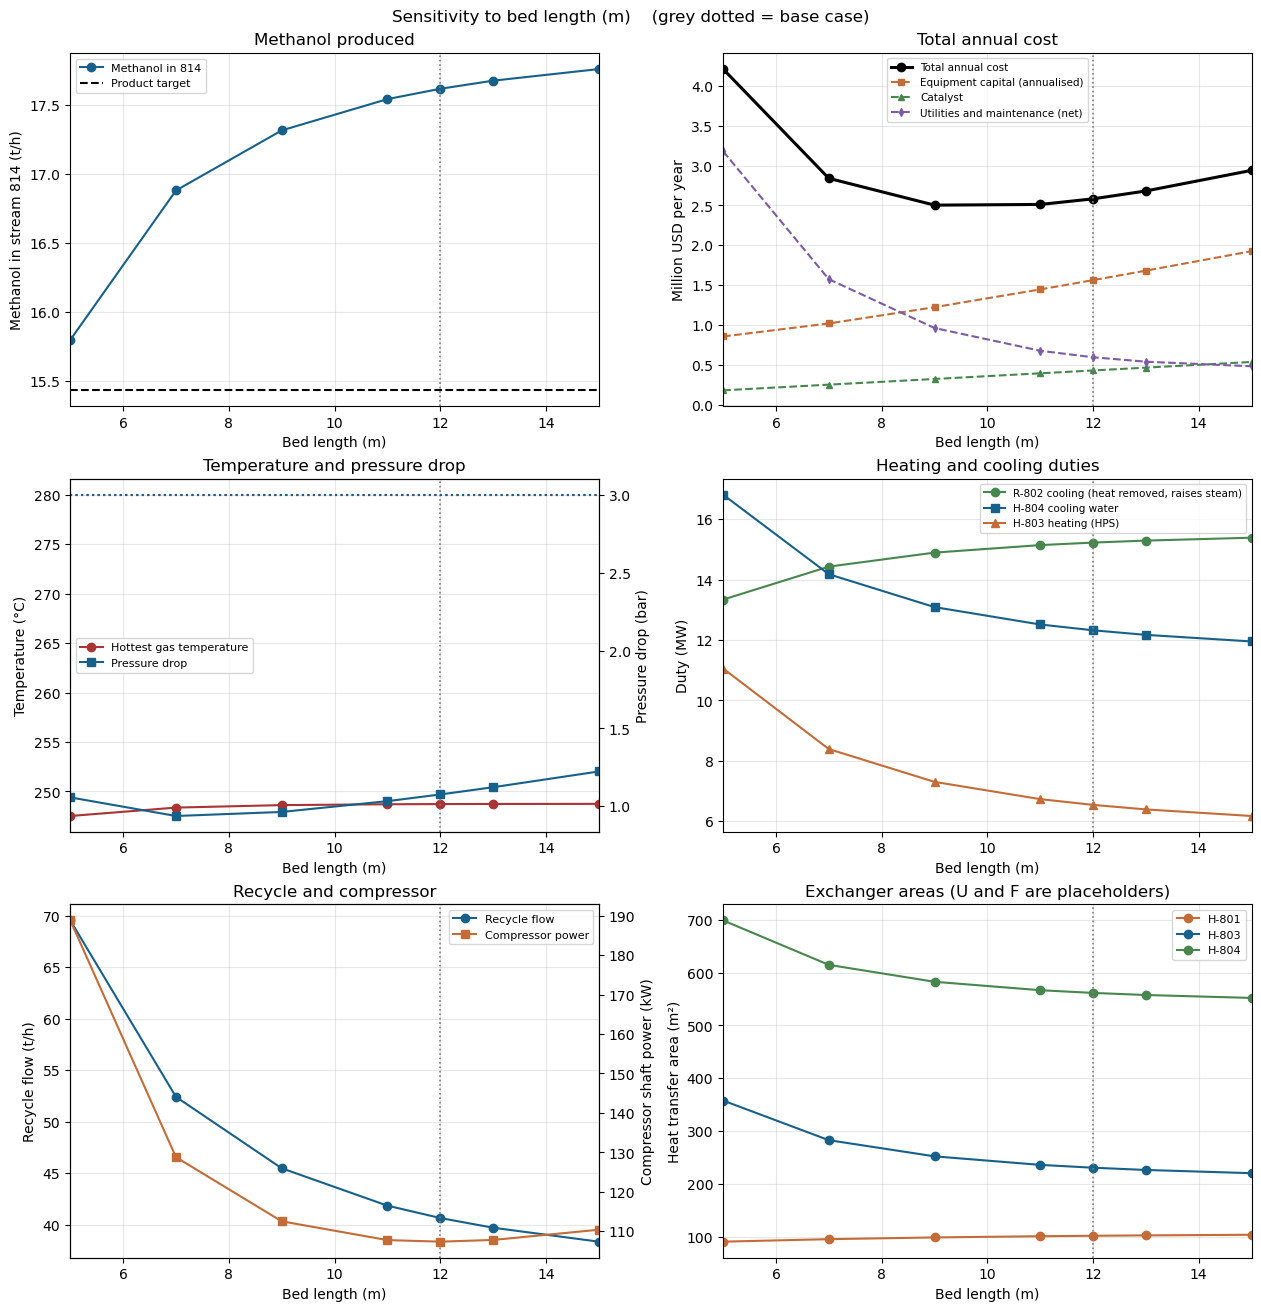

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 5.0,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 15796.931513856705,
   'Tmax_C': 247.51898980917713,
   'dP_bar': 1.0572739336674846,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 69525.0643157813,
   'purge_kg_h': 4437.770078808289,
   'comp_kW': 188.80505854425826,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(11.056676046724931),
   'Q804_MW': np.float64(16.80992660217118),
   'Qrx_MW': 13.338164815034991,
   'cat_mass_kg': 21384.192874455006,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 84.34169704392156,
    '806': 240.0,
    '807': 243.25971630520962,
    '808': 210.8978713192543,
    '809': 32.0},
   'failures': ['reactor H2S'],
   'h2s_ppmv': 0.0392457062845038,
   'rec_vec': [1048.7043741758764,
    358.35433761525815,
    67.62791597009647,
    11.98277387283782,
    0.0

In [11]:
# 2a. Bed length
sweep_and_plot("L")

Sweeping Number of tubes: 6 points
  solving 2 new designs on 2 cores (about 2.5 min per design per core) ...
  N = 2000      loop did not solve: RuntimeError: Loop not converged: nonlinear residual 0.01301806502011934; nonlinear residu
  N = 3250      methanol  17.34 t/h  TAC   2.656 M  feasible
  N = 4000      methanol  17.61 t/h  TAC   2.584 M  feasible
  N = 4500      methanol  17.71 t/h  TAC   2.695 M  feasible
  N = 5750      methanol  17.84 t/h  TAC   3.205 M  feasible
  N = 7000      methanol  17.90 t/h  TAC   3.866 M  feasible


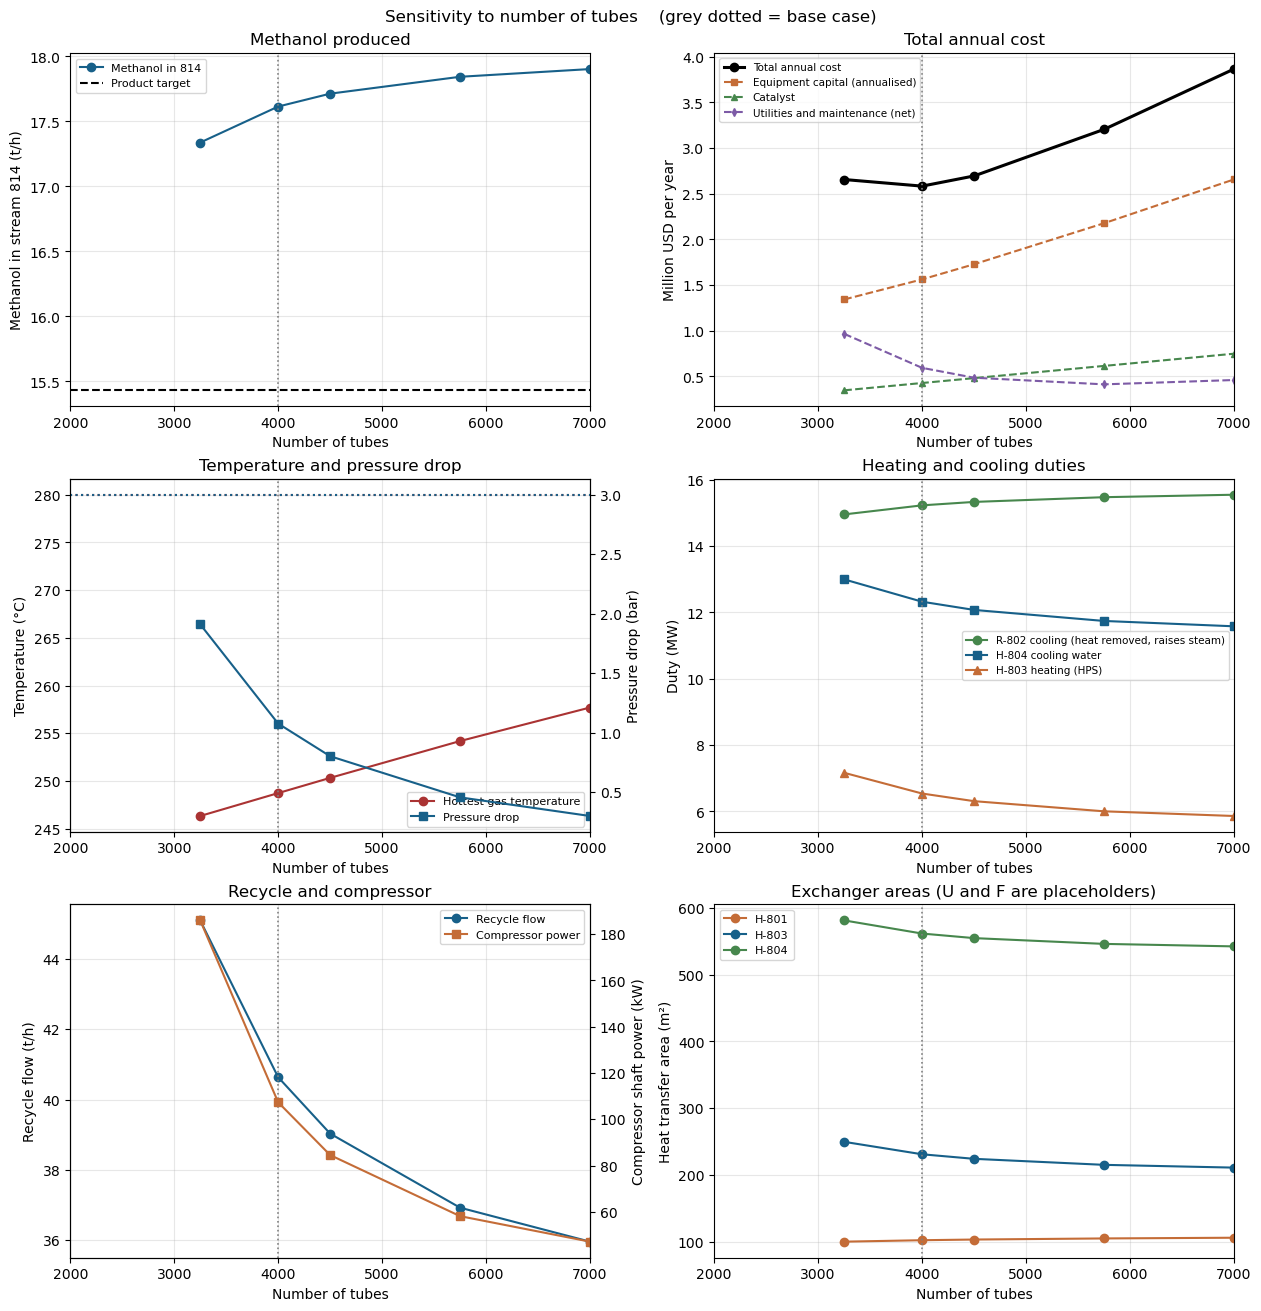

[{'p': {'ok': False,
   'x': {'N': 2000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': 'RuntimeError: Loop not converged: nonlinear residual 0.01301806502011934; nonlinear residual 0.013018949959721842; nonlinear residual 0.013003158068536006',
   'seconds': 2157.511858701706},
  'tac': None,
  'feasible': False,
  'reasons': ['loop did not solve'],
  'viol': 5.0},
 {'p': {'ok': True,
   'x': {'N': 3250,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 17337.724057432446,
   'Tmax_C': 246.3237833997896,
   'dP_bar': 1.9106654440514,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 45090.22465444516,
   'purge_kg_h': 2878.0993777263952,
   'comp_kW': 185.93994918415942,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(7.16623924249702),
   'Q8

In [12]:
# 2b. Number of tubes
sweep_and_plot("N")

Sweeping Tube inside diameter (m): 5 points
  solving 2 new designs on 2 cores (about 2.5 min per design per core) ...
  d_t = 0.03      methanol  15.42 t/h  TAC   6.059 M  NOT feasible: methanol below target; pressure drop
  d_t = 0.04      methanol  17.61 t/h  TAC   2.584 M  feasible
  d_t = 0.05      methanol  17.86 t/h  TAC   2.815 M  feasible
  d_t = 0.06      methanol  17.91 t/h  TAC   3.459 M  feasible
  d_t = 0.07      methanol  17.92 t/h  TAC   4.246 M  NOT feasible: max temperature


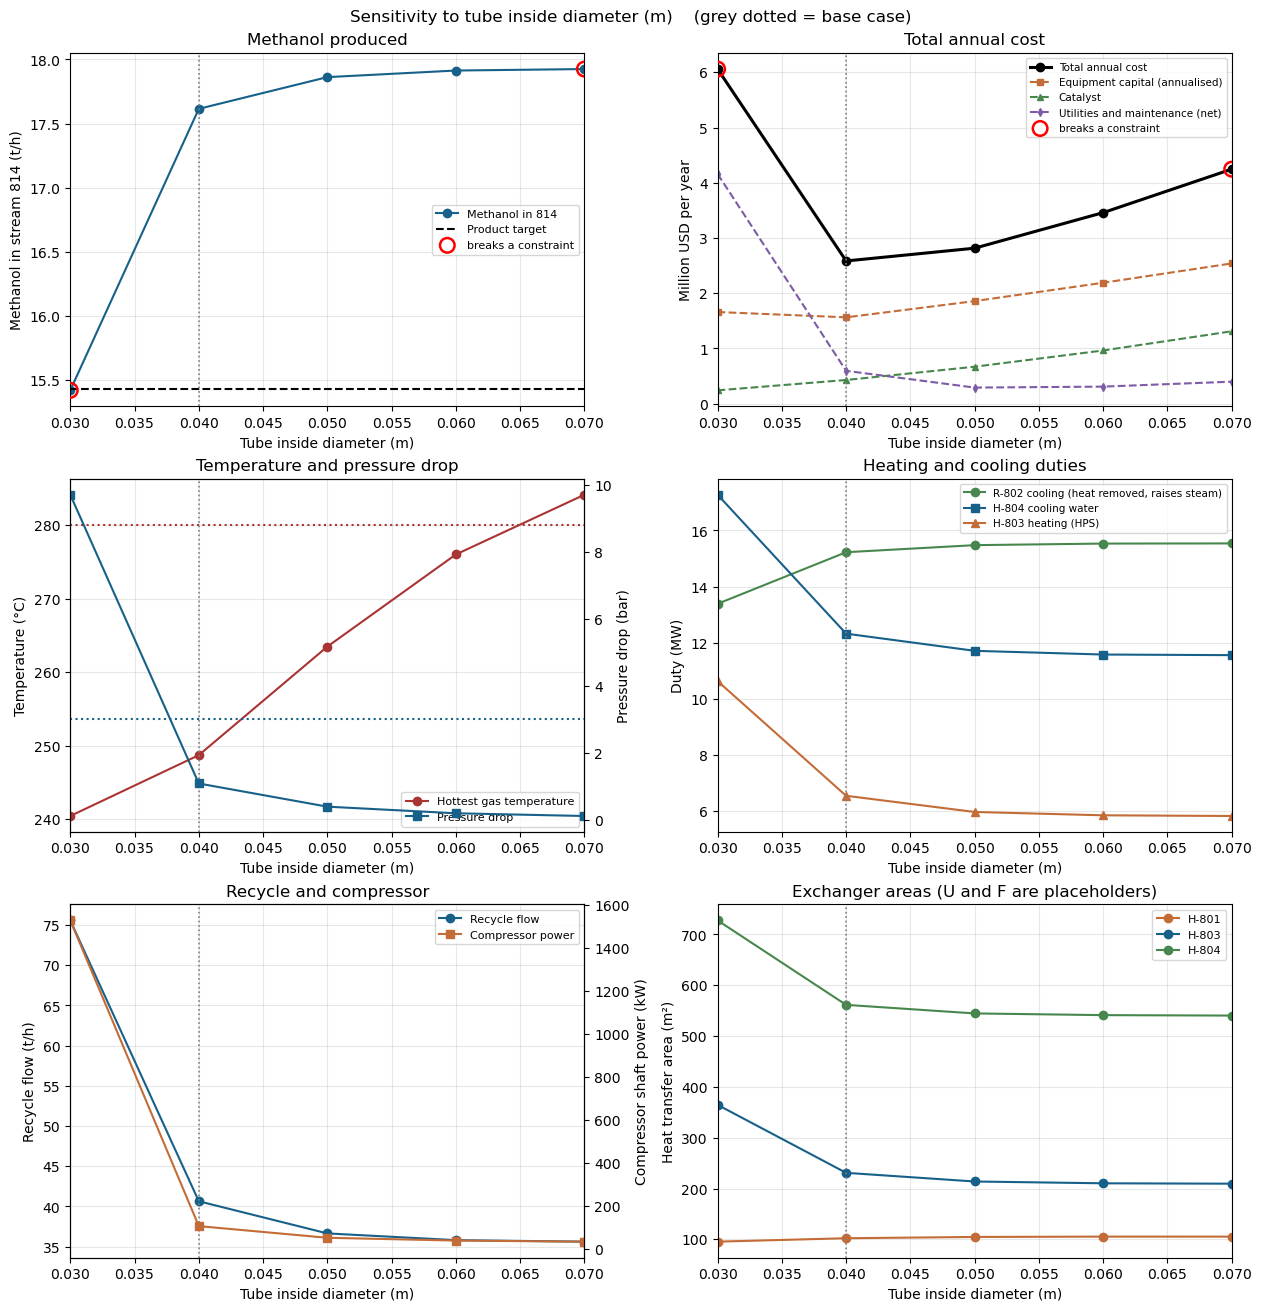

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.03,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 15421.941562490196,
   'Tmax_C': 240.4452930506626,
   'dP_bar': 9.696975149063883,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 75586.60497287966,
   'purge_kg_h': 4824.676917946087,
   'comp_kW': 1526.849034608225,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(10.630381609816641),
   'Q804_MW': np.float64(17.274956246697844),
   'Qrx_MW': 13.386959198086915,
   'cat_mass_kg': 28868.66038051425,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 99.59866088791944,
    '806': 240.0,
    '807': 238.04329102177542,
    '808': 207.59540182488223,
    '809': 32.0},
   'failures': ['reactor pressure drop', 'reactor H2S'],
   'h2s_ppmv': 0.03677112632028384,
   'rec_vec': [1147.461746176791,
    403.44152144311795,
    70.4889174184948,
    14.9

In [13]:
# 2c. Tube inside diameter
sweep_and_plot("d_t")

Sweeping Reactor inlet temperature (°C): 5 points
  solving 2 new designs on 2 cores (about 2.5 min per design per core) ...
  T_in = 210       methanol  17.59 t/h  TAC   2.325 M  feasible
  T_in = 220       methanol  17.60 t/h  TAC   2.410 M  feasible
  T_in = 230       methanol  17.61 t/h  TAC   2.495 M  feasible
  T_in = 240       methanol  17.61 t/h  TAC   2.584 M  feasible
  T_in = 250       methanol  17.62 t/h  TAC   2.677 M  feasible


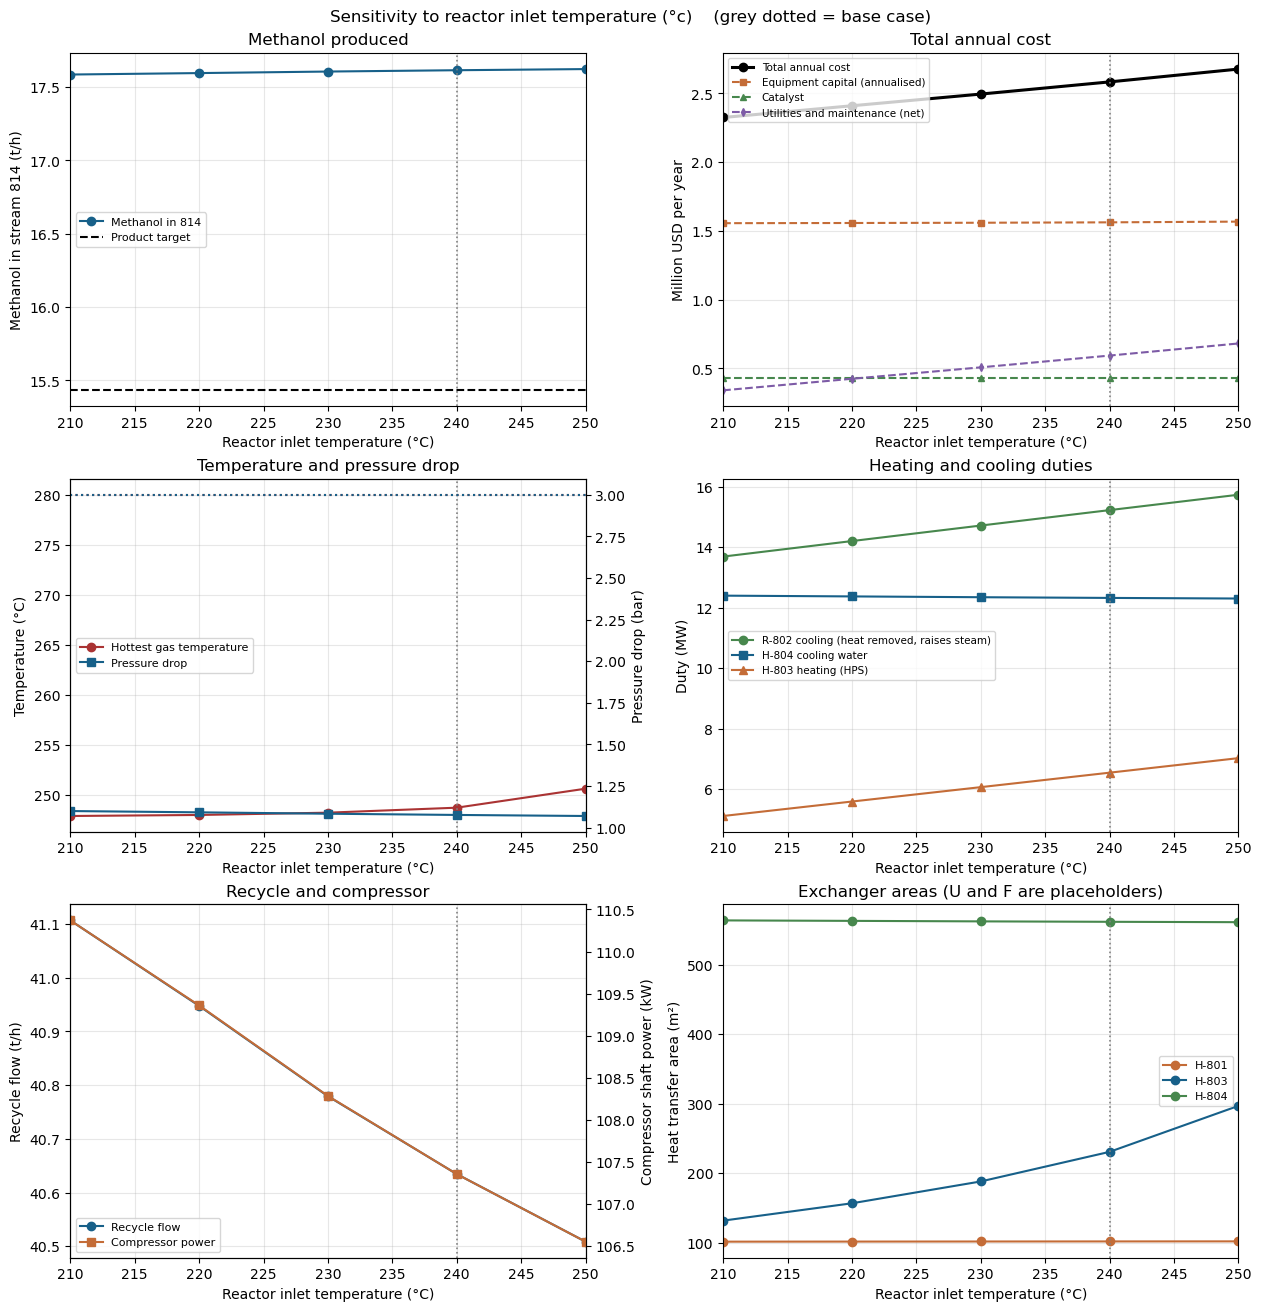

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 210.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 17585.155974569752,
   'Tmax_C': 247.89325482973015,
   'dP_bar': 1.0994429179941025,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 41106.81414817104,
   'purge_kg_h': 2623.839228085143,
   'comp_kW': 110.37022605505585,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(5.108823415733718),
   'Q804_MW': np.float64(12.39682907279256),
   'Qrx_MW': 13.688692870584553,
   'cat_mass_kg': 51322.06289869202,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 106.13008461260921,
    '806': 210.0,
    '807': 237.9852713416218,
    '808': 190.00448141852013,
    '809': 32.0},
   'failures': ['reactor H2S'],
   'h2s_ppmv': 0.05823029668623973,
   'rec_vec': [566.3468400678773,
    126.44215678022437,
    61.450191824119294,
    7.201174472663505,
    0.0

In [14]:
# 2d. Reactor inlet temperature (stream 806)
sweep_and_plot("T_in")

Sweeping Coolant temperature (°C): 6 points
  solving 4 new designs on 4 cores (about 2.5 min per design per core) ...
  T_cool = 190       loop did not solve: RuntimeError: Loop not converged: Run stopped at z=10.1690 m: low pressure constraint reac
  T_cool = 203.75    methanol   5.77 t/h  TAC  24.098 M  NOT feasible: methanol below target; pressure drop
  T_cool = 217.5     methanol  13.74 t/h  TAC   8.519 M  NOT feasible: methanol below target; pressure drop
  T_cool = 231.25    methanol  17.52 t/h  TAC   2.723 M  feasible
  T_cool = 235       methanol  17.61 t/h  TAC   2.584 M  feasible
  T_cool = 245       methanol  17.51 t/h  TAC   2.783 M  feasible


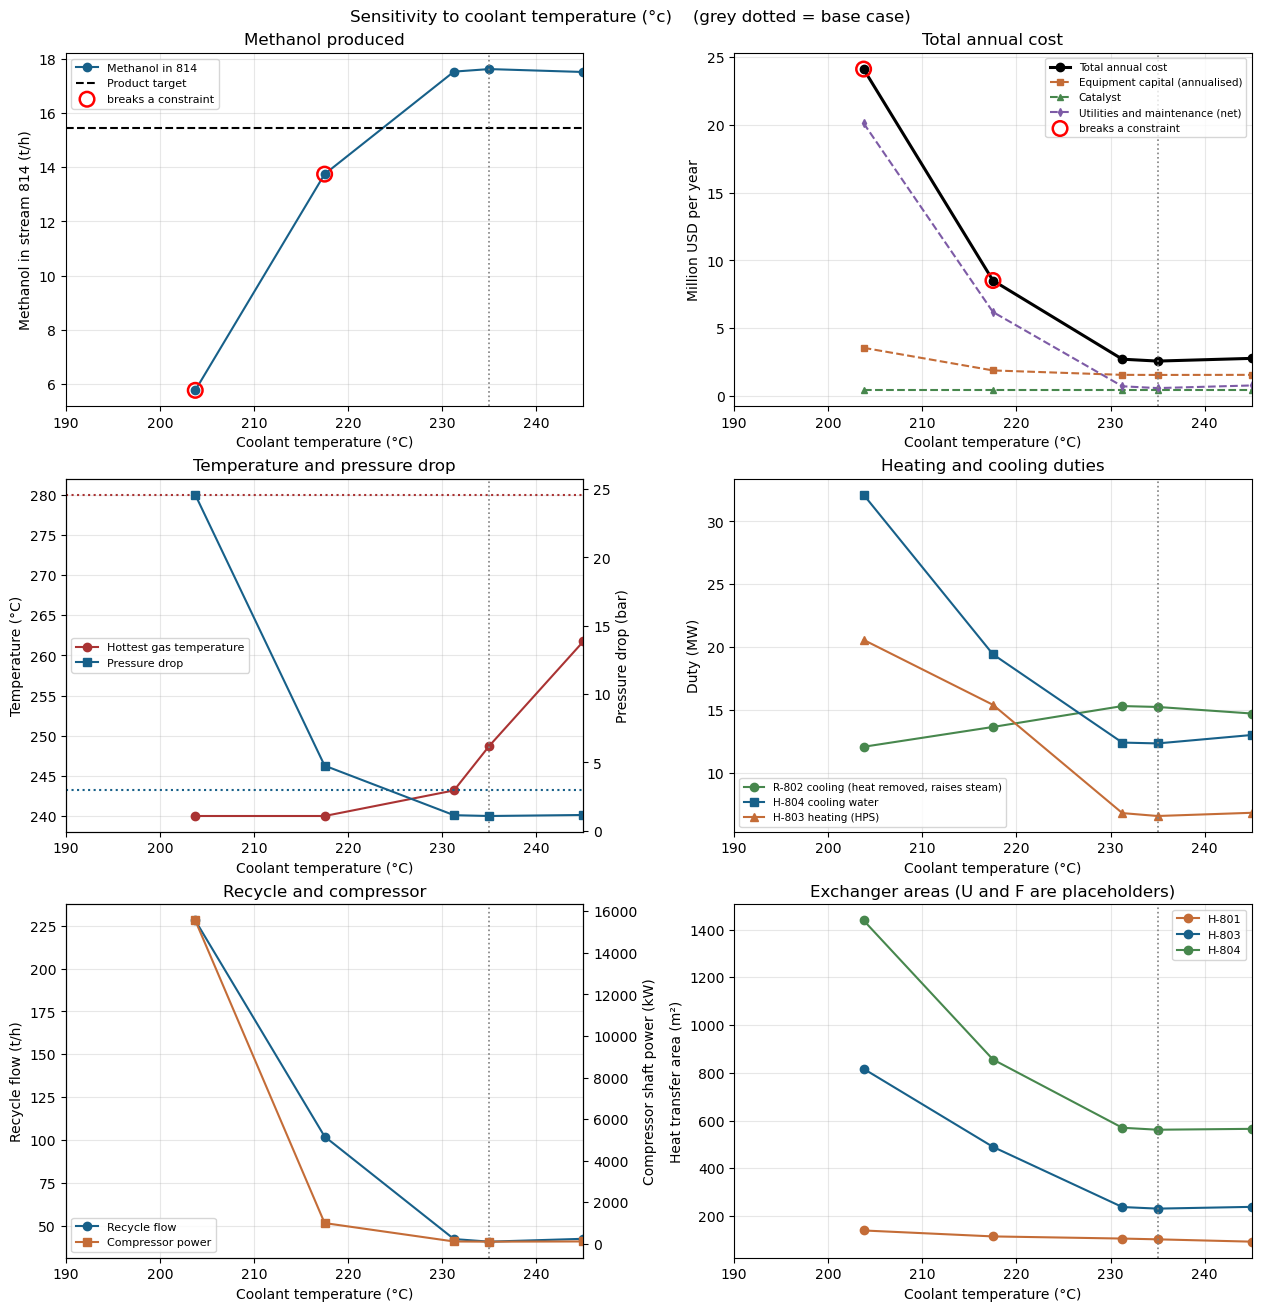

[{'p': {'ok': False,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 190.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': 'RuntimeError: Loop not converged: Run stopped at z=10.1690 m: low pressure constraint reached; nonlinear residual 0.0917745290584257; Run stopped at z=11.5456 m: low pressure constraint reached',
   'seconds': 1213.8982458114624},
  'tac': None,
  'feasible': False,
  'reasons': ['loop did not solve'],
  'viol': 5.0},
 {'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 203.75,
    'P': 48.96,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 5772.647969789587,
   'Tmax_C': 240.0,
   'dP_bar': 24.590622746219573,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 228159.8161074663,
   'purge_kg_h': 14563.392520017496,
   'comp_kW': 15563.537887844643,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.fl

In [15]:
# 2e. Coolant (boiling water) temperature
sweep_and_plot("T_cool")

Sweeping Reactor pressure (bar abs): 5 points
  solving 3 new designs on 3 cores (about 2.5 min per design per core) ...
  P = 36        methanol  16.21 t/h  TAC   4.964 M  feasible
  P = 39.24     methanol  16.77 t/h  TAC   4.003 M  feasible
  P = 42.48     methanol  17.14 t/h  TAC   3.374 M  feasible
  P = 45.72     methanol  17.41 t/h  TAC   2.924 M  feasible
  P = 48.96     methanol  17.61 t/h  TAC   2.584 M  feasible


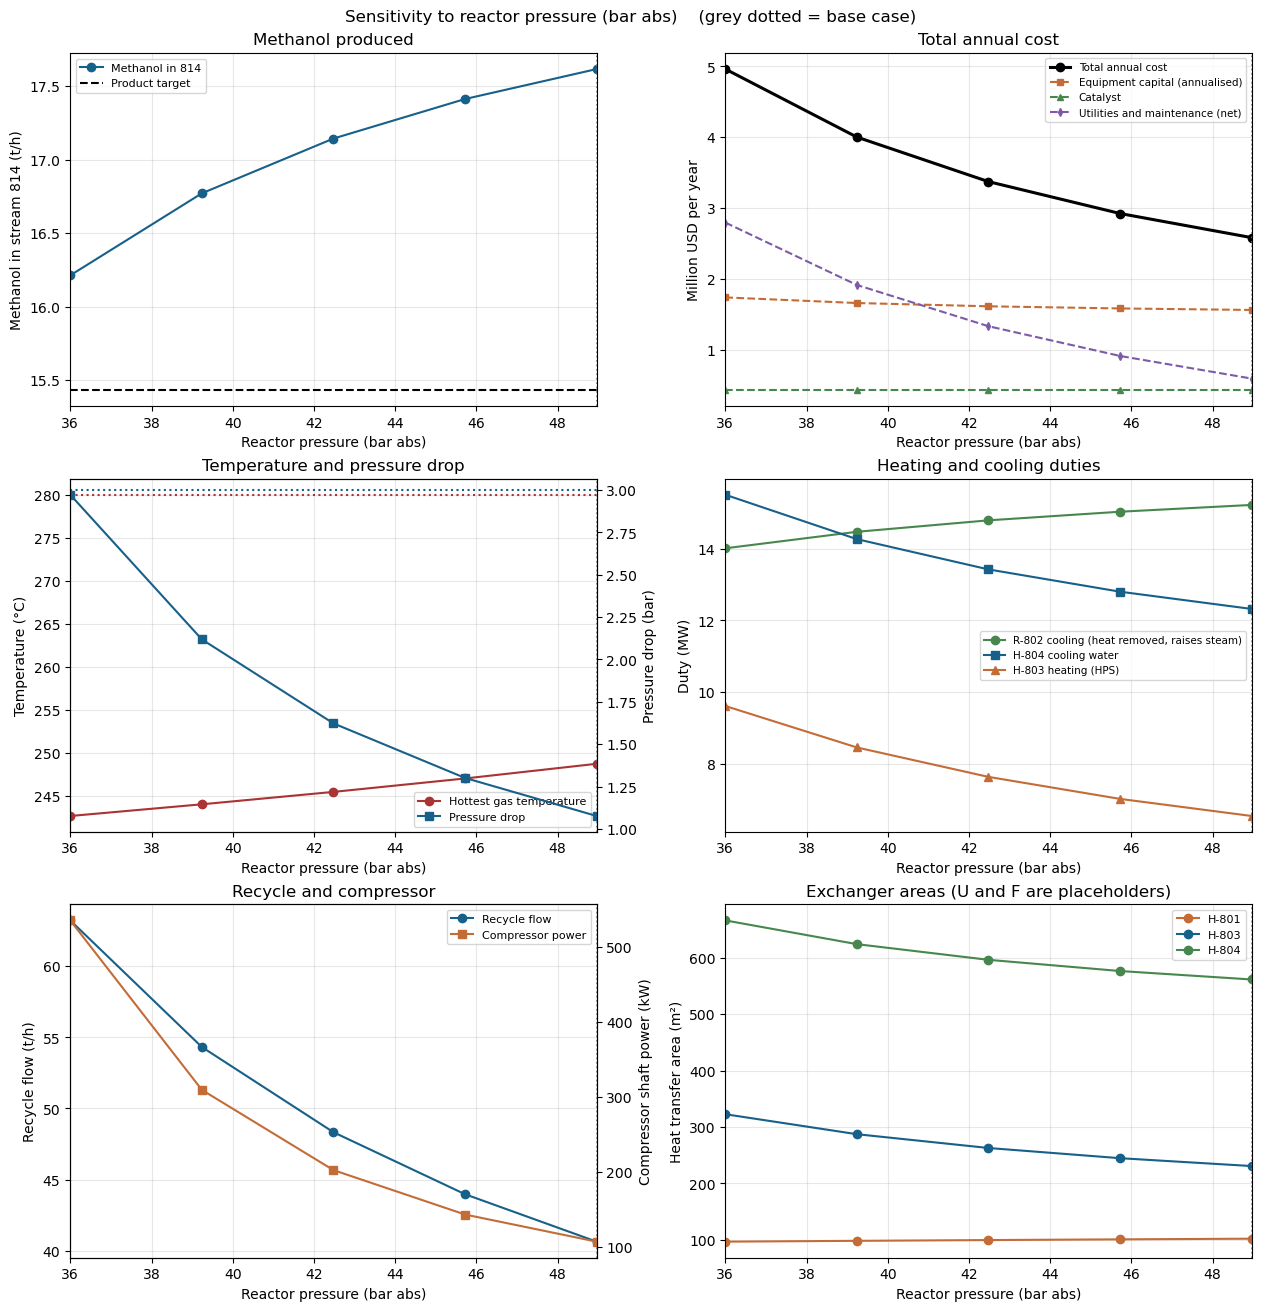

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 36.0,
    'purge': 0.06,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 16213.105976020572,
   'Tmax_C': 242.65588167954297,
   'dP_bar': 2.97236588719334,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 63228.39966763966,
   'purge_kg_h': 4035.8553398966,
   'comp_kW': 535.4750426963171,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(9.61241989336814),
   'Q804_MW': np.float64(15.510400405642315),
   'Qrx_MW': 14.015107505037845,
   'cat_mass_kg': 51322.06289869202,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 94.07218251798503,
    '806': 240.0,
    '807': 238.18485566386818,
    '808': 202.95007622462043,
    '809': 32.0},
   'failures': ['reactor H2S'],
   'h2s_ppmv': 0.04250721301434212,
   'rec_vec': [934.5340583909152,
    296.11402129380167,
    71.06468825608017,
    14.262647534125335,
    0.0894184

In [16]:
# 2f. Reactor pressure
sweep_and_plot("P")

Sweeping Purge fraction: 6 points
  solving 3 new designs on 3 cores (about 2.5 min per design per core) ...
  purge = 0.03      methanol  18.00 t/h  TAC   5.211 M  feasible
  purge = 0.0475    methanol  17.77 t/h  TAC   3.287 M  feasible
  purge = 0.06      methanol  17.61 t/h  TAC   2.584 M  feasible
  purge = 0.065     methanol  17.56 t/h  TAC   2.375 M  feasible
  purge = 0.0825    methanol  17.36 t/h  TAC   1.835 M  feasible
  purge = 0.1       methanol  17.17 t/h  TAC   1.477 M  feasible


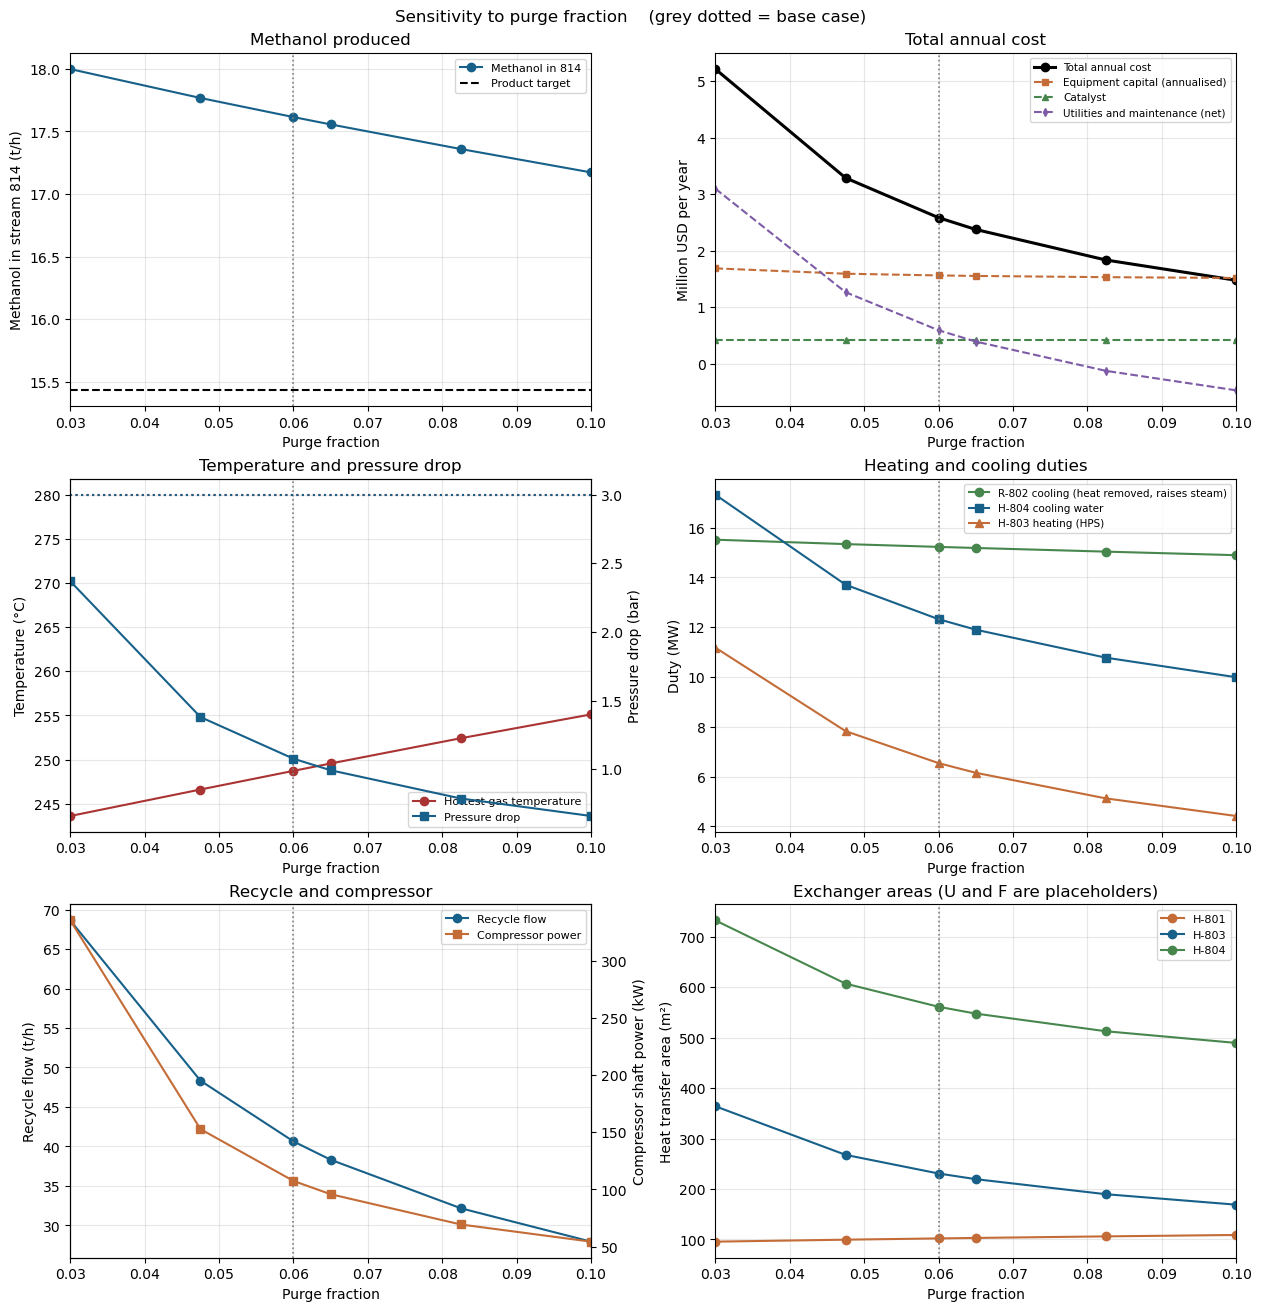

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.03,
    'activity': 1.0},
   'error': '',
   'methanol_kg_h': 17998.048100270444,
   'Tmax_C': 243.6116458883181,
   'dP_bar': 2.369448773388853,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 68626.64648571989,
   'purge_kg_h': 2122.473608241743,
   'comp_kW': 335.2086012943586,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(11.178521292354032),
   'Q804_MW': np.float64(17.3206274033373),
   'Qrx_MW': 15.514951379544938,
   'cat_mass_kg': 51322.06289869202,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 86.09842759890915,
    '806': 240.0,
    '807': 238.09729081457505,
    '808': 206.57103328847109,
    '809': 32.0},
   'failures': ['reactor H2S'],
   'h2s_ppmv': 0.08118120594885418,
   'rec_vec': [898.3910047302771,
    191.91314163814087,
    82.69987700663754,
    12.291815154179073,
    0.1155

In [17]:
# 2g. Purge fraction
sweep_and_plot("purge")

Sweeping Catalyst activity multiplier: 6 points
  activity = 0.6       methanol  16.66 t/h  TAC   4.119 M  feasible
  activity = 0.75      methanol  17.26 t/h  TAC   3.165 M  feasible
  activity = 0.9       methanol  17.52 t/h  TAC   2.744 M  feasible
  activity = 1         methanol  17.61 t/h  TAC   2.584 M  feasible
  activity = 1.05      methanol  17.65 t/h  TAC   2.523 M  feasible
  activity = 1.2       methanol  17.73 t/h  TAC   2.393 M  feasible


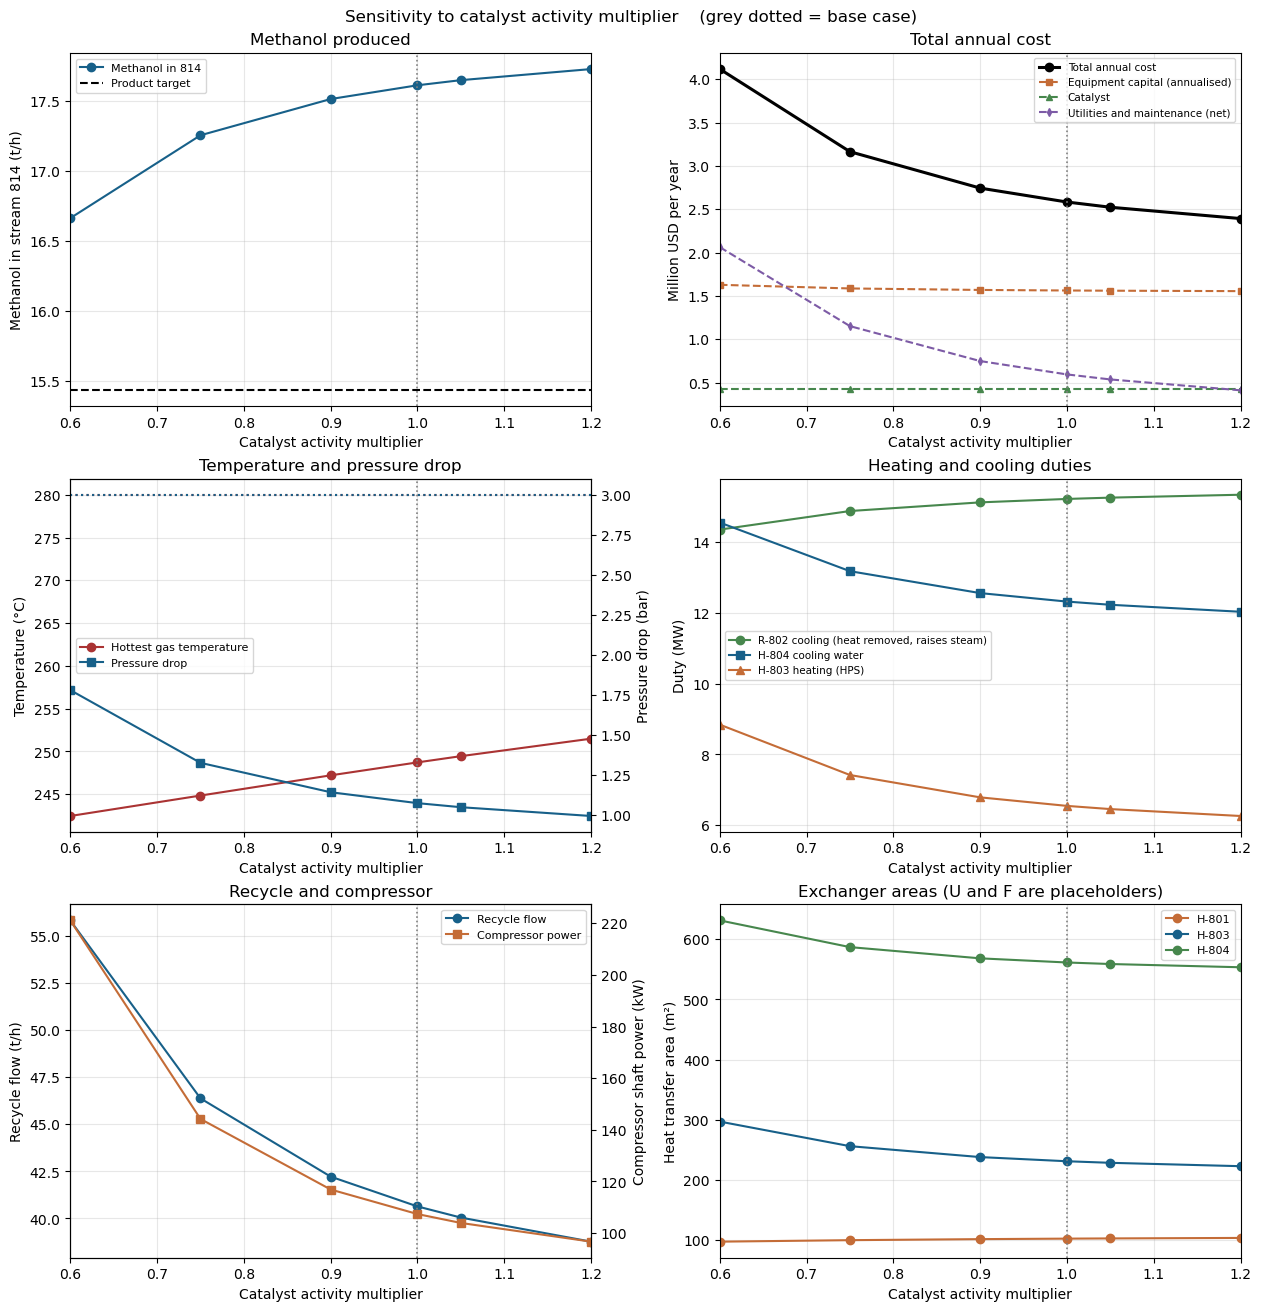

[{'p': {'ok': True,
   'x': {'N': 4000,
    'L': 12,
    'd_t': 0.04,
    'T_in': 240.0,
    'T_cool': 235.0,
    'P': 48.96,
    'purge': 0.06,
    'activity': 0.6},
   'error': '',
   'methanol_kg_h': 16663.841263575585,
   'Tmax_C': 242.46003678303043,
   'dP_bar': 1.781213241749946,
   'Tmax_limit_C': 280.0,
   'dP_limit_bar': 3.0,
   'recycle_kg_h': 55837.59274323436,
   'purge_kg_h': 3564.101674021385,
   'comp_kW': 221.11769939817987,
   'Q801_MW': np.float64(2.217484321786411),
   'Q803_MW': np.float64(8.840076500304967),
   'Q804_MW': np.float64(14.557648390265108),
   'Qrx_MW': 14.358801665303844,
   'cat_mass_kg': 51322.06289869202,
   'T': {'801': 40.0,
    '802': 180.0,
    '805': 94.11596649932483,
    '806': 240.0,
    '807': 239.04754369854618,
    '808': 200.61373195850422,
    '809': 32.0},
   'failures': ['reactor H2S'],
   'h2s_ppmv': 0.046584342096727994,
   'rec_vec': [816.0187925871443,
    244.43603731973937,
    66.01158897086478,
    9.776239615001694,
    0.0

In [18]:
# 2h. Catalyst activity (robustness check: what if the catalyst is less active than the kinetics say?)
sweep_and_plot("activity")

## 3. Two-variable maps

Each map solves a grid of designs over two variables, with everything else at the base case, and draws six results as filled contours: methanol produced (dashed line = product target), reactor pressure drop (dashed line = limit), hottest gas temperature (dashed line = limit), R-802 cooling duty, H-803 heating duty and H-804 cooling-water duty. The black dots are the designs actually solved, so you can see how coarse the grid is; the colours between dots are interpolated. Change which results appear with `MAP_RESPONSES` in the settings cell.

A grid of 5 × 5 is 25 reactor solves, so these cells take the longest. The sweeps above reuse the points on the base-case row and column, so running the maps after the sweeps costs less than it looks.

Map of Number of tubes against Bed length (m): 7 x 6 = 42 designs
  solving 30 new designs on 6 cores (about 2.5 min per design per core) ...


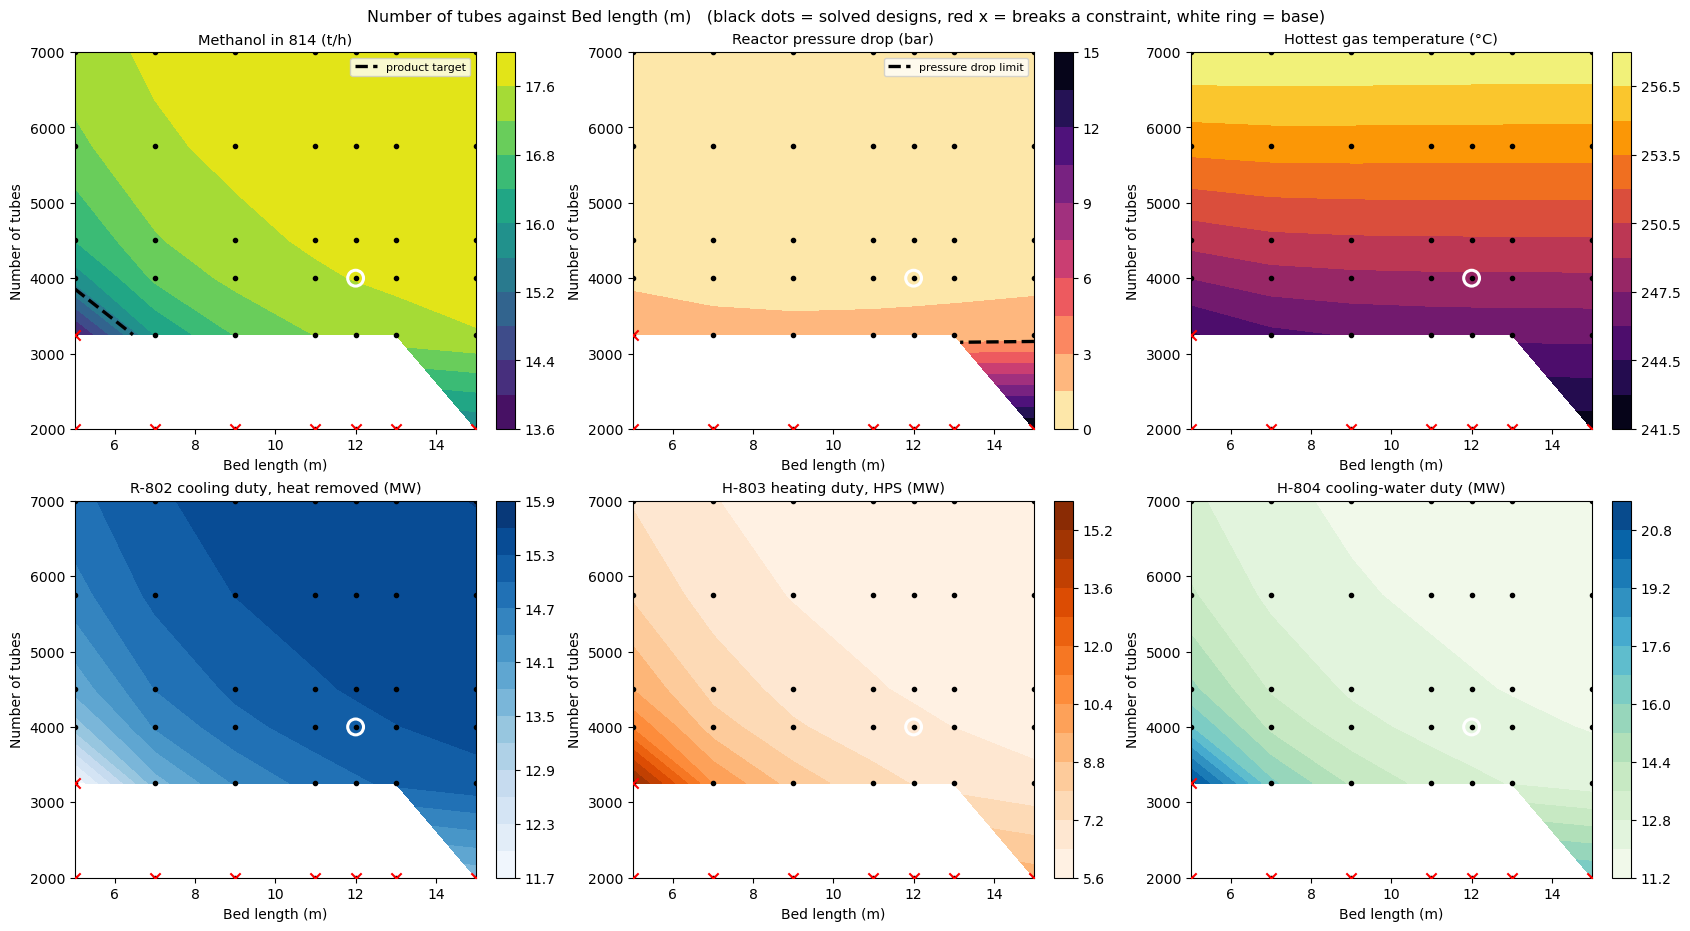

In [19]:
# 3a. Bed length against number of tubes
_ = map_2d("L", "N")

Map of Number of tubes against Tube inside diameter (m): 5 x 6 = 30 designs
  solving 20 new designs on 6 cores (about 2.5 min per design per core) ...


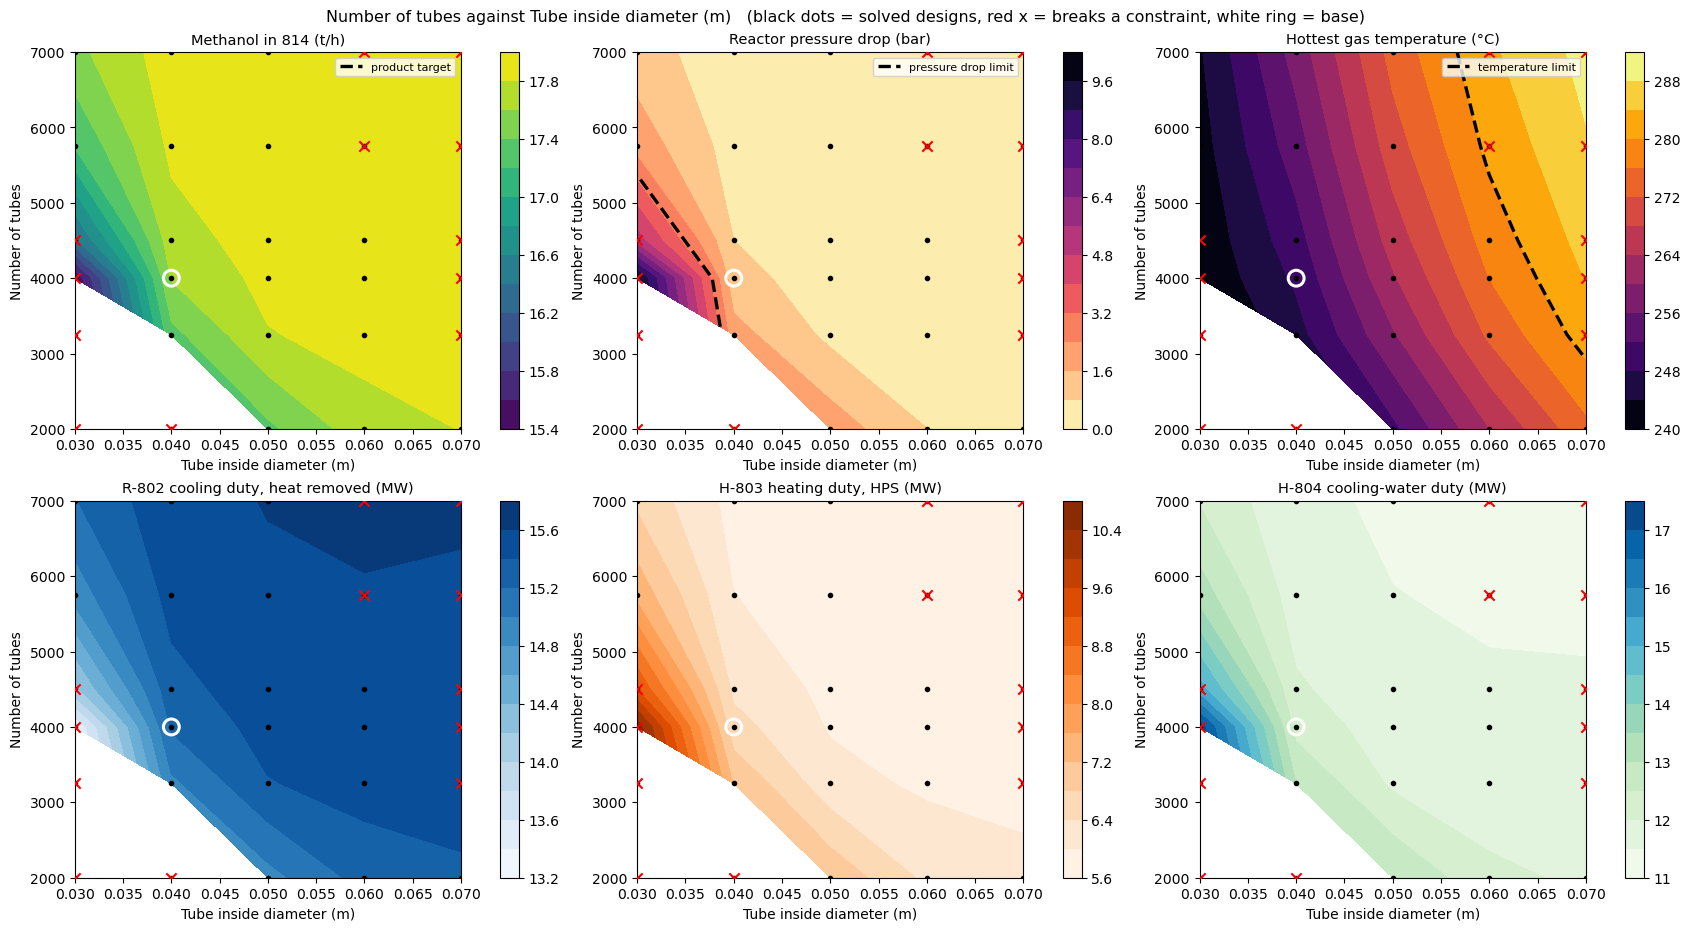

In [20]:
# 3b. Tube inside diameter against number of tubes
_ = map_2d("d_t", "N")

Map of Coolant temperature (°C) against Reactor inlet temperature (°C): 5 x 6 = 30 designs
  solving 20 new designs on 6 cores (about 2.5 min per design per core) ...


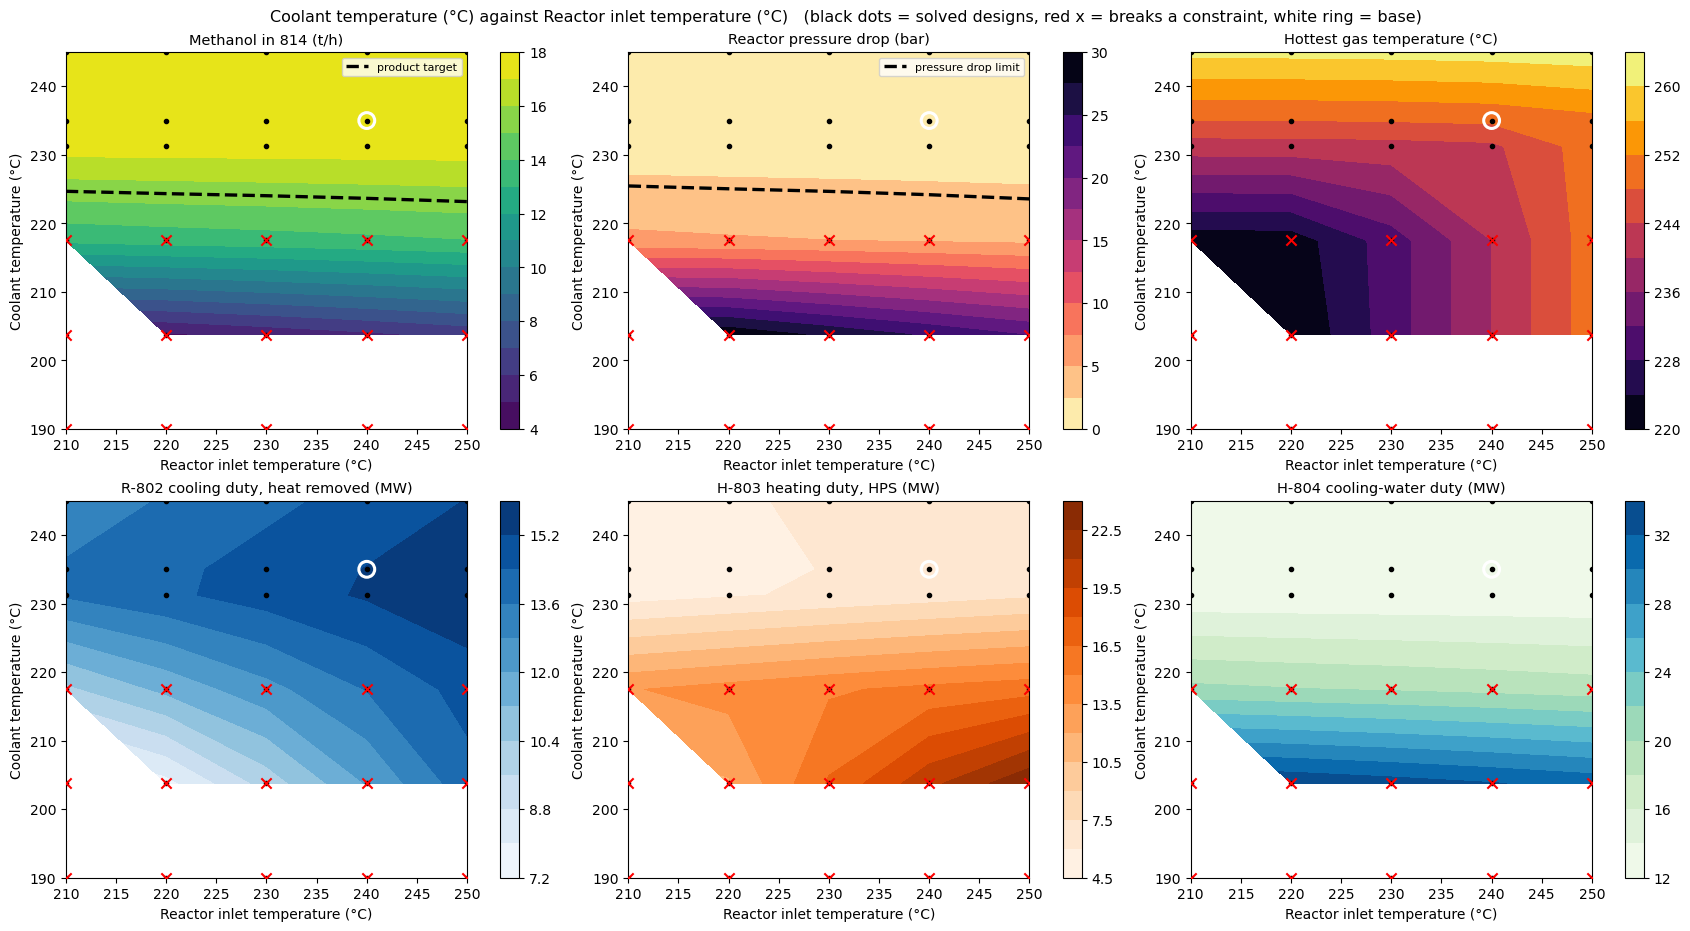

In [21]:
# 3c. Reactor inlet temperature against coolant temperature
_ = map_2d("T_in", "T_cool")

## 4. Optimisation: minimum total annual cost that still meets the product specification

Starting from the cheapest feasible design solved so far: {'N': 2000, 'L': 12, 'd_t': 0.06, 'T_in': 240.0, 'T_cool': 235.0}
  solving 6 new designs on 6 cores (about 2.5 min per design per core) ...
  iteration 1: step 0.250, 9 designs tried, moved to N 2000, L 9.5, d_t 0.06, T_in 240, T_cool 235  (best feasible TAC 1.868 M)
  solving 8 new designs on 6 cores (about 2.5 min per design per core) ...
  iteration 2: step 0.250, 9 designs tried, moved to N 2000, L 9.5, d_t 0.06, T_in 230, T_cool 235  (best feasible TAC 1.784 M)
  solving 7 new designs on 6 cores (about 2.5 min per design per core) ...
  iteration 3: step 0.250, 9 designs tried, moved to N 2000, L 9.5, d_t 0.06, T_in 220, T_cool 235  (best feasible TAC 1.708 M)
  solving 8 new designs on 6 cores (about 2.5 min per design per core) ...
  iteration 4: step 0.250, 9 designs tried, moved to N 2000, L 9.5, d_t 0.06, T_in 210, T_cool 235  (best feasible TAC 1.634 M)
  solving 7 new designs on 6 cores (about 2.5 min per design per

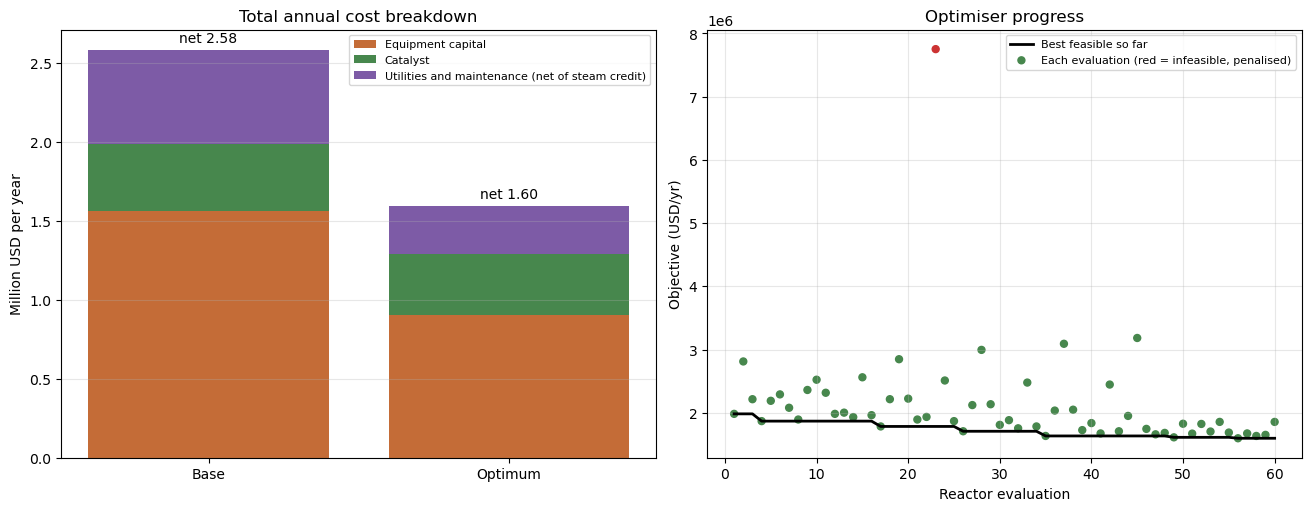

In [22]:
OPT_ROUND = {"N": 50, "L": 0.1, "d_t": 0.0005, "T_in": 0.5, "T_cool": 0.5, "P": 0.25}   # sensible design increments
opt_names = list(OPT_BOUNDS)

def decode(z):
    x = dict(BASE)
    for name, zi in zip(opt_names, z):
        lo, hi = OPT_BOUNDS[name]
        v = lo+float(np.clip(zi, 0, 1))*(hi-lo)
        step = OPT_ROUND[name]
        x[name] = round(round(v/step)*step, 6)
    return x

def encode(x):
    return np.array([(x[n]-OPT_BOUNDS[n][0])/(OPT_BOUNDS[n][1]-OPT_BOUNDS[n][0]) for n in opt_names])

PENALTY = 20.0
BIG = 3.0*base_eval["tac"]["total"] if base_eval["tac"] else 1e8
history = []; best = {"obj": np.inf, "e": None}

def score(e):
    """Objective for the optimiser: TAC, plus a penalty that grows with how badly a constraint is broken."""
    if not e["p"]["ok"]:
        return BIG*(1+PENALTY)
    t = e["tac"]["total"]
    return t if e["feasible"] else t*(1.0+PENALTY*max(e["viol"], 0.02))

def record(x, e):
    f = score(e)
    if e["feasible"] and f < best["obj"]:
        best.update(obj=f, e=e)
    history.append((min(f, BIG), best["obj"] if np.isfinite(best["obj"]) else np.nan, e["feasible"]))
    return f

# Pattern (compass) search: from the current design, try a step up and down in every variable at the same time
# (these designs are independent, so they run in parallel), move to the best one, and halve the step when nothing improves.
t_start, x_start = cheapest_known()
start = {**BASE, **{n: x_start[n] for n in opt_names}} if x_start else dict(BASE)
print("Starting from", "the cheapest feasible design solved so far:" if x_start else "the base design:", {n: start[n] for n in opt_names})
z = np.clip(encode(start), 0, 1)
x_cur = decode(z); z = encode(x_cur)
e_cur = evaluate(x_cur); f_cur = record(x_cur, e_cur); n_eval = 1
step = 0.25; iteration = 0
while n_eval < OPT_MAX_EVALS and step >= 0.04:
    iteration += 1
    cands = {}
    for k in range(len(z)):
        for sgn in (+1, -1):
            zk = z.copy(); zk[k] = np.clip(zk[k]+sgn*step, 0, 1)
            xk = decode(zk)
            if xk != x_cur:
                cands[tuple(sorted(xk.items()))] = xk
    items = list(cands.values())[:OPT_MAX_EVALS-n_eval]
    if not items:
        step /= 2; continue
    evs = evaluate_many(items); n_eval += len(items)
    scores = [record(xk, e) for xk, e in zip(items, evs)]
    j = int(np.argmin(scores))
    if scores[j] < f_cur*(1-1e-4):
        x_cur, f_cur = items[j], scores[j]; z = encode(x_cur)
        moved = ", ".join(f"{n} {x_cur[n]:g}" for n in opt_names)
        print(f"  iteration {iteration}: step {step:.3f}, {len(items)} designs tried, moved to {moved}  "
              f"(best feasible TAC {best['obj']/1e6:.3f} M)", flush=True)
    else:
        print(f"  iteration {iteration}: step {step:.3f}, {len(items)} designs tried, no improvement, halving the step", flush=True)
        step /= 2
print(f"\nOptimiser stopped after {n_eval} designs (final step {step:.3f}).")

opt_eval = best["e"]
if opt_eval is None:
    print("No feasible design was found. Widen OPT_BOUNDS or check the constraints listed above.")
else:
    show_design("Optimum found", opt_eval)
    opt_x = opt_eval["p"]["x"]
    cur = COST["currency"]
    # comparison table
    rows = [("Methanol (t/h)", lambda e: e["p"]["methanol_kg_h"]/1000), ("Hottest gas (°C)", lambda e: e["p"]["Tmax_C"]),
            ("Pressure drop (bar)", lambda e: e["p"]["dP_bar"]), ("Recycle (t/h)", lambda e: e["p"]["recycle_kg_h"]/1000),
            ("Compressor (kW)", lambda e: e["p"]["comp_kW"]), ("Catalyst mass (t)", lambda e: e["p"]["cat_mass_kg"]/1000),
            (f"TAC (M{cur}/yr)", lambda e: e["tac"]["total"]/1e6)]
    print(f"\n{'':22s}{'Base':>12s}{'Optimum':>12s}")
    for n in opt_names:
        print(f"{LABELS[n]:30s}{BASE[n]:>12g}{opt_x[n]:>12g}")
    for name, f in rows:
        print(f"{name:30s}{f(base_eval):>12.3f}{f(opt_eval):>12.3f}")
    # plots
    fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    a = ax[0]
    parts = [("equipment_capital", "Equipment capital", "#c46c37"), ("catalyst", "Catalyst", "#47874d"),
             ("utilities_and_maintenance", "Utilities and maintenance (net of steam credit)", "#7d5ba6")]
    for pos, (lab, e) in enumerate((("Base", base_eval), ("Optimum", opt_eval))):
        bottom_pos = 0.0; bottom_neg = 0.0
        for key, name, color in parts:
            v = e["tac"][key]/1e6
            if v >= 0:
                a.bar(pos, v, bottom=bottom_pos, color=color, label=name if pos == 0 else None); bottom_pos += v
            else:
                a.bar(pos, v, bottom=bottom_neg, color=color, label=name if pos == 0 else None); bottom_neg += v
        a.text(pos, bottom_pos+0.05, f"net {e['tac']['total']/1e6:.2f}", ha="center", fontsize=10)
    a.set_xticks([0, 1]); a.set_xticklabels(["Base", "Optimum"]); a.set_ylabel(f"Million {cur} per year")
    a.set_title("Total annual cost breakdown"); a.legend(fontsize=8); a.grid(alpha=.3, axis="y")
    a = ax[1]
    ev = np.arange(1, len(history)+1)
    a.plot(ev, [min(h[1], BIG) if np.isfinite(h[1]) else np.nan for h in history], "k-", lw=2, label="Best feasible so far")
    a.scatter(ev, [min(h[0], BIG) for h in history], c=["#47874d" if h[2] else "#c33" for h in history], s=25, label="Each evaluation (red = infeasible, penalised)")
    a.set(xlabel="Reactor evaluation", ylabel=f"Objective ({cur}/yr)", title="Optimiser progress"); a.legend(fontsize=8); a.grid(alpha=.3)
    plt.show()
    # Optional: check the optimum by sweeping a variable around it, e.g.
    # sweep_and_plot("L", center=opt_x, title="(other variables at the optimum)")

## 5. Maps with the optimum marked
These re-draw the maps from the saved results (no new solves), now with the optimum as a gold star.

Map of Number of tubes against Bed length (m): 7 x 6 = 42 designs


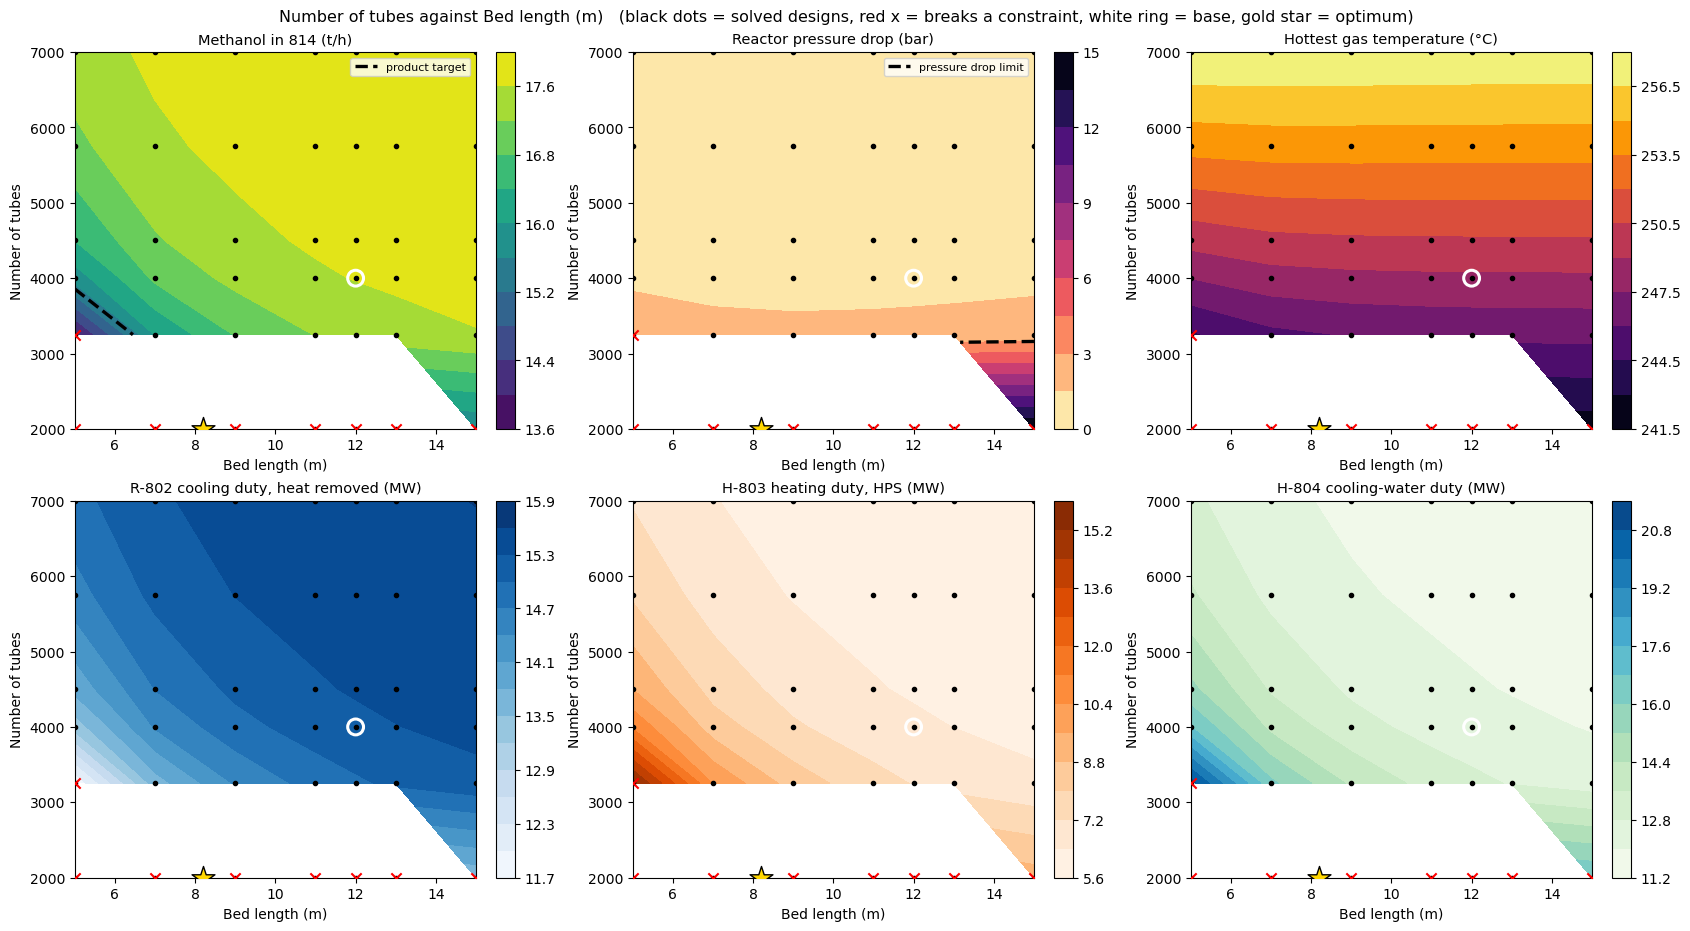

Map of Number of tubes against Tube inside diameter (m): 5 x 6 = 30 designs


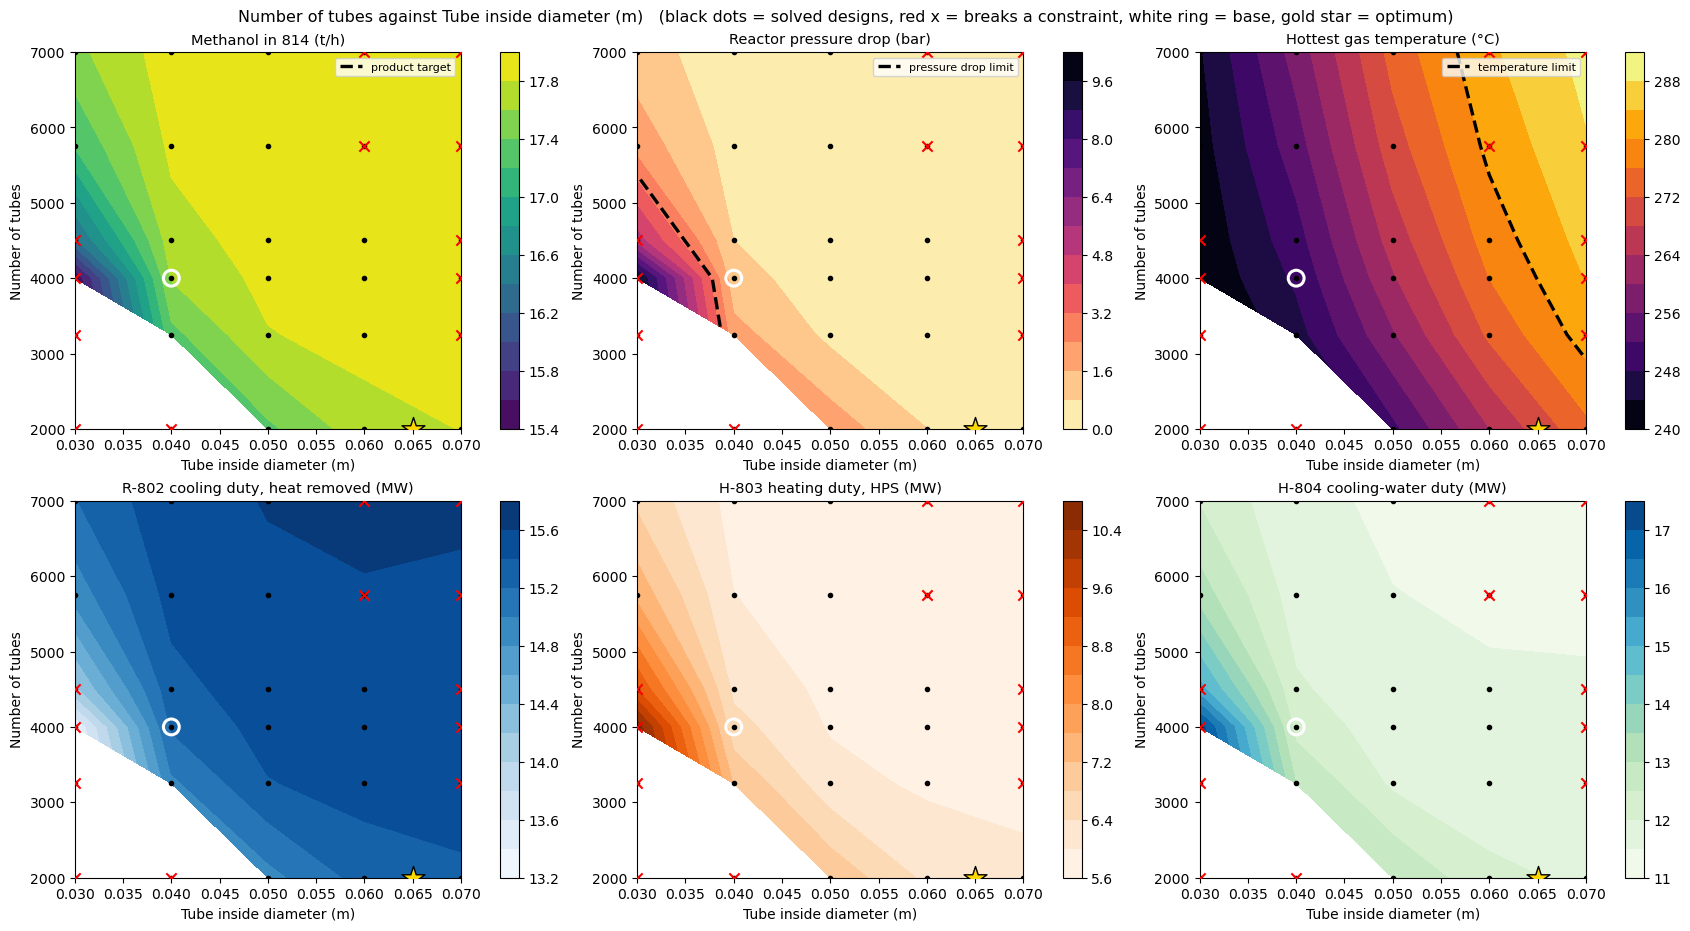

Map of Coolant temperature (°C) against Reactor inlet temperature (°C): 5 x 6 = 30 designs


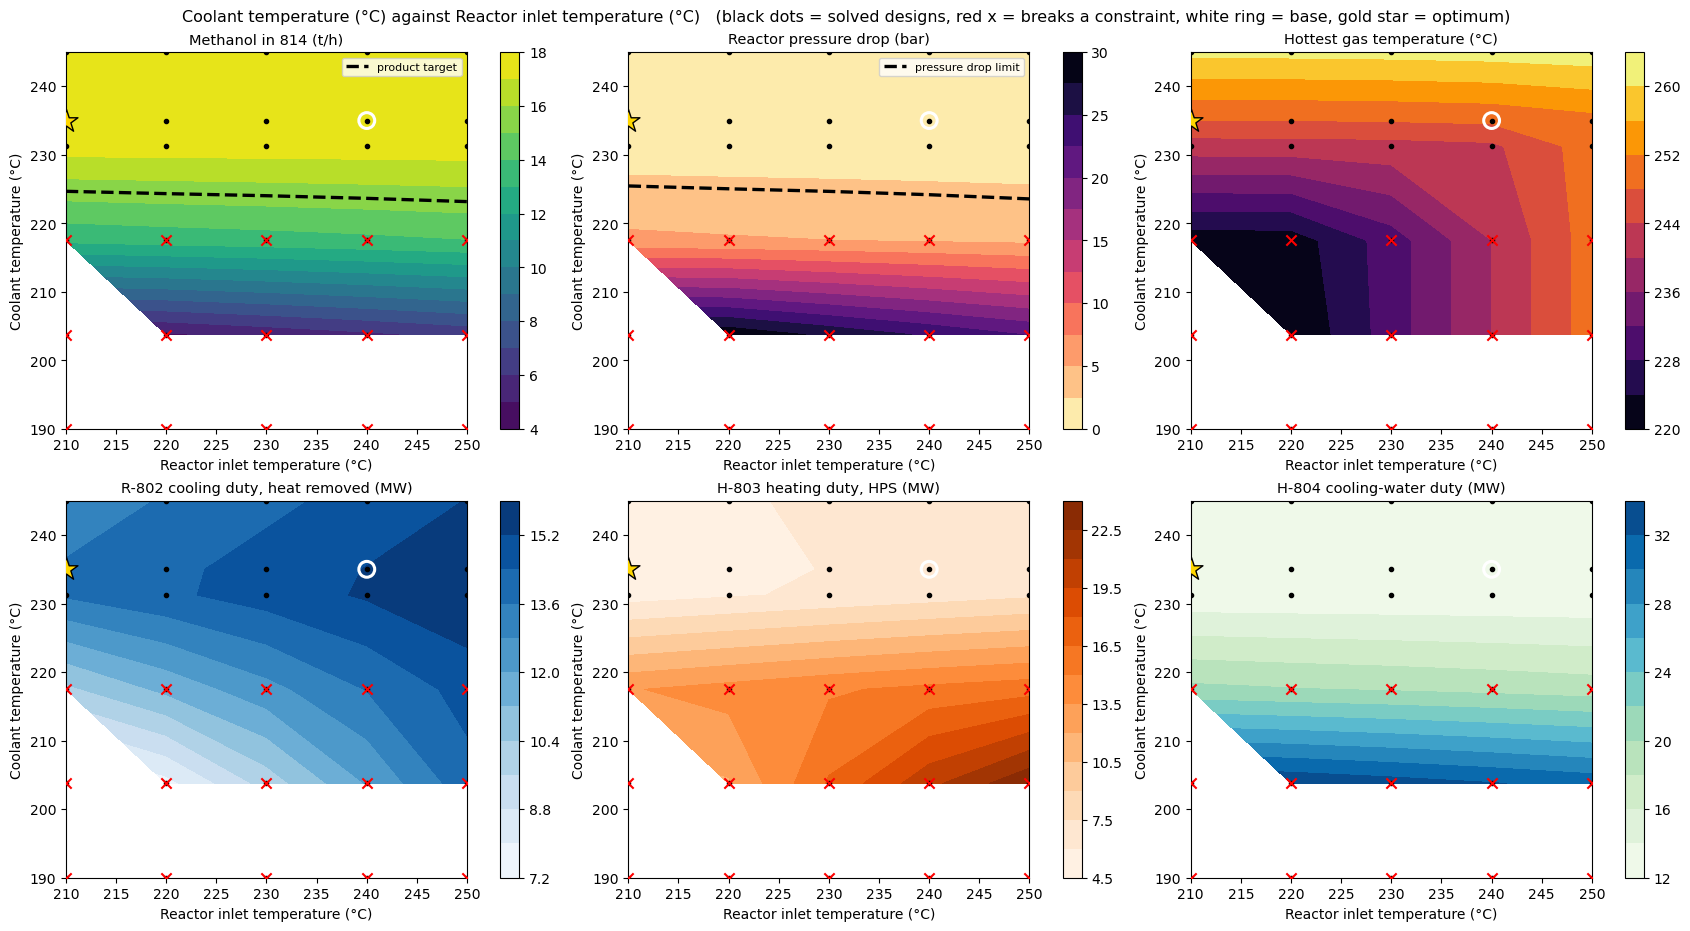

In [23]:
for pair in (("L", "N"), ("d_t", "N"), ("T_in", "T_cool")):
    _ = map_2d(*pair)

## 6. How much do the cost assumptions matter?
This needs no new reactor solves: it re-prices the designs already calculated.

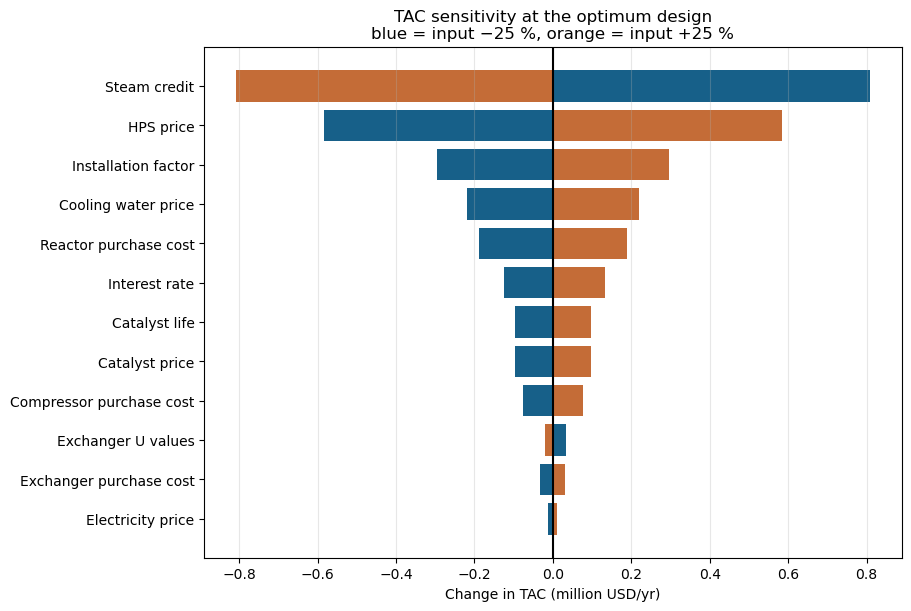

Cheapest feasible design among all 239 solved points: N=2000, L=8.2 m, d_t=65 mm, T_in=210, T_cool=235, P=48.96  (1.597 MUSD/yr)

Does that choice change if one assumption is off by 25 %? (only compares designs already solved)
  HPS price x1.25: best known becomes N=2000, L=9.5 m, d_t=65 mm
  Catalyst price x0.75: best known becomes N=2000, L=9.5 m, d_t=65 mm
  Catalyst life x0.75: best known becomes N=2000, L=9.5 m, d_t=65 mm
  Installation factor x0.75: best known becomes N=2000, L=9.5 m, d_t=65 mm
  Interest rate x0.75: best known becomes N=2000, L=9.5 m, d_t=65 mm
  Reactor purchase cost x0.75: best known becomes N=2000, L=9.5 m, d_t=65 mm


In [24]:
# Re-price already-solved designs under +/-25 % changes in each cost assumption. No new reactor solves.
design_for_tornado = opt_eval if ('opt_eval' in globals() and opt_eval is not None) else base_eval
p_t = design_for_tornado["p"]; cur = COST["currency"]

def with_changes(scale_cost=None, scale_hx_U=None):
    c = deepcopy(COST); h = deepcopy(HX)
    for path, f in (scale_cost or {}).items():
        d = c
        for k in path[:-1]: d = d[k]
        d[path[-1]] *= f
    for name in (scale_hx_U or {}): h[name]["U_W_m2_K"] *= scale_hx_U[name]
    return c, h

CASES = {
    "Electricity price": lambda f: with_changes({("electricity_per_kWh",): f}),
    "HPS price": lambda f: with_changes({("HPS_per_t",): f}),
    "Cooling water price": lambda f: with_changes({("cooling_water_per_t",): f}),
    "Steam credit": lambda f: with_changes({("steam_credit_per_t",): f}),
    "Catalyst price": lambda f: with_changes({("catalyst_price_per_kg",): f}),
    "Catalyst life": lambda f: with_changes({("catalyst_life_years",): 1/f}),     # shorter life = higher cost
    "Installation factor": lambda f: with_changes({("installation_factor",): f}),
    "Interest rate": lambda f: with_changes({("interest_rate",): f}),
    "Reactor purchase cost": lambda f: with_changes({("R-802", "b"): f, ("R-802", "a"): f}),
    "Exchanger purchase cost": lambda f: with_changes({(h, k): f for h in ("H-801", "H-803", "H-804") for k in ("a", "b")}),
    "Compressor purchase cost": lambda f: with_changes({("C-801", "b"): f, ("C-801", "a"): f}),
    "Exchanger U values": lambda f: with_changes(scale_hx_U={h: f for h in ("H-801", "H-803", "H-804")}),
}
ref = tac(p_t)["total"]
rows = []
for name, build in CASES.items():
    lo = tac(p_t, *build(0.75))["total"]; hi = tac(p_t, *build(1.25))["total"]
    rows.append((name, (lo-ref)/1e6, (hi-ref)/1e6))
rows.sort(key=lambda r: max(abs(r[1]), abs(r[2])))
fig, a = plt.subplots(figsize=(9, 6), constrained_layout=True)
for k, (name, lo, hi) in enumerate(rows):
    a.barh(k, lo, color="#176089"); a.barh(k, hi, color="#c46c37")
a.set_yticks(range(len(rows))); a.set_yticklabels([r[0] for r in rows]); a.axvline(0, color="k")
a.set(xlabel=f"Change in TAC (million {cur}/yr)", title=f"TAC sensitivity at the {'optimum' if design_for_tornado is not base_eval else 'base'} design\nblue = input −25 %, orange = input +25 %")
a.grid(alpha=.3, axis="x")
plt.show()

# Does the cheapest design among everything already solved change when a cost assumption changes?
t0, x0 = cheapest_known(COST, HX)
print(f"Cheapest feasible design among all {sum(1 for k in CACHE if k[0]==SIG)} solved points: "
      f"N={x0['N']}, L={x0['L']:g} m, d_t={x0['d_t']*1000:g} mm, T_in={x0['T_in']:g}, T_cool={x0['T_cool']:g}, P={x0['P']:g}  ({t0/1e6:.3f} M{cur}/yr)")
print("\nDoes that choice change if one assumption is off by 25 %? (only compares designs already solved)")
changed = False
for name, build in CASES.items():
    for f in (0.75, 1.25):
        t1, x1 = cheapest_known(*build(f))
        if x1 is not None and (x1["N"], x1["L"], x1["d_t"]) != (x0["N"], x0["L"], x0["d_t"]):
            changed = True
            print(f"  {name} x{f}: best known becomes N={x1['N']}, L={x1['L']:g} m, d_t={x1['d_t']*1000:g} mm")
if not changed:
    print("  No: the same design stays cheapest in every case.")